# 유지율 분석 (Retention)

- 기초 지표를 확인한 결과, 서비스 이용 과정에서 **사용자의 지속적인 이용이 급격하게 감소하는 패턴**이 확인되었으며, 이를 바탕으로 **Retention을 주요 문제 영역으로 정의**했습니다.

- 따라서 본 분석에서는 사용자의 지속적인 서비스 이용에 영향을 미칠 수 있는 요인에 대해 **가설을 설정하고 데이터를 통해 검증**한 뒤, 이를 바탕으로 **Retention 개선을 위한 서비스 개선안을 도출하는 것**을 목표로 합니다.

### Retention 기준

- 본 서비스에서 사용자의 지속적인 이용 여부를 판단하기 위한 **핵심 행동을 `질문셋 완료`로 정의**합니다.
- 질문셋 완료 여부는 `polls_questionset` 테이블의 `status = 'F'`를 기준으로 판단합니다.

### 기능 이용 가능 시점

- 사용자가 질문 기능을 이용하기 위해서는 아래 조건을 충족해야 합니다.
  - **학교 인원 40명 이상**
  - **친구 인원 4명 이상**

- 따라서 단순 가입 시점을 Retention의 시작점으로 설정하지 않고, **두 조건을 모두 충족하여 실제로 핵심 기능을 이용할 수 있게 된 시점**을 기준으로 이후 사용자의 질문셋 완료 및 지속 이용 여부를 확인합니다.

## 0. 라이브러리 호출 및 환경 세팅

### 0-1. 라이브러리 호출

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from google.cloud import bigquery

### 0-2. 시각화 공통 환경 세팅

In [2]:
sns.set_theme(style="darkgrid")

plt.rc('font', family='AppleGothic')
# 마이너스 폰트 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

### 0-3. 함수 정의

### 0-4. 데이터 호출 및 준비

In [3]:
PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"
ANALYSIS_TIMEZONE = "Asia/Seoul"


def to_analysis_timezone(series):
    """BigQuery 시각 컬럼을 KST timezone-aware datetime으로 통일한다."""
    return (
        pd.to_datetime(series, utc=True)
        .dt.tz_convert(ANALYSIS_TIMEZONE)
    )


client = bigquery.Client(project=PROJECT_ID)


#### 0-4-1. 타깃 학교 정의

In [4]:
target_school_ids = (
    271, 352, 369, 1478, 1719,
    4426, 4516, 5372, 5491, 5520,
)

#### 0-4-2. 타깃 유저 추출

In [5]:
target_user_sql = f"""
SELECT
    u.id AS user_id,
    u.created_at AS signup_at,
    u.group_id,
    g.school_id
FROM `{PROJECT_ID}.{DATA_SET}.accounts_user` AS u
INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_group` AS g
    ON u.group_id = g.id
WHERE g.school_id IN {target_school_ids}
"""

target_users = (
    client.query(target_user_sql)
    .to_dataframe()
)

target_users['signup_at'] = to_analysis_timezone(
    target_users['signup_at']
)


#### 0-4-3. 타깃 유저 데이터 검정

In [6]:
display(target_users.head())

print(f'행 수: {len(target_users):,}')
print(f'고유 사용자 수: {target_users["user_id"].nunique():,}')
print(f'학교 수: {target_users["school_id"].nunique():,}')

,user_id,signup_at,group_id,school_id
0,1443529,2023-05-22 14:51:05.404148+09:00,73885,4426
1,1113407,2023-05-11 08:36:54.643575+09:00,9568,4516
2,856657,2023-04-30 12:32:34.911045+09:00,4808,271
3,892008,2023-05-06 12:10:27.051839+09:00,3947,271
4,1204099,2023-05-13 16:58:10.937445+09:00,47027,5372


행 수: 5,090
고유 사용자 수: 5,090
학교 수: 10


#### 0-4-4. 학교별 활성화 시간 산출

- 가입 데이터를 기준으로 해당 학교 소속의 유저가 40명이 되는 시점의 날짜 및 시간을 체크하여 해당 학교의 활성화 시간을 산출합니다.

In [7]:
school_signup_order = (
    target_users
    .sort_values(
        ['school_id', 'signup_at', 'user_id']
    )
    .copy()
)

school_signup_order['school_signup_order'] = (
    school_signup_order
    .groupby('school_id')
    .cumcount()
    + 1
)

In [8]:
display(
    school_signup_order[
        [
            'school_id',
            'user_id',
            'signup_at',
            'school_signup_order',
        ]
    ]
    .head()
)

,school_id,user_id,signup_at,school_signup_order
1849,271,838023,2023-04-19 18:06:00.719792+09:00,1
1929,271,838642,2023-04-20 09:11:00.962160+09:00,2
4137,271,839357,2023-04-20 23:26:20.479856+09:00,3
1143,271,839670,2023-04-21 09:25:27.279382+09:00,4
847,271,845238,2023-04-25 07:15:16.785006+09:00,5


In [9]:
school_40_at = (
    school_signup_order[
        school_signup_order['school_signup_order'].eq(40)
    ]
    [
        [
            'school_id',
            'signup_at',
        ]
    ]
    .rename(
        columns={
            'signup_at': 'school_40_at',
        }
    )
    .reset_index(drop=True)
)

display(school_40_at)

,school_id,school_40_at
0,271,2023-04-28 12:43:18.503902+09:00
1,352,2023-05-05 13:07:00.053881+09:00
2,369,2023-05-03 07:44:27.267798+09:00
3,1478,2023-05-06 23:18:58.057918+09:00
4,1719,2023-05-13 17:00:50.712386+09:00
5,4426,2023-05-16 09:18:41.426463+09:00
6,4516,2023-05-03 00:17:04.497555+09:00
7,5372,2023-05-11 08:47:35.094548+09:00
8,5491,2023-05-07 11:57:28.039304+09:00
9,5520,2023-05-08 22:49:27.604223+09:00


In [10]:
print(f'타깃 학교 수: {target_users["school_id"].nunique():,}개')
print(f'40명 도달 학교 수: {school_40_at["school_id"].nunique():,}개')

타깃 학교 수: 10개
40명 도달 학교 수: 10개


In [11]:
school_user_counts = (
    target_users
    .groupby('school_id')['user_id']
    .nunique()
    .reset_index(name='가입자 수')
)

school_40_check = (
    school_user_counts
    .merge(
        school_40_at,
        on='school_id',
        how='left',
        validate='one_to_one',
    )
)

display(school_40_check)

,school_id,가입자 수,school_40_at
0,271,492,2023-04-28 12:43:18.503902+09:00
1,352,491,2023-05-05 13:07:00.053881+09:00
2,369,578,2023-05-03 07:44:27.267798+09:00
3,1478,488,2023-05-06 23:18:58.057918+09:00
4,1719,551,2023-05-13 17:00:50.712386+09:00
5,4426,487,2023-05-16 09:18:41.426463+09:00
6,4516,510,2023-05-03 00:17:04.497555+09:00
7,5372,507,2023-05-11 08:47:35.094548+09:00
8,5491,486,2023-05-07 11:57:28.039304+09:00
9,5520,500,2023-05-08 22:49:27.604223+09:00


#### 0-4-5. 유저별 활성화 시간 산출

In [12]:
target_friend_history_sql = f"""
WITH target_users AS (
    SELECT
        u.id AS user_id,
        g.school_id
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user` AS u
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_group` AS g
        ON u.group_id = g.id
    WHERE g.school_id IN {target_school_ids}
)

SELECT
    f.user_id,
    f.friendship_at,
    f.friend_cnt_after
FROM `{PROJECT_ID}.{DATA_SET}.user_friend_count_history` AS f
INNER JOIN target_users AS u
    ON f.user_id = u.user_id
ORDER BY
    f.user_id,
    f.friendship_at,
    f.friend_user_id
"""

target_friend_history = (
    client.query(target_friend_history_sql)
    .to_dataframe()
)

target_friend_history['friendship_at'] = to_analysis_timezone(
    target_friend_history['friendship_at']
)


In [13]:
display(target_friend_history.head())

print(
    f'친구 관계 로그 수: '
    f'{len(target_friend_history):,}건'
)

print(
    f'친구 관계가 있는 타깃 사용자 수: '
    f'{target_friend_history["user_id"].nunique():,}명'
)

print(
    f'전체 타깃 사용자 수: '
    f'{target_users["user_id"].nunique():,}명'
)

,user_id,friendship_at,friend_cnt_after
0,838466,2023-05-01 23:10:10+09:00,1
1,838466,2023-05-01 23:10:11+09:00,2
2,838466,2023-05-01 23:10:14+09:00,3
3,838466,2023-05-01 23:10:16+09:00,4
4,838466,2023-05-01 23:10:18+09:00,5


친구 관계 로그 수: 221,675건
친구 관계가 있는 타깃 사용자 수: 4,980명
전체 타깃 사용자 수: 5,090명


In [14]:
user_4th_friend_at = (
    target_friend_history[
        target_friend_history['friend_cnt_after'].eq(4)
    ]
    [
        [
            'user_id',
            'friendship_at',
        ]
    ]
    .rename(
        columns={
            'friendship_at': 'friend_4_at',
        }
    )
    .reset_index(drop=True)
)

In [15]:
display(user_4th_friend_at.head())

print(
    f'친구 4명에 도달한 사용자 수: '
    f'{user_4th_friend_at["user_id"].nunique():,}명'
)

print(
    f'결과 행 수: '
    f'{len(user_4th_friend_at):,}개'
)

,user_id,friend_4_at
0,838466,2023-05-01 23:10:16+09:00
1,838642,2023-05-05 16:21:24+09:00
2,839357,2023-04-30 01:55:27+09:00
3,840293,2023-05-04 20:29:51+09:00
4,840473,2023-05-04 22:50:41+09:00


친구 4명에 도달한 사용자 수: 4,880명
결과 행 수: 4,880개


In [16]:
print(
    '사용자 ID 중복 수:',
    user_4th_friend_at['user_id'].duplicated().sum(),
)

사용자 ID 중복 수: 0


#### 0-4-6. 앱 사용이 가능한 유저 데이터

In [17]:
user_activation = (
    target_users
    .merge(
        school_40_at,
        on='school_id',
        how='left',
        validate='many_to_one',
    )
    .merge(
        user_4th_friend_at,
        on='user_id',
        how='left',
        validate='one_to_one',
    )
)

In [18]:
display(user_activation.head())

,user_id,signup_at,group_id,school_id,school_40_at,friend_4_at
0,1443529,2023-05-22 14:51:05.404148+09:00,73885,4426,2023-05-16 09:18:41.426463+09:00,2023-05-22 19:49:34+09:00
1,1113407,2023-05-11 08:36:54.643575+09:00,9568,4516,2023-05-03 00:17:04.497555+09:00,2023-05-11 14:57:17+09:00
2,856657,2023-04-30 12:32:34.911045+09:00,4808,271,2023-04-28 12:43:18.503902+09:00,2023-04-30 14:52:58+09:00
3,892008,2023-05-06 12:10:27.051839+09:00,3947,271,2023-04-28 12:43:18.503902+09:00,2023-05-06 13:58:52+09:00
4,1204099,2023-05-13 16:58:10.937445+09:00,47027,5372,2023-05-11 08:47:35.094548+09:00,2023-05-19 02:46:09+09:00


In [19]:
user_activation['activation_eligible'] = (
    user_activation['school_40_at'].notna()
    & user_activation['friend_4_at'].notna()
)

In [20]:
user_activation['activation_at'] = (
    user_activation[
        [
            'signup_at',
            'school_40_at',
            'friend_4_at',
        ]
    ]
    .max(axis=1)
)

# 두 활성화 조건을 모두 충족하지 못한 사용자는 활성화 시각 없음
user_activation.loc[
    ~user_activation['activation_eligible'],
    'activation_at',
] = pd.NaT

In [21]:
display(
    user_activation[
        [
            'user_id',
            'school_id',
            'signup_at',
            'school_40_at',
            'friend_4_at',
            'activation_eligible',
            'activation_at',
        ]
    ]
    .head()
)

,user_id,school_id,signup_at,school_40_at,friend_4_at,activation_eligible,activation_at
0,1443529,4426,2023-05-22 14:51:05.404148+09:00,2023-05-16 09:18:41.426463+09:00,2023-05-22 19:49:34+09:00,True,2023-05-22 19:49:34+09:00
1,1113407,4516,2023-05-11 08:36:54.643575+09:00,2023-05-03 00:17:04.497555+09:00,2023-05-11 14:57:17+09:00,True,2023-05-11 14:57:17+09:00
2,856657,271,2023-04-30 12:32:34.911045+09:00,2023-04-28 12:43:18.503902+09:00,2023-04-30 14:52:58+09:00,True,2023-04-30 14:52:58+09:00
3,892008,271,2023-05-06 12:10:27.051839+09:00,2023-04-28 12:43:18.503902+09:00,2023-05-06 13:58:52+09:00,True,2023-05-06 13:58:52+09:00
4,1204099,5372,2023-05-13 16:58:10.937445+09:00,2023-05-11 08:47:35.094548+09:00,2023-05-19 02:46:09+09:00,True,2023-05-19 02:46:09+09:00


In [22]:
total_users = user_activation['user_id'].nunique()

activated_users = (
    user_activation['activation_eligible'].sum()
)

activation_rate = (
    activated_users / total_users * 100
)

print(f'전체 타깃 사용자 수: {total_users:,}명')
print(f'활성화 가능 사용자 수: {activated_users:,}명')
print(f'활성화 가능 사용자 비율: {activation_rate:.2f}%')

전체 타깃 사용자 수: 5,090명
활성화 가능 사용자 수: 4,880명
활성화 가능 사용자 비율: 95.87%


#### 0-4-7. 질문셋 완료 시각 대리값 산출

- `polls_questionset.status = 'F'`를 질문셋 완료 여부로 사용합니다.
- 별도의 완료 시각이 없으므로, 질문셋에 포함된 질문 조각별 응답 중 가장 늦은 `answer_updated_at`을 `estimated_completed_at`으로 사용합니다.
- 분석 대상 데이터에서 동일한 `user_id + question_piece_id` 조합의 반복이 확인되지 않았으므로 두 컬럼을 기준으로 연결합니다.
- 질문 스킵은 응답 기록을 남기지 않으므로, 연결된 응답 개수와 관계없이 `opening_time` 이후 확인되는 가장 늦은 응답 시각을 사용합니다.
- `estimated_completed_at`은 실제 완료 버튼 클릭 시각이 아니라 마지막 응답 시각을 이용한 대리값입니다.


In [23]:
target_questionset_sql = f"""
WITH target_users AS (
    SELECT
        u.id AS user_id
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_user` AS u
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_group` AS g
        ON u.group_id = g.id
    WHERE g.school_id IN {target_school_ids}
),

finished_questionsets AS (
    SELECT
        qs.id AS questionset_id,
        qs.user_id,
        qs.opening_time,
        qs.question_piece_id_list
    FROM `{PROJECT_ID}.{DATA_SET}.polls_questionset` AS qs
    INNER JOIN target_users AS u
        ON qs.user_id = u.user_id
    WHERE qs.status = 'F'
),

questionset_pieces AS (
    SELECT
        qs.questionset_id,
        qs.user_id,
        qs.opening_time,
        SAFE_CAST(question_piece_id AS INT64) AS question_piece_id
    FROM finished_questionsets AS qs
    CROSS JOIN UNNEST(
        JSON_VALUE_ARRAY(qs.question_piece_id_list)
    ) AS question_piece_id
)

SELECT
    qp.questionset_id,
    qp.user_id,
    qp.opening_time,
    COUNT(*) AS question_piece_count,
    COUNTIF(uqr.id IS NOT NULL) AS matched_record_count,
    COUNTIF(uqr.answer_updated_at IS NOT NULL) AS answered_piece_count,
    COUNTIF(uqr.answer_updated_at < qp.opening_time) AS answer_before_open_count,
    MAX(
        IF(
            uqr.answer_updated_at >= qp.opening_time,
            uqr.answer_updated_at,
            NULL
        )
    ) AS estimated_completed_at
FROM questionset_pieces AS qp
LEFT JOIN `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord` AS uqr
    ON qp.user_id = uqr.user_id
    AND qp.question_piece_id = uqr.question_piece_id
GROUP BY
    qp.questionset_id,
    qp.user_id,
    qp.opening_time
ORDER BY
    qp.user_id,
    qp.opening_time
"""

target_questionsets = (
    client.query(target_questionset_sql)
    .to_dataframe()
)

for column in ['opening_time', 'estimated_completed_at']:
    target_questionsets[column] = to_analysis_timezone(
        target_questionsets[column]
    )


In [24]:
target_questionsets['completion_time_usable'] = (
    target_questionsets['estimated_completed_at'].notna()
    & target_questionsets['answer_before_open_count'].eq(0)
)

display(target_questionsets.head())

print(f'완료 질문셋 수: {len(target_questionsets):,}개')
print(
    '대리 완료 시각을 사용할 수 있는 질문셋 수: '
    f'{target_questionsets["completion_time_usable"].sum():,}개'
)
print(
    '대리 완료 시각 사용 가능 비율: '
    f'{target_questionsets["completion_time_usable"].mean() * 100:.2f}%'
)


,questionset_id,user_id,opening_time,question_piece_count,matched_record_count,answered_piece_count,answer_before_open_count,estimated_completed_at,completion_time_usable
0,116704,838023,2023-04-29 19:02:26+09:00,10,1,1,0,2023-04-30 01:22:56+09:00,True
1,132741,838023,2023-04-30 02:13:06+09:00,10,6,6,0,2023-04-30 13:18:56+09:00,True
2,145316,838023,2023-04-30 14:09:03+09:00,10,1,1,0,2023-05-02 14:49:35+09:00,True
3,257385,838023,2023-05-02 15:39:51+09:00,10,3,3,0,2023-05-03 17:36:09+09:00,True
4,333471,838023,2023-05-03 18:26:09+09:00,10,7,7,0,2023-05-03 21:23:17+09:00,True


완료 질문셋 수: 153,411개
대리 완료 시각을 사용할 수 있는 질문셋 수: 151,562개
대리 완료 시각 사용 가능 비율: 98.79%


In [25]:
questionset_completion_check = pd.Series({
    '일부 질문의 응답 기록이 없는 질문셋(스킵 포함)': (
        target_questionsets['matched_record_count']
        < target_questionsets['question_piece_count']
    ).sum(),
    '일부 질문의 응답 시각이 없는 질문셋(스킵 포함)': (
        target_questionsets['answered_piece_count']
        < target_questionsets['question_piece_count']
    ).sum(),
    '오픈 이전 응답 포함 질문셋': (
        target_questionsets['answer_before_open_count'] > 0
    ).sum(),
    '대리 완료 시각 미산출 질문셋': (
        target_questionsets['estimated_completed_at'].isna()
    ).sum(),
}, name='질문셋 수').to_frame()

display(questionset_completion_check)


,질문셋 수
일부 질문의 응답 기록이 없는 질문셋(스킵 포함),101253
일부 질문의 응답 시각이 없는 질문셋(스킵 포함),101253
오픈 이전 응답 포함 질문셋,4
대리 완료 시각 미산출 질문셋,1845


In [26]:
questionset_completion = (
    target_questionsets[
        target_questionsets['completion_time_usable']
    ]
    [[
        'questionset_id',
        'user_id',
        'opening_time',
        'estimated_completed_at',
    ]]
    .copy()
)

display(questionset_completion.head())


,questionset_id,user_id,opening_time,estimated_completed_at
0,116704,838023,2023-04-29 19:02:26+09:00,2023-04-30 01:22:56+09:00
1,132741,838023,2023-04-30 02:13:06+09:00,2023-04-30 13:18:56+09:00
2,145316,838023,2023-04-30 14:09:03+09:00,2023-05-02 14:49:35+09:00
3,257385,838023,2023-05-02 15:39:51+09:00,2023-05-03 17:36:09+09:00
4,333471,838023,2023-05-03 18:26:09+09:00,2023-05-03 21:23:17+09:00


In [27]:
target_questionsets.assign(
    unusable_reason=np.select(
        [
            target_questionsets['estimated_completed_at'].isna(),
            target_questionsets['answer_before_open_count'].gt(0),
        ],
        [
            '오픈 이후 응답 시각 없음',
            '오픈 이전 응답 포함',
        ],
        default='사용 가능',
    )
)['unusable_reason'].value_counts(dropna=False)

unusable_reason
사용 가능             151562
오픈 이후 응답 시각 없음      1845
오픈 이전 응답 포함            4
Name: count, dtype: int64

#### 0-4-8. 활성화된 유저의 질문 세트 완료 기록 연결

In [28]:
questionset_completion

,questionset_id,user_id,opening_time,estimated_completed_at
0,116704,838023,2023-04-29 19:02:26+09:00,2023-04-30 01:22:56+09:00
1,132741,838023,2023-04-30 02:13:06+09:00,2023-04-30 13:18:56+09:00
2,145316,838023,2023-04-30 14:09:03+09:00,2023-05-02 14:49:35+09:00
3,257385,838023,2023-05-02 15:39:51+09:00,2023-05-03 17:36:09+09:00
4,333471,838023,2023-05-03 18:26:09+09:00,2023-05-03 21:23:17+09:00
...,...,...,...,...
153406,20592064,1579418,2023-07-26 13:35:44+09:00,2023-07-27 00:20:02+09:00
153407,20595806,1579418,2023-07-27 01:00:03+09:00,2023-07-28 21:16:05+09:00
153408,20608740,1579418,2023-07-28 21:56:06+09:00,2023-07-30 00:29:52+09:00
153409,20617176,1579418,2023-07-30 01:09:52+09:00,2023-08-05 22:19:15+09:00


In [29]:
user_questionset_activity = (
    questionset_completion
    .merge(
        user_activation[
            [
                'user_id',
                'school_id',
                'activation_at',
                'activation_eligible',
            ]
        ],
        on='user_id',
        how='inner',
        validate='many_to_one',
    )
)

In [30]:
display(user_questionset_activity.head())

print(f'전체 행 수: {len(user_questionset_activity):,}')
print(
    '질문셋 완료 경험 사용자 수:',
    f'{user_questionset_activity["user_id"].nunique():,}',
)

,questionset_id,user_id,opening_time,estimated_completed_at,school_id,activation_at,activation_eligible
0,116704,838023,2023-04-29 19:02:26+09:00,2023-04-30 01:22:56+09:00,271,NaT,False
1,132741,838023,2023-04-30 02:13:06+09:00,2023-04-30 13:18:56+09:00,271,NaT,False
2,145316,838023,2023-04-30 14:09:03+09:00,2023-05-02 14:49:35+09:00,271,NaT,False
3,257385,838023,2023-05-02 15:39:51+09:00,2023-05-03 17:36:09+09:00,271,NaT,False
4,333471,838023,2023-05-03 18:26:09+09:00,2023-05-03 21:23:17+09:00,271,NaT,False


전체 행 수: 151,562
질문셋 완료 경험 사용자 수: 4,812


In [31]:
user_questionset_activity[user_questionset_activity['activation_eligible'] == False]

,questionset_id,user_id,opening_time,estimated_completed_at,school_id,activation_at,activation_eligible
0,116704,838023,2023-04-29 19:02:26+09:00,2023-04-30 01:22:56+09:00,271,NaT,False
1,132741,838023,2023-04-30 02:13:06+09:00,2023-04-30 13:18:56+09:00,271,NaT,False
2,145316,838023,2023-04-30 14:09:03+09:00,2023-05-02 14:49:35+09:00,271,NaT,False
3,257385,838023,2023-05-02 15:39:51+09:00,2023-05-03 17:36:09+09:00,271,NaT,False
4,333471,838023,2023-05-03 18:26:09+09:00,2023-05-03 21:23:17+09:00,271,NaT,False
...,...,...,...,...,...,...,...
151503,19772790,1574312,2023-06-12 07:17:56+09:00,2023-06-12 22:34:47+09:00,5372,NaT,False
151504,19837929,1574312,2023-06-13 07:23:11+09:00,2023-06-14 06:40:43+09:00,5372,NaT,False
151507,19963623,1575879,2023-06-15 19:31:01+09:00,2023-06-15 23:21:47+09:00,4426,NaT,False
151512,20052297,1576277,2023-06-17 20:35:32+09:00,2023-06-17 21:38:49+09:00,5520,NaT,False


* 각 행은 질문 세트 완료 한 건
* activation_at는 해당 유저가 이용할 수 있게 된 시점
* estimated_completed_at은 질문 세트를 완료했다고 추정한 시점

#### ⚠️ 0-4-9. 조건 검증 필요

In [32]:
first_questionset_activity = (
    target_questionsets[
        target_questionsets['estimated_completed_at'].notna()
    ]
    .groupby('user_id', as_index=False)
    .agg(
        first_questionset_opened_at=('opening_time', 'min'),
        first_questionset_completed_at=(
            'estimated_completed_at',
            'min',
        ),
    )
)

display(first_questionset_activity.head())

,user_id,first_questionset_opened_at,first_questionset_completed_at
0,838023,2023-04-29 19:02:26+09:00,2023-04-30 01:22:56+09:00
1,838466,2023-05-03 07:41:59+09:00,2023-05-03 07:43:29+09:00
2,838642,2023-04-28 23:17:23+09:00,2023-04-28 23:19:21+09:00
3,839357,2023-04-30 01:50:47+09:00,2023-04-30 01:51:01+09:00
4,840293,2023-05-03 11:23:57+09:00,2023-05-03 11:25:41+09:00


In [33]:
first_questionset_activity = (
    target_questionsets[
        target_questionsets['estimated_completed_at'].notna()
    ]
    .sort_values(
        ['user_id', 'opening_time', 'questionset_id']
    )
    .drop_duplicates(
        subset='user_id',
        keep='first',
    )
    [
        [
            'user_id',
            'questionset_id',
            'opening_time',
            'estimated_completed_at',
        ]
    ]
    .rename(
        columns={
            'questionset_id': 'first_questionset_id',
            'opening_time': 'first_questionset_opened_at',
            'estimated_completed_at':
                'first_questionset_completed_at',
        }
    )
)

In [34]:
first_use_school_check = (
    first_questionset_activity
    .merge(
        user_activation[
            [
                'user_id',
                'school_id',
                'school_40_at',
            ]
        ],
        on='user_id',
        how='left',
        validate='one_to_one',
    )
)

In [35]:
first_use_school_check

,user_id,first_questionset_id,first_questionset_opened_at,first_questionset_completed_at,school_id,school_40_at
0,838023,116704,2023-04-29 19:02:26+09:00,2023-04-30 01:22:56+09:00,271,2023-04-28 12:43:18.503902+09:00
1,838466,305901,2023-05-03 07:41:59+09:00,2023-05-03 07:43:29+09:00,369,2023-05-03 07:44:27.267798+09:00
2,838642,102284,2023-04-28 23:17:23+09:00,2023-04-28 23:19:21+09:00,271,2023-04-28 12:43:18.503902+09:00
3,839357,133833,2023-04-30 01:50:47+09:00,2023-04-30 01:51:01+09:00,271,2023-04-28 12:43:18.503902+09:00
4,840293,315417,2023-05-03 11:23:57+09:00,2023-05-03 11:25:41+09:00,369,2023-05-03 07:44:27.267798+09:00
...,...,...,...,...,...,...
4807,1577437,20330127,2023-06-29 17:07:05+09:00,2023-06-29 17:08:45+09:00,4516,2023-05-03 00:17:04.497555+09:00
4808,1577440,20330495,2023-06-29 17:39:04+09:00,2023-06-29 18:04:32+09:00,4516,2023-05-03 00:17:04.497555+09:00
4809,1578095,20444430,2023-07-11 22:28:06+09:00,2023-07-11 22:35:33+09:00,369,2023-05-03 07:44:27.267798+09:00
4810,1579418,20586782,2023-07-25 16:14:57+09:00,2023-07-25 22:49:56+09:00,1719,2023-05-13 17:00:50.712386+09:00


In [36]:
first_use_school_check['school_40_met_at_first_use'] = (
    first_use_school_check['school_40_at'].notna()
    & (
        first_use_school_check['first_questionset_opened_at']
        >= first_use_school_check['school_40_at']
    )
)

In [37]:
school_condition_summary = (
    first_use_school_check[
        'school_40_met_at_first_use'
    ]
    .value_counts(dropna=False)
    .rename_axis('최초 이용 시 학교 40명 충족 여부')
    .reset_index(name='사용자 수')
)

school_condition_summary['사용자 비율(%)'] = (
    school_condition_summary['사용자 수']
    / school_condition_summary['사용자 수'].sum()
    * 100
).round(2)

display(school_condition_summary)

,최초 이용 시 학교 40명 충족 여부,사용자 수,사용자 비율(%)
0,True,4793,99.61
1,False,19,0.39


In [38]:
school_condition_exceptions = (
    first_use_school_check[
        ~first_use_school_check[
            'school_40_met_at_first_use'
        ]
    ]
    .sort_values('first_questionset_opened_at')
)

display(
    school_condition_exceptions[
        [
            'user_id',
            'school_id',
            'first_questionset_opened_at',
            'school_40_at',
        ]
    ]
)

,user_id,school_id,first_questionset_opened_at,school_40_at
443,869250,369,2023-05-03 06:37:17+09:00,2023-05-03 07:44:27.267798+09:00
506,872980,369,2023-05-03 06:55:57+09:00,2023-05-03 07:44:27.267798+09:00
507,872991,369,2023-05-03 07:05:57+09:00,2023-05-03 07:44:27.267798+09:00
455,871136,369,2023-05-03 07:06:24+09:00,2023-05-03 07:44:27.267798+09:00
416,865697,369,2023-05-03 07:21:15+09:00,2023-05-03 07:44:27.267798+09:00
8,840685,369,2023-05-03 07:21:43+09:00,2023-05-03 07:44:27.267798+09:00
461,871458,369,2023-05-03 07:24:48+09:00,2023-05-03 07:44:27.267798+09:00
12,841809,369,2023-05-03 07:24:53+09:00,2023-05-03 07:44:27.267798+09:00
447,869746,369,2023-05-03 07:24:55+09:00,2023-05-03 07:44:27.267798+09:00
435,868277,369,2023-05-03 07:25:07+09:00,2023-05-03 07:44:27.267798+09:00


In [39]:
school_condition_exceptions = (
    school_condition_exceptions
    .assign(
        exception_reason=np.where(
            school_condition_exceptions['school_40_at'].isna(),
            '학교 40명 미도달',
            '학교 40명 도달 이전 질문 이용',
        )
    )
)

display(
    school_condition_exceptions[
        'exception_reason'
    ].value_counts()
)

exception_reason
학교 40명 도달 이전 질문 이용    19
Name: count, dtype: int64

In [40]:
group_signup_order = (
    target_users
    .sort_values(
        ['group_id', 'signup_at', 'user_id']
    )
    .copy()
)

group_signup_order['group_signup_order'] = (
    group_signup_order
    .groupby('group_id')
    .cumcount()
    + 1
)

In [41]:
group_4_at = (
    group_signup_order[
        group_signup_order['group_signup_order'].eq(4)
    ]
    [
        [
            'group_id',
            'signup_at',
        ]
    ]
    .rename(
        columns={
            'signup_at': 'group_4_at',
        }
    )
    .reset_index(drop=True)
)

In [42]:
first_use_group_check = (
    first_use_school_check
    .merge(
        target_users[
            [
                'user_id',
                'group_id',
            ]
        ],
        on='user_id',
        how='left',
        validate='one_to_one',
    )
    .merge(
        group_4_at,
        on='group_id',
        how='left',
        validate='many_to_one',
    )
)

In [43]:
first_use_group_check['group_4_met_at_first_use'] = (
    first_use_group_check['group_4_at'].notna()
    & (
        first_use_group_check['first_questionset_opened_at']
        >= first_use_group_check['group_4_at']
    )
)

In [44]:
group_condition_summary = (
    first_use_group_check[
        'group_4_met_at_first_use'
    ]
    .value_counts(dropna=False)
    .rename_axis('최초 이용 시 그룹 4명 충족 여부')
    .reset_index(name='사용자 수')
)

group_condition_summary['사용자 비율(%)'] = (
    group_condition_summary['사용자 수']
    / group_condition_summary['사용자 수'].sum()
    * 100
).round(2)

display(group_condition_summary)

,최초 이용 시 그룹 4명 충족 여부,사용자 수,사용자 비율(%)
0,True,4183,86.93
1,False,629,13.07


In [45]:
first_use_friend_check = (
    first_use_group_check
    .merge(
        user_4th_friend_at,
        on='user_id',
        how='left',
        validate='one_to_one',
    )
)

In [46]:
first_use_friend_check['friend_4_met_at_first_use'] = (
    first_use_friend_check['friend_4_at'].notna()
    & (
        first_use_friend_check['first_questionset_opened_at']
        >= first_use_friend_check['friend_4_at']
    )
)

In [47]:
friend_condition_summary = (
    first_use_friend_check[
        'friend_4_met_at_first_use'
    ]
    .value_counts(dropna=False)
    .rename_axis('최초 이용 시 친구 4명 충족 여부')
    .reset_index(name='사용자 수')
)

friend_condition_summary['사용자 비율(%)'] = (
    friend_condition_summary['사용자 수']
    / friend_condition_summary['사용자 수'].sum()
    * 100
).round(2)

display(friend_condition_summary)

,최초 이용 시 친구 4명 충족 여부,사용자 수,사용자 비율(%)
0,False,4292,89.19
1,True,520,10.81


In [48]:
group_friend_count = pd.crosstab(
    first_use_friend_check['group_4_met_at_first_use'],
    first_use_friend_check['friend_4_met_at_first_use'],
)

group_friend_count.index.name = '그룹 4명 충족'
group_friend_count.columns.name = '친구 4명 충족'

display(group_friend_count)

친구 4명 충족,False,True
그룹 4명 충족,,
False,546,83
True,3746,437


In [49]:
group_friend_ratio = (
    group_friend_count
    / group_friend_count.to_numpy().sum()
    * 100
).round(2)

display(group_friend_ratio)

친구 4명 충족,False,True
그룹 4명 충족,,
False,11.35,1.72
True,77.85,9.08


In [50]:
both_unmet_users = (
    first_use_friend_check[
        ~first_use_friend_check['group_4_met_at_first_use']
        & ~first_use_friend_check['friend_4_met_at_first_use']
    ]
    .copy()
)

print(f'두 조건 모두 미충족 사용자: {len(both_unmet_users):,}명')

display(
    both_unmet_users[
        [
            'user_id',
            'school_id',
            'group_id',
            'first_questionset_opened_at',
            'group_4_at',
            'friend_4_at',
        ]
    ].head()
)

두 조건 모두 미충족 사용자: 546명


,user_id,school_id,group_id,first_questionset_opened_at,group_4_at,friend_4_at
3,839357,271,519,2023-04-30 01:50:47+09:00,2023-04-30 10:32:14.986496+09:00,2023-04-30 01:55:27+09:00
5,840473,369,915,2023-05-03 16:13:23+09:00,2023-05-03 17:09:03.087365+09:00,2023-05-04 22:50:41+09:00
6,840474,369,916,2023-05-03 09:43:30+09:00,2023-05-03 09:43:35.584947+09:00,2023-05-03 10:15:33+09:00
7,840512,369,930,2023-05-03 07:28:31+09:00,2023-05-03 14:51:24.351316+09:00,2023-05-03 15:20:08+09:00
9,840902,369,1058,2023-05-03 07:32:47+09:00,2023-05-03 11:10:35.148738+09:00,2023-05-03 07:33:04+09:00


In [51]:
school_group_order_check = (
    first_use_group_check[
        first_use_group_check['group_4_at'].notna()
        & first_use_group_check['school_40_at'].notna()
    ]
    .copy()
)

school_group_order_check['group_before_school'] = (
    school_group_order_check['group_4_at']
    < school_group_order_check['school_40_at']
)

In [52]:
display(
    school_group_order_check[
        'group_before_school'
    ]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

group_before_school
False    87.43
True     12.57
Name: proportion, dtype: float64

In [53]:
group_before_school_users = (
    school_group_order_check[
        school_group_order_check['group_before_school']
    ]
    .copy()
)

group_before_school_users['first_use_timing'] = np.select(
    [
        (
            group_before_school_users['first_questionset_opened_at']
            < group_before_school_users['group_4_at']
        ),
        (
            group_before_school_users['first_questionset_opened_at']
            < group_before_school_users['school_40_at']
        ),
    ],
    [
        '그룹 4명 이전',
        '그룹 4명 이후 ~ 학교 40명 이전',
    ],
    default='학교 40명 이후',
)

display(
    group_before_school_users[
        'first_use_timing'
    ]
    .value_counts()
)

first_use_timing
학교 40명 이후    599
그룹 4명 이전       1
Name: count, dtype: int64

In [54]:
group_before_school_users['group_to_school_hours'] = (
    group_before_school_users['school_40_at']
    - group_before_school_users['group_4_at']
).dt.total_seconds() / 3600

In [55]:
display(
    group_before_school_users[
        'group_to_school_hours'
    ].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9]
    )
)

count    600.000000
mean      19.933130
std       32.078702
min        0.037833
25%        0.604760
50%        6.248909
75%       17.116090
90%       70.916984
max      143.830107
Name: group_to_school_hours, dtype: float64

In [56]:
pd.Series({
    '24시간 이상': (
        group_before_school_users['group_to_school_hours'] >= 24
    ).sum(),
    '72시간 이상': (
        group_before_school_users['group_to_school_hours'] >= 72
    ).sum(),
    '7일 이상': (
        group_before_school_users['group_to_school_hours'] >= 24 * 7
    ).sum(),
})

24시간 이상    144
72시간 이상     39
7일 이상        0
dtype: int64

In [57]:
group_window_summary = (
    group_before_school_users
    .groupby('group_id', as_index=False)
    .agg(
        school_id=('school_id', 'first'),
        group_4_at=('group_4_at', 'first'),
        school_40_at=('school_40_at', 'first'),
        first_questionset_opened_at=(
            'first_questionset_opened_at',
            'min',
        ),
    )
)

group_window_summary['group_to_school_hours'] = (
    group_window_summary['school_40_at']
    - group_window_summary['group_4_at']
).dt.total_seconds() / 3600

In [58]:
pd.Series({
    '비교 가능한 그룹 수': len(group_window_summary),

    '24시간 이상 간격 그룹': (
        group_window_summary['group_to_school_hours'] >= 24
    ).sum(),

    '72시간 이상 간격 그룹': (
        group_window_summary['group_to_school_hours'] >= 72
    ).sum(),

    '중간 구간 이용 그룹': (
        (
            group_window_summary['first_questionset_opened_at']
            >= group_window_summary['group_4_at']
        )
        & (
            group_window_summary['first_questionset_opened_at']
            < group_window_summary['school_40_at']
        )
    ).sum(),
})

비교 가능한 그룹 수      30
24시간 이상 간격 그룹     8
72시간 이상 간격 그룹     2
중간 구간 이용 그룹       0
dtype: int64

In [59]:
first_use_group_check['group_condition_reason'] = np.select(
    [
        first_use_group_check['group_4_at'].isna(),
        (
            first_use_group_check['first_questionset_opened_at']
            < first_use_group_check['group_4_at']
        ),
    ],
    [
        '현재 데이터에서 그룹 4명 미도달',
        '그룹 4명 도달 이전 이용',
    ],
    default='그룹 4명 도달 이후 이용',
)

display(
    first_use_group_check[
        'group_condition_reason'
    ]
    .value_counts()
)

group_condition_reason
그룹 4명 도달 이후 이용        4183
그룹 4명 도달 이전 이용         592
현재 데이터에서 그룹 4명 미도달      37
Name: count, dtype: int64

In [60]:
first_use_friend_check['any_condition_met_at_first_use'] = (
    first_use_friend_check['school_40_met_at_first_use']
    | first_use_friend_check['group_4_met_at_first_use']
    | first_use_friend_check['friend_4_met_at_first_use']
)

In [61]:
any_condition_summary = (
    first_use_friend_check[
        'any_condition_met_at_first_use'
    ]
    .value_counts(dropna=False)
    .rename_axis('세 조건 중 하나 이상 충족')
    .reset_index(name='사용자 수')
)

any_condition_summary['사용자 비율(%)'] = (
    any_condition_summary['사용자 수']
    / any_condition_summary['사용자 수'].sum()
    * 100
).round(2)

display(any_condition_summary)

,세 조건 중 하나 이상 충족,사용자 수,사용자 비율(%)
0,True,4801,99.77
1,False,11,0.23


In [62]:
print(
    '학교 조건만 충족률:',
    first_use_friend_check[
        'school_40_met_at_first_use'
    ].mean() * 100,
)

print(
    '세 조건 OR 충족률:',
    first_use_friend_check[
        'any_condition_met_at_first_use'
    ].mean() * 100,
)

학교 조건만 충족률: 99.60515378221115
세 조건 OR 충족률: 99.77140482128013


In [63]:
or_added_users = (
    first_use_friend_check[
        ~first_use_friend_check['school_40_met_at_first_use']
        & first_use_friend_check['any_condition_met_at_first_use']
    ]
    .copy()
)

display(
    or_added_users[
        [
            'user_id',
            'school_id',
            'group_id',
            'first_questionset_opened_at',
            'school_40_at',
            'group_4_at',
            'friend_4_at',
            'group_4_met_at_first_use',
            'friend_4_met_at_first_use',
        ]
    ]
)

,user_id,school_id,group_id,first_questionset_opened_at,school_40_at,group_4_at,friend_4_at,group_4_met_at_first_use,friend_4_met_at_first_use
1,838466,369,321,2023-05-03 07:41:59+09:00,2023-05-03 07:44:27.267798+09:00,2023-05-03 09:02:13.179833+09:00,2023-05-01 23:10:16+09:00,False,True
8,840685,369,838,2023-05-03 07:21:43+09:00,2023-05-03 07:44:27.267798+09:00,2023-05-03 07:42:11.069127+09:00,2023-05-02 21:57:04+09:00,False,True
356,858845,369,6506,2023-05-03 07:25:13+09:00,2023-05-03 07:44:27.267798+09:00,2023-05-03 09:12:35.697785+09:00,2023-05-01 14:43:52+09:00,False,True
357,859087,369,6506,2023-05-03 07:26:35+09:00,2023-05-03 07:44:27.267798+09:00,2023-05-03 09:12:35.697785+09:00,2023-05-02 18:35:20+09:00,False,True
434,868276,369,1379,2023-05-03 07:31:29+09:00,2023-05-03 07:44:27.267798+09:00,2023-05-03 09:51:49.667380+09:00,2023-05-02 13:11:31+09:00,False,True
436,868425,369,916,2023-05-03 07:27:19+09:00,2023-05-03 07:44:27.267798+09:00,2023-05-03 09:43:35.584947+09:00,2023-05-02 11:04:35+09:00,False,True
443,869250,369,321,2023-05-03 06:37:17+09:00,2023-05-03 07:44:27.267798+09:00,2023-05-03 09:02:13.179833+09:00,2023-05-03 00:05:01+09:00,False,True
447,869746,369,1058,2023-05-03 07:24:55+09:00,2023-05-03 07:44:27.267798+09:00,2023-05-03 11:10:35.148738+09:00,2023-05-03 00:04:58+09:00,False,True


In [64]:
pd.crosstab(
    or_added_users['group_4_met_at_first_use'],
    or_added_users['friend_4_met_at_first_use'],
)

friend_4_met_at_first_use,True
group_4_met_at_first_use,
False,8


In [65]:
first_use_friend_check['all_conditions_met_at_first_use'] = (
    first_use_friend_check['school_40_met_at_first_use']
    & first_use_friend_check['group_4_met_at_first_use']
    & first_use_friend_check['friend_4_met_at_first_use']
)

In [66]:
and_condition_summary = (
    first_use_friend_check[
        'all_conditions_met_at_first_use'
    ]
    .value_counts(dropna=False)
    .rename_axis('세 조건 모두 충족')
    .reset_index(name='사용자 수')
)

and_condition_summary['사용자 비율(%)'] = (
    and_condition_summary['사용자 수']
    / and_condition_summary['사용자 수'].sum()
    * 100
).round(2)

display(and_condition_summary)

,세 조건 모두 충족,사용자 수,사용자 비율(%)
0,False,4375,90.92
1,True,437,9.08


In [67]:
first_use_friend_check['school_and_group_met'] = (
    first_use_friend_check['school_40_met_at_first_use']
    & first_use_friend_check['group_4_met_at_first_use']
)

In [68]:
school_group_and_summary = (
    first_use_friend_check[
        'school_and_group_met'
    ]
    .value_counts(dropna=False)
    .rename_axis('학교 40명·그룹 4명 모두 충족')
    .reset_index(name='사용자 수')
)

school_group_and_summary['사용자 비율(%)'] = (
    school_group_and_summary['사용자 수']
    / school_group_and_summary['사용자 수'].sum()
    * 100
).round(2)

display(school_group_and_summary)

,학교 40명·그룹 4명 모두 충족,사용자 수,사용자 비율(%)
0,True,4183,86.93
1,False,629,13.07


In [69]:
first_use_friend_check['school_or_group_met'] = (
    first_use_friend_check['school_40_met_at_first_use']
    | first_use_friend_check['group_4_met_at_first_use']
)

In [70]:
print(
    '학교 AND 그룹 충족률:',
    first_use_friend_check['school_and_group_met'].mean() * 100,
)

print(
    '학교 OR 그룹 충족률:',
    first_use_friend_check['school_or_group_met'].mean() * 100,
)

학교 AND 그룹 충족률: 86.92851205320034
학교 OR 그룹 충족률: 99.60515378221115


In [71]:
condition_check = (
    first_use_friend_check[
        [
            'user_id',
            'school_40_met_at_first_use',
            'group_4_met_at_first_use',
            'friend_4_met_at_first_use',
        ]
    ]
    .copy()
)

condition_check[
    [
        'school_40_met_at_first_use',
        'group_4_met_at_first_use',
        'friend_4_met_at_first_use',
    ]
] = condition_check[
    [
        'school_40_met_at_first_use',
        'group_4_met_at_first_use',
        'friend_4_met_at_first_use',
    ]
].fillna(False)

In [72]:
school_met = condition_check[
    'school_40_met_at_first_use'
]

group_met = condition_check[
    'group_4_met_at_first_use'
]

friend_met = condition_check[
    'friend_4_met_at_first_use'
]

condition_rules = {
    '1. 학교 AND 그룹 AND 친구': (
        school_met
        & group_met
        & friend_met
    ),

    '2. 학교 OR 그룹 OR 친구': (
        school_met
        | group_met
        | friend_met
    ),

    '3. 학교 AND 그룹': (
        school_met
        & group_met
    ),

    '4. 학교 OR 그룹': (
        school_met
        | group_met
    ),

    '5. 학교 AND 친구': (
        school_met
        & friend_met
    ),

    '6. 학교 OR 친구': (
        school_met
        | friend_met
    ),

    '7. 학교 단독': school_met,

    '8. 그룹 단독': group_met,

    '9. 친구 단독': friend_met,
}

In [73]:
total_users = condition_check['user_id'].nunique()

condition_comparison = pd.DataFrame([
    {
        '조건': condition_name,
        '전체 사용자 수': total_users,
        '충족 사용자 수': condition_result.sum(),
        '미충족 사용자 수': (~condition_result).sum(),
        '충족률(%)': condition_result.mean() * 100,
        '미충족률(%)': (~condition_result).mean() * 100,
    }
    for condition_name, condition_result
    in condition_rules.items()
])

condition_comparison[
    [
        '충족률(%)',
        '미충족률(%)',
    ]
] = condition_comparison[
    [
        '충족률(%)',
        '미충족률(%)',
    ]
].round(2)

display(condition_comparison)

,조건,전체 사용자 수,충족 사용자 수,미충족 사용자 수,충족률(%),미충족률(%)
0,1. 학교 AND 그룹 AND 친구,4812,437,4375,9.08,90.92
1,2. 학교 OR 그룹 OR 친구,4812,4801,11,99.77,0.23
2,3. 학교 AND 그룹,4812,4183,629,86.93,13.07
3,4. 학교 OR 그룹,4812,4793,19,99.61,0.39
4,5. 학교 AND 친구,4812,512,4300,10.64,89.36
5,6. 학교 OR 친구,4812,4801,11,99.77,0.23
6,7. 학교 단독,4812,4793,19,99.61,0.39
7,8. 그룹 단독,4812,4183,629,86.93,13.07
8,9. 친구 단독,4812,520,4292,10.81,89.19


* 위 내용과 관련하여 팀 내 별도의 의견 취합할 수 없어서, 기존에 협의한 학교 40명 & 친구 4명 조건으로 분석 진행

In [74]:
user_questionset_activity = user_questionset_activity[user_questionset_activity['activation_eligible'] != False]

In [75]:
user_questionset_activity

,questionset_id,user_id,opening_time,estimated_completed_at,school_id,activation_at,activation_eligible
6,305901,838466,2023-05-03 07:41:59+09:00,2023-05-03 07:43:29+09:00,369,2023-05-03 07:44:27.267798+09:00,True
7,305990,838466,2023-05-03 08:33:30+09:00,2023-05-03 09:45:06+09:00,369,2023-05-03 07:44:27.267798+09:00,True
8,311952,838466,2023-05-03 10:35:07+09:00,2023-05-03 10:43:01+09:00,369,2023-05-03 07:44:27.267798+09:00,True
9,326249,838466,2023-05-03 16:13:58+09:00,2023-05-03 22:22:11+09:00,369,2023-05-03 07:44:27.267798+09:00,True
10,352481,838466,2023-05-03 23:12:34+09:00,2023-05-03 23:30:11+09:00,369,2023-05-03 07:44:27.267798+09:00,True
...,...,...,...,...,...,...,...
151556,20589160,1579418,2023-07-25 23:29:56+09:00,2023-07-26 12:55:44+09:00,1719,2023-07-26 12:59:54+09:00,True
151557,20592064,1579418,2023-07-26 13:35:44+09:00,2023-07-27 00:20:02+09:00,1719,2023-07-26 12:59:54+09:00,True
151558,20595806,1579418,2023-07-27 01:00:03+09:00,2023-07-28 21:16:05+09:00,1719,2023-07-26 12:59:54+09:00,True
151559,20608740,1579418,2023-07-28 21:56:06+09:00,2023-07-30 00:29:52+09:00,1719,2023-07-26 12:59:54+09:00,True


## 1. 가설 설정

### 1-1. 활성화 조건 취득(학교 40명 & 친구 4명) 소요 시간이 짧을수록 리텐션이 높을 것이다.

In [76]:
# 사용자당 한 행으로 활성화 소요 시간 계산
activation_timing = (
    user_activation[
        [
            'user_id',
            'school_id',
            'signup_at',
            'activation_at',
            'activation_eligible',
        ]
    ]
    .drop_duplicates(subset='user_id')
    .copy()
)

In [77]:
# 활성화 시점이 확인된 사용자를 대상으로 가입 후 소요시간 계산
activation_timing = (
    activation_timing[
        activation_timing['activation_eligible']
        & activation_timing['activation_at'].notna()
    ]
    .copy()
)

activation_timing['hours_to_activation'] = (
    activation_timing['activation_at']
    - activation_timing['signup_at']
).dt.total_seconds() / 3600

activation_timing['days_to_activation'] = (
    activation_timing['hours_to_activation'] / 24
)

In [78]:
# 시간 역정 여부 확인
print(
    '활성화 시각이 가입보다 빠른 사용자:',
    activation_timing['hours_to_activation'].lt(0).sum(),
)

display(
    activation_timing[
        'hours_to_activation'
    ].describe(
        percentiles=[
            0.25,
            0.5,
            0.75,
            0.9,
            0.95,
            0.99,
        ]
    )
)

활성화 시각이 가입보다 빠른 사용자: 0


count    4880.000000
mean       14.763421
std        57.614122
min         0.020458
25%         0.314857
50%         1.038174
75%         6.194236
90%        25.338322
95%        71.042303
99%       252.628020
max      1605.809980
Name: hours_to_activation, dtype: float64

In [79]:
print(f'활성화 분석 대상: {len(activation_timing):,}명')

print(
    '고유 사용자 수:',
    f'{activation_timing["user_id"].nunique():,}명',
)

print(
    '사용자 ID 중복:',
    activation_timing['user_id'].duplicated().sum(),
)

print(
    '음수 소요시간:',
    activation_timing['hours_to_activation'].lt(0).sum(),
)

활성화 분석 대상: 4,880명
고유 사용자 수: 4,880명
사용자 ID 중복: 0
음수 소요시간: 0


In [80]:
# KST 기준 활성화 날짜 생성
retention_base = activation_timing.copy()

retention_base['activation_day'] = (
    retention_base['activation_at']
    .dt.normalize()
)

# D1부터 D15까지 경과일 생성
retention_days = pd.DataFrame({
    'retention_day': range(1, 16),
})

# 활성화 사용자 × D1~D15 조합
retention_user_day = (
    retention_base
    .merge(
        retention_days,
        how='cross',
    )
)

retention_user_day['target_day'] = (
    retention_user_day['activation_day']
    + pd.to_timedelta(
        retention_user_day['retention_day'],
        unit='D',
    )
)

In [81]:
# 질문셋 완료 날짜 생성
questionset_completion_day = (
    questionset_completion[
        [
            'user_id',
            'estimated_completed_at',
        ]
    ]
    .copy()
)

questionset_completion_day['completion_day'] = (
    questionset_completion_day[
        'estimated_completed_at'
    ]
    .dt.normalize()
)

In [82]:
# 같은 날 여러 질문셋을 완료 해도 하루 내에 이루어진 것은 한 번으로 계산
questionset_completion_day = (
    questionset_completion_day[
        [
            'user_id',
            'completion_day',
        ]
    ]
    .drop_duplicates()
)

In [83]:
# 각 경과일을 끝까지 관찰할 수 있는 사용자만 유지
observation_end_day = (
    questionset_completion_day[
        'completion_day'
    ].max()
)

retention_user_day = (
    retention_user_day[
        retention_user_day['target_day']
        < observation_end_day
    ]
    .copy()
)

In [84]:
display(
    retention_user_day
    .groupby('retention_day')
    .agg(
        관찰가능사용자수=('user_id', 'nunique'),
    )
    .reset_index()
)

,retention_day,관찰가능사용자수
0,1,4880
1,2,4880
2,3,4880
3,4,4880
4,5,4880
5,6,4880
6,7,4880
7,8,4880
8,9,4880
9,10,4880


In [85]:
display(
    retention_user_day
    .groupby('retention_day')
    .agg(
        관찰가능사용자수=('user_id', 'nunique'),
    )
    .reset_index()
)

,retention_day,관찰가능사용자수
0,1,4880
1,2,4880
2,3,4880
3,4,4880
4,5,4880
5,6,4880
6,7,4880
7,8,4880
8,9,4880
9,10,4880


In [86]:
# D1~D15의 질문셋 완료 기록 연결
retention_user_day = (
    retention_user_day
    .merge(
        questionset_completion_day,
        left_on=[
            'user_id',
            'target_day',
        ],
        right_on=[
            'user_id',
            'completion_day',
        ],
        how='left',
        validate='one_to_one',
    )
)

retention_user_day['retained'] = (
    retention_user_day['completion_day'].notna()
)

In [87]:
display(
    retention_user_day[
        [
            'user_id',
            'activation_day',
            'retention_day',
            'target_day',
            'completion_day',
            'retained',
        ]
    ].head(30)
)

,user_id,activation_day,retention_day,target_day,completion_day,retained
0,1443529,2023-05-22 00:00:00+09:00,1,2023-05-23 00:00:00+09:00,2023-05-23 00:00:00+09:00,True
1,1443529,2023-05-22 00:00:00+09:00,2,2023-05-24 00:00:00+09:00,2023-05-24 00:00:00+09:00,True
2,1443529,2023-05-22 00:00:00+09:00,3,2023-05-25 00:00:00+09:00,NaT,False
3,1443529,2023-05-22 00:00:00+09:00,4,2023-05-26 00:00:00+09:00,NaT,False
4,1443529,2023-05-22 00:00:00+09:00,5,2023-05-27 00:00:00+09:00,2023-05-27 00:00:00+09:00,True
5,1443529,2023-05-22 00:00:00+09:00,6,2023-05-28 00:00:00+09:00,NaT,False
6,1443529,2023-05-22 00:00:00+09:00,7,2023-05-29 00:00:00+09:00,2023-05-29 00:00:00+09:00,True
7,1443529,2023-05-22 00:00:00+09:00,8,2023-05-30 00:00:00+09:00,NaT,False
8,1443529,2023-05-22 00:00:00+09:00,9,2023-05-31 00:00:00+09:00,2023-05-31 00:00:00+09:00,True
9,1443529,2023-05-22 00:00:00+09:00,10,2023-06-01 00:00:00+09:00,NaT,False


In [88]:
retention_summary = (
    retention_user_day
    .groupby(
        'retention_day',
        as_index=False,
    )
    .agg(
        관찰가능사용자수=(
            'user_id',
            'nunique',
        ),
        유지사용자수=(
            'retained',
            'sum',
        ),
        retention_rate=(
            'retained',
            'mean',
        ),
    )
)

retention_summary['Retention(%)'] = (
    retention_summary['retention_rate']
    * 100
).round(2)

retention_summary['경과일'] = (
    'D'
    + retention_summary[
        'retention_day'
    ].astype(str)
)

In [89]:
display(
    retention_summary[
        [
            '경과일',
            '관찰가능사용자수',
            '유지사용자수',
            'Retention(%)',
        ]
    ]
)

,경과일,관찰가능사용자수,유지사용자수,Retention(%)
0,D1,4880,4198,86.02
1,D2,4880,3993,81.82
2,D3,4880,3746,76.76
3,D4,4880,3375,69.16
4,D5,4880,3044,62.38
5,D6,4880,2726,55.86
6,D7,4880,2411,49.41
7,D8,4880,2128,43.61
8,D9,4880,1804,36.97
9,D10,4880,1555,31.86


In [90]:
activation_speed = (
    activation_timing[
        [
            'user_id',
            'hours_to_activation',
        ]
    ]
    .drop_duplicates(subset='user_id')
    .copy()
)

activation_speed['activation_speed_group'] = pd.qcut(
    activation_speed['hours_to_activation'],
    q=4,
    duplicates='drop',
)

In [91]:
activation_speed_summary = (
    activation_speed
    .groupby(
        'activation_speed_group',
        observed=True,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
        최소소요시간=('hours_to_activation', 'min'),
        중앙소요시간=('hours_to_activation', 'median'),
        최대소요시간=('hours_to_activation', 'max'),
    )
    .reset_index()
)

display(activation_speed_summary)

,activation_speed_group,사용자수,최소소요시간,중앙소요시간,최대소요시간
0,"(0.0195, 0.315]",1220,0.020458,0.153644,0.314684
1,"(0.315, 1.038]",1220,0.314914,0.580701,1.037764
2,"(1.038, 6.194]",1220,1.038584,2.111066,6.193415
3,"(6.194, 1605.81]",1220,6.196699,21.025462,1605.809980


In [92]:
retention_by_speed = (
    retention_user_day
    .merge(
        activation_speed[
            [
                'user_id',
                'activation_speed_group',
            ]
        ],
        on='user_id',
        how='left',
        validate='many_to_one',
    )
)

In [93]:
retention_by_speed_summary = (
    retention_by_speed
    .groupby(
        [
            'activation_speed_group',
            'retention_day',
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        관찰가능사용자수=('user_id', 'nunique'),
        유지사용자수=('retained', 'sum'),
        retention_rate=('retained', 'mean'),
    )
)

retention_by_speed_summary['Retention(%)'] = (
    retention_by_speed_summary['retention_rate']
    * 100
).round(2)

In [94]:
retention_speed_pivot = (
    retention_by_speed_summary
    .pivot(
        index='activation_speed_group',
        columns='retention_day',
        values='Retention(%)',
    )
    .rename(
        columns=lambda day: f'D{day}'
    )
)

display(retention_speed_pivot)

retention_day,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
activation_speed_group,,,,,,,,,,,,,,,
"(0.0195, 0.315]",92.21,85.98,80.74,70.66,61.39,54.26,45.66,41.07,32.05,27.54,23.44,19.59,18.28,14.43,14.84
"(0.315, 1.038]",88.36,85.00,76.97,70.00,64.26,56.72,51.39,43.52,36.23,31.23,25.98,23.44,21.97,19.18,18.52
"(1.038, 6.194]",84.92,80.82,77.87,68.69,62.70,58.85,51.64,44.43,40.41,35.08,30.08,25.57,23.44,24.18,20.16
"(6.194, 1605.81]",78.61,75.49,71.48,67.30,61.15,53.61,48.93,45.41,39.18,33.61,29.92,26.39,22.95,21.39,20.41


In [95]:
plot_data = retention_by_speed_summary.copy()

plot_data['활성화 소요시간 구간'] = (
    plot_data['activation_speed_group']
    .astype(str)
)

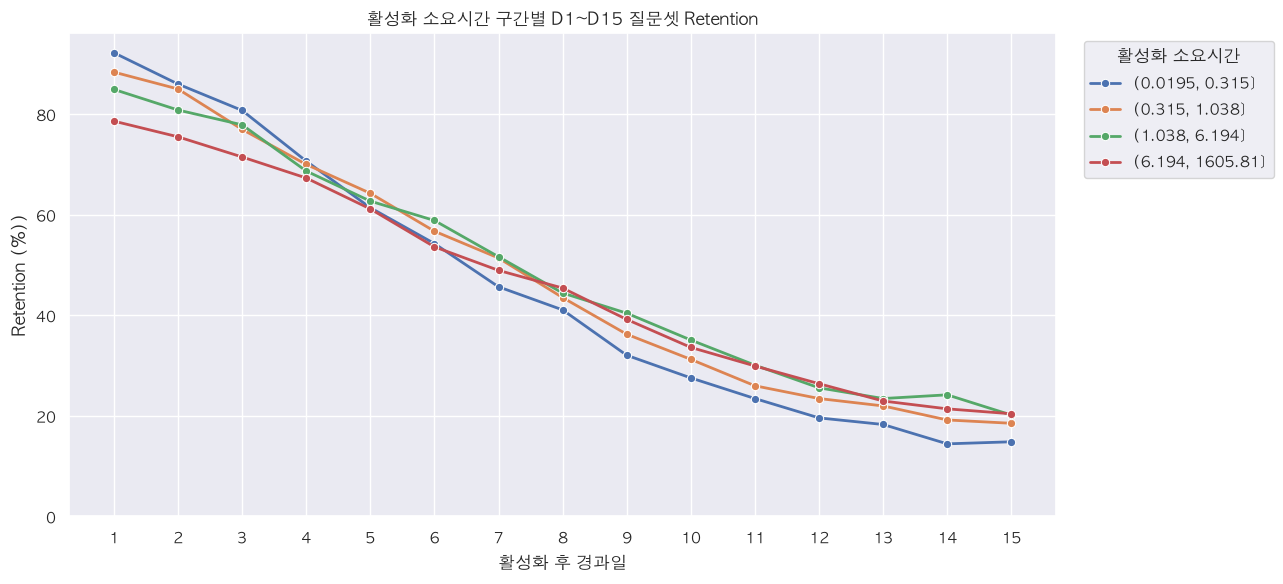

In [96]:
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=plot_data,
    x='retention_day',
    y='Retention(%)',
    hue='활성화 소요시간 구간',
    marker='o',
    linewidth=2,
)

plt.title(
    '활성화 소요시간 구간별 D1~D15 질문셋 Retention'
)
plt.xlabel('활성화 후 경과일')
plt.ylabel('Retention (%))')

plt.xticks(range(1, 16))
plt.ylim(bottom=0)

plt.legend(
    title='활성화 소요시간',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)

plt.tight_layout()
plt.show()

#### 1-1-1. 시간 의미를 구체화

In [97]:
activation_bins = [
    0,
    0.25,   # 15분
    0.5,    # 30분
    1,      # 1시간
    3,
    6,
    12,
    24,
    72,
    168,    # 7일
    float('inf'),
]

activation_labels = [
    '15분 이내',
    '15~30분',
    '30분~1시간',
    '1~3시간',
    '3~6시간',
    '6~12시간',
    '12~24시간',
    '1~3일',
    '3~7일',
    '7일 초과',
]

activation_timing['activation_time_group'] = pd.cut(
    activation_timing['hours_to_activation'],
    bins=activation_bins,
    labels=activation_labels,
    right=True,
    include_lowest=True,
)

In [98]:
activation_time_distribution = (
    activation_timing[
        'activation_time_group'
    ]
    .value_counts(sort=False)
    .rename_axis('활성화 소요시간')
    .reset_index(name='사용자 수')
)

activation_time_distribution['사용자 비율(%)'] = (
    activation_time_distribution['사용자 수']
    / activation_time_distribution['사용자 수'].sum()
    * 100
).round(2)

display(activation_time_distribution)

,활성화 소요시간,사용자 수,사용자 비율(%)
0,15분 이내,1020,20.90
1,15~30분,667,13.67
2,30분~1시간,713,14.61
3,1~3시간,873,17.89
4,3~6시간,368,7.54
5,6~12시간,369,7.56
6,12~24시간,343,7.03
7,1~3일,285,5.84
8,3~7일,155,3.18
9,7일 초과,87,1.78


In [99]:
retention_by_time_group = (
    retention_user_day
    .merge(
        activation_timing[
            [
                'user_id',
                'activation_time_group',
            ]
        ],
        on='user_id',
        how='left',
        validate='many_to_one',
    )
)

In [100]:
retention_by_time_summary = (
    retention_by_time_group
    .groupby(
        [
            'activation_time_group',
            'retention_day',
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        관찰가능사용자수=('user_id', 'nunique'),
        유지사용자수=('retained', 'sum'),
        retention_rate=('retained', 'mean'),
    )
)

retention_by_time_summary['Retention(%)'] = (
    retention_by_time_summary['retention_rate']
    * 100
).round(2)

In [101]:
retention_time_pivot = (
    retention_by_time_summary
    .pivot(
        index='activation_time_group',
        columns='retention_day',
        values='Retention(%)',
    )
    .rename(
        columns=lambda day: f'D{day}'
    )
)

display(retention_time_pivot)

retention_day,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
activation_time_group,,,,,,,,,,,,,,,
15분 이내,92.35,85.59,80.69,70.49,60.88,54.31,44.90,41.86,32.35,27.84,23.43,20.00,18.04,14.12,14.51
15~30분,89.51,86.06,77.06,68.97,64.02,54.27,48.73,41.83,34.03,28.19,24.89,19.34,20.09,16.34,16.04
30분~1시간,87.94,84.43,77.84,70.69,64.24,58.20,53.30,42.64,36.61,31.42,26.09,25.53,23.00,20.90,20.48
1~3시간,85.11,82.47,78.92,69.30,63.12,58.99,51.55,45.02,38.95,36.08,30.13,25.43,23.14,24.28,19.24
3~6시간,85.87,78.80,76.36,68.75,62.77,59.78,52.45,44.02,44.29,34.51,30.16,25.82,24.73,23.91,21.74
6~12시간,79.13,76.15,71.00,66.94,60.16,51.22,49.86,46.61,39.84,33.88,29.00,27.91,24.66,19.51,23.58
12~24시간,83.38,81.34,78.13,74.34,69.10,59.48,51.02,50.15,43.15,36.15,32.36,27.99,22.74,23.91,23.03
1~3일,77.19,74.74,70.88,63.16,58.95,51.58,44.56,41.05,34.04,32.28,31.23,25.96,20.35,21.05,16.49
3~7일,78.71,71.61,65.16,66.45,54.19,53.55,49.68,41.29,41.29,36.13,25.81,20.65,25.16,20.65,20.65


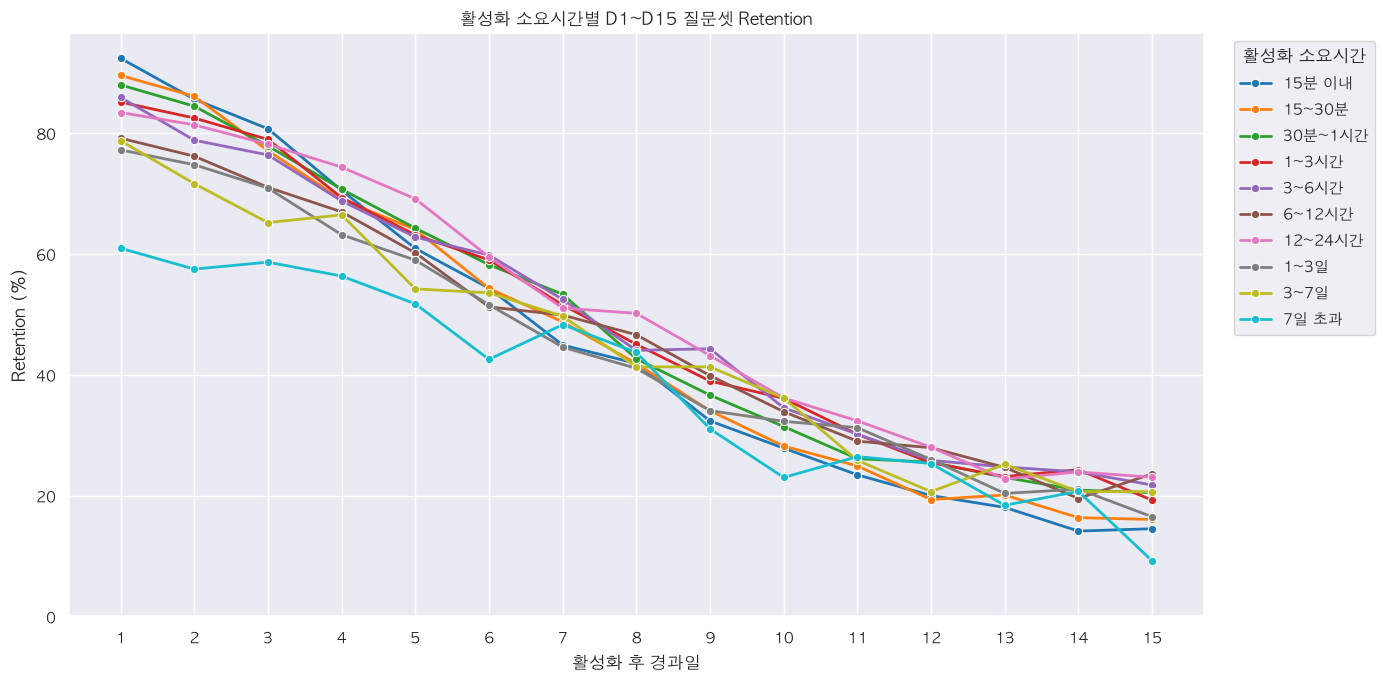

In [102]:
plot_data = retention_by_time_summary.copy()

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=plot_data,
    x='retention_day',
    y='Retention(%)',
    hue='activation_time_group',
    marker='o',
    linewidth=2,
    palette='tab10',
)

plt.title('활성화 소요시간별 D1~D15 질문셋 Retention')
plt.xlabel('활성화 후 경과일')
plt.ylabel('Retention (%)')
plt.xticks(range(1, 16))
plt.ylim(bottom=0)

plt.legend(
    title='활성화 소요시간',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)

plt.tight_layout()
plt.show()

#### 💡 1-1-정리. 
* 활성화 소요시간이 짧은 사용자는 특히 D1~D2의 초기 질문셋 Retention이 높은 경향을 보였다. 그러나 D3 이후에는 소요시간 구간별 순서가 일관되지 않아, 빠른 활성화가 중장기 Retention과 지속적으로 연결된다는 근거는 확인되지 않았다.

### 1-2. 친구 수에 따라 리텐션이 높을 것이다.

In [103]:
# KST 기준 경과일 시작 시각 준비
retention_friend_base = retention_user_day.copy()

retention_friend_base['friend_snapshot_at'] = (
    retention_friend_base['target_day']
)


In [104]:
# 친구 이력 정리
friend_history = (
    target_friend_history[
        [
            'user_id',
            'friendship_at',
            'friend_cnt_after',
        ]
    ]
    .dropna(
        subset=[
            'user_id',
            'friendship_at',
        ]
    )
    .copy()
)

In [105]:
retention_friend_base = (
    retention_friend_base
    .sort_values(
        [
            'friend_snapshot_at',
            'user_id',
        ]
    )
    .reset_index(drop=True)
)

friend_history = (
    friend_history
    .sort_values(
        [
            'friendship_at',
            'user_id',
        ]
    )
    .reset_index(drop=True)
)

In [106]:
# 각 날짜의 시작 시점의 마지막 친구 수 연결
retention_friend_day = pd.merge_asof(
    retention_friend_base,
    friend_history,
    left_on='friend_snapshot_at',
    right_on='friendship_at',
    by='user_id',
    direction='backward',
    allow_exact_matches=True,
)

In [107]:
retention_friend_day['friend_count_at_day_start'] = (
    retention_friend_day['friend_cnt_after']
    .fillna(0)
    .astype(int)
)

In [108]:
display(
    retention_friend_day[
        [
            'user_id',
            'retention_day',
            'target_day',
            'friend_snapshot_at',
            'friendship_at',
            'friend_count_at_day_start',
            'retained',
        ]
    ]
    .sort_values(
        [
            'user_id',
            'retention_day',
        ]
    )
    .head(30)
)

,user_id,retention_day,target_day,friend_snapshot_at,friendship_at,friend_count_at_day_start,retained
1355,838466,1,2023-05-04 00:00:00+09:00,2023-05-04 00:00:00+09:00,2023-05-03 23:34:46+09:00,38,True
2123,838466,2,2023-05-05 00:00:00+09:00,2023-05-05 00:00:00+09:00,2023-05-04 22:37:28+09:00,55,True
3095,838466,3,2023-05-06 00:00:00+09:00,2023-05-06 00:00:00+09:00,2023-05-05 23:44:12+09:00,59,True
4458,838466,4,2023-05-07 00:00:00+09:00,2023-05-07 00:00:00+09:00,2023-05-06 17:17:21+09:00,61,True
6080,838466,5,2023-05-08 00:00:00+09:00,2023-05-08 00:00:00+09:00,2023-05-06 17:17:21+09:00,61,False
7860,838466,6,2023-05-09 00:00:00+09:00,2023-05-09 00:00:00+09:00,2023-05-06 17:17:21+09:00,61,False
9770,838466,7,2023-05-10 00:00:00+09:00,2023-05-10 00:00:00+09:00,2023-05-06 17:17:21+09:00,61,False
11831,838466,8,2023-05-11 00:00:00+09:00,2023-05-11 00:00:00+09:00,2023-05-06 17:17:21+09:00,61,False
14060,838466,9,2023-05-12 00:00:00+09:00,2023-05-12 00:00:00+09:00,2023-05-06 17:17:21+09:00,61,False
16562,838466,10,2023-05-13 00:00:00+09:00,2023-05-13 00:00:00+09:00,2023-05-06 17:17:21+09:00,61,False


In [109]:
friend_count_decrease = (
    retention_friend_day
    .sort_values(
        [
            'user_id',
            'retention_day',
        ]
    )
    .groupby('user_id')[
        'friend_count_at_day_start'
    ]
    .diff()
    .lt(0)
    .sum()
)

print(
    '경과일이 증가하면서 친구 수가 감소한 기록:',
    friend_count_decrease,
)

경과일이 증가하면서 친구 수가 감소한 기록: 0


In [110]:
# 전체 사용자 x 경과일 기준 분포
display(
    retention_friend_day[
        'friend_count_at_day_start'
    ]
    .describe(
        percentiles=[
            0.25,
            0.5,
            0.75,
            0.9,
            0.95,
            0.99,
        ]
    )
)

count    73200.000000
mean        38.538429
std         26.748576
min          4.000000
25%         18.000000
50%         33.000000
75%         53.000000
90%         75.000000
95%         89.000000
99%        124.000000
max        243.000000
Name: friend_count_at_day_start, dtype: float64

In [111]:
friend_count_by_day = (
    retention_friend_day[
        retention_friend_day[
            'retention_day'
        ].isin([1, 7, 15])
    ]
    .groupby('retention_day')
    ['friend_count_at_day_start']
    .agg(
        사용자수='count',
        평균='mean',
        중앙값='median',
        최소값='min',
        최대값='max',
        P25=lambda x: x.quantile(0.25),
        P75=lambda x: x.quantile(0.75),
        P90=lambda x: x.quantile(0.90),
        P95=lambda x: x.quantile(0.95),
    )
    .round(2)
    .reset_index()
)

friend_count_by_day['경과일'] = (
    'D'
    + friend_count_by_day[
        'retention_day'
    ].astype(str)
)

display(
    friend_count_by_day[
        [
            '경과일',
            '사용자수',
            '평균',
            '중앙값',
            'P25',
            'P75',
            'P90',
            'P95',
            '최소값',
            '최대값',
        ]
    ]
)

,경과일,사용자수,평균,중앙값,P25,P75,P90,P95,최소값,최대값
0,D1,4880,17.42,13.0,7.0,23.0,35.0,45.0,4,129
1,D7,4880,41.12,36.0,21.0,56.0,77.0,91.0,4,222
2,D15,4880,43.93,38.0,22.0,60.0,82.0,96.0,4,243


In [112]:
friend_count_bins = [
    -float('inf'),
    3,
    9,
    19,
    39,
    79,
    float('inf'),
]

friend_count_labels = [
    '4명 미만',
    '4~9명',
    '10~19명',
    '20~39명',
    '40~79명',
    '80명 이상',
]

retention_friend_day['friend_count_group'] = pd.cut(
    retention_friend_day[
        'friend_count_at_day_start'
    ],
    bins=friend_count_bins,
    labels=friend_count_labels,
    right=True,
)

In [113]:
friend_group_distribution = (
    retention_friend_day
    .groupby(
        [
            'retention_day',
            'friend_count_group',
        ],
        observed=False,
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
    )
)

display(
    friend_group_distribution[
        friend_group_distribution[
            'retention_day'
        ].isin([1, 7, 15])
    ]
    .pivot(
        index='friend_count_group',
        columns='retention_day',
        values='사용자수',
    )
    .rename(
        columns={
            1: 'D1',
            7: 'D7',
            15: 'D15',
        }
    )
)

retention_day,D1,D7,D15
friend_count_group,,,
4명 미만,0,0,0
4~9명,1689,356,291
10~19명,1629,757,702
20~39명,1191,1569,1527
40~79명,347,1764,1807
80명 이상,24,434,553


In [114]:
friend_retention_summary = (
    retention_friend_day
    .groupby(
        [
            'friend_count_group',
            'retention_day',
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        관찰가능사용자수=('user_id', 'nunique'),
        유지사용자수=('retained', 'sum'),
        retention_rate=('retained', 'mean'),
    )
)

friend_retention_summary['Retention(%)'] = (
    friend_retention_summary[
        'retention_rate'
    ]
    * 100
).round(2)

In [115]:
# 리텐션
friend_retention_pivot = (
    friend_retention_summary
    .pivot(
        index='friend_count_group',
        columns='retention_day',
        values='Retention(%)',
    )
    .rename(
        columns=lambda day: f'D{day}'
    )
)

display(friend_retention_pivot)

retention_day,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
friend_count_group,,,,,,,,,,,,,,,
4~9명,73.77,52.80,45.49,36.97,29.95,28.88,23.31,20.00,18.13,16.46,11.54,11.29,7.92,9.76,7.22
10~19명,89.38,77.93,65.29,55.85,46.87,37.52,32.89,27.99,26.00,20.67,16.99,13.76,15.10,12.96,13.25
20~39명,95.63,90.08,82.80,73.15,65.88,57.98,50.22,44.93,36.65,31.79,28.08,24.79,20.22,19.10,17.62
40~79명,96.25,92.40,88.56,79.56,72.26,66.19,58.90,51.65,44.29,38.39,32.56,27.55,26.12,24.43,21.86
80명 이상,95.83,91.09,85.79,82.03,72.64,63.75,58.06,50.32,39.92,34.41,30.84,28.36,27.04,20.63,22.42


In [116]:
# 사용자 수
friend_retention_count_pivot = (
    friend_retention_summary
    .pivot(
        index='friend_count_group',
        columns='retention_day',
        values='관찰가능사용자수',
    )
    .rename(
        columns=lambda day: f'D{day}'
    )
)

display(friend_retention_count_pivot)

retention_day,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
friend_count_group,,,,,,,,,,,,,,,
4~9명,1689,714,521,449,404,374,356,340,331,322,312,310,303,297,291
10~19명,1629,1314,1043,897,815,781,757,736,723,716,712,705,702,702,702
20~39명,1191,1804,1796,1717,1656,1597,1569,1558,1536,1532,1528,1525,1528,1529,1527
40~79명,347,947,1337,1561,1676,1739,1764,1783,1804,1813,1806,1811,1807,1809,1807
80명 이상,24,101,183,256,329,389,434,463,486,497,522,529,540,543,553


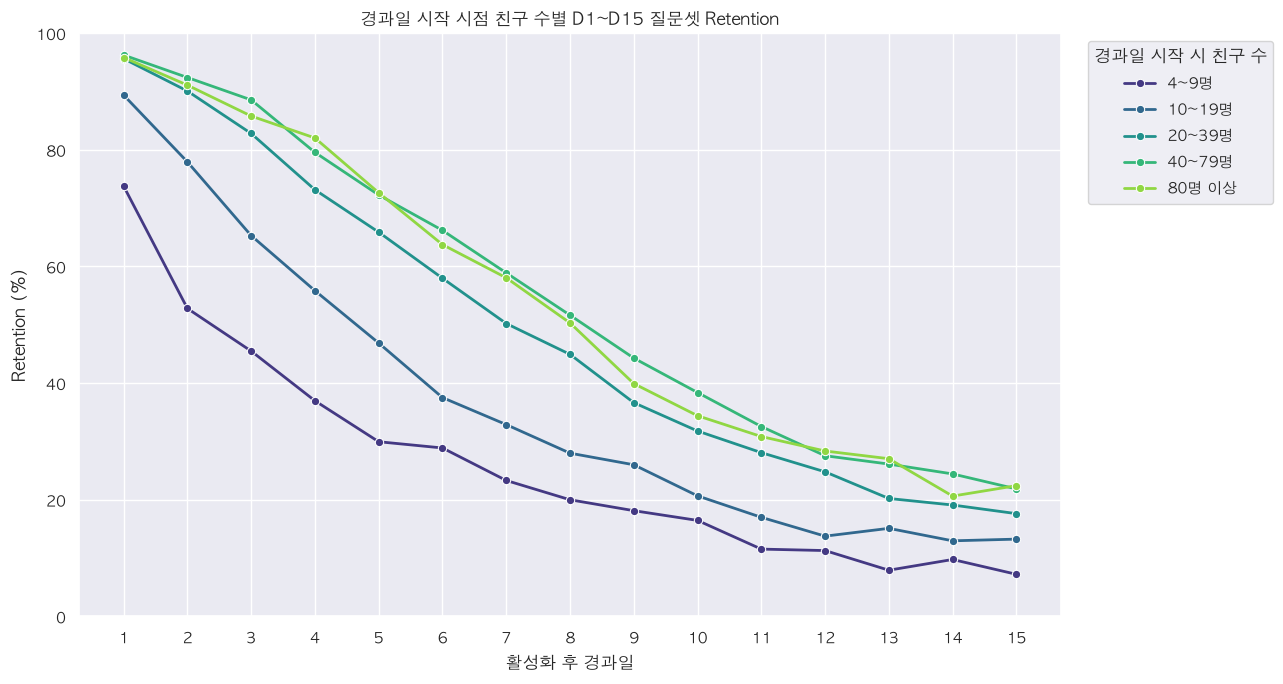

In [117]:
friend_group_order = [
    '4~9명',
    '10~19명',
    '20~39명',
    '40~79명',
    '80명 이상',
]

plt.figure(figsize=(13, 7))

sns.lineplot(
    data=friend_retention_summary,
    x='retention_day',
    y='Retention(%)',
    hue='friend_count_group',
    hue_order=friend_group_order,
    marker='o',
    linewidth=2,
    palette='viridis',
)

plt.title('경과일 시작 시점 친구 수별 D1~D15 질문셋 Retention')
plt.xlabel('활성화 후 경과일')
plt.ylabel('Retention (%)')
plt.xticks(range(1, 16))
plt.ylim(0, 100)

plt.legend(
    title='경과일 시작 시 친구 수',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)

plt.tight_layout()
plt.show()

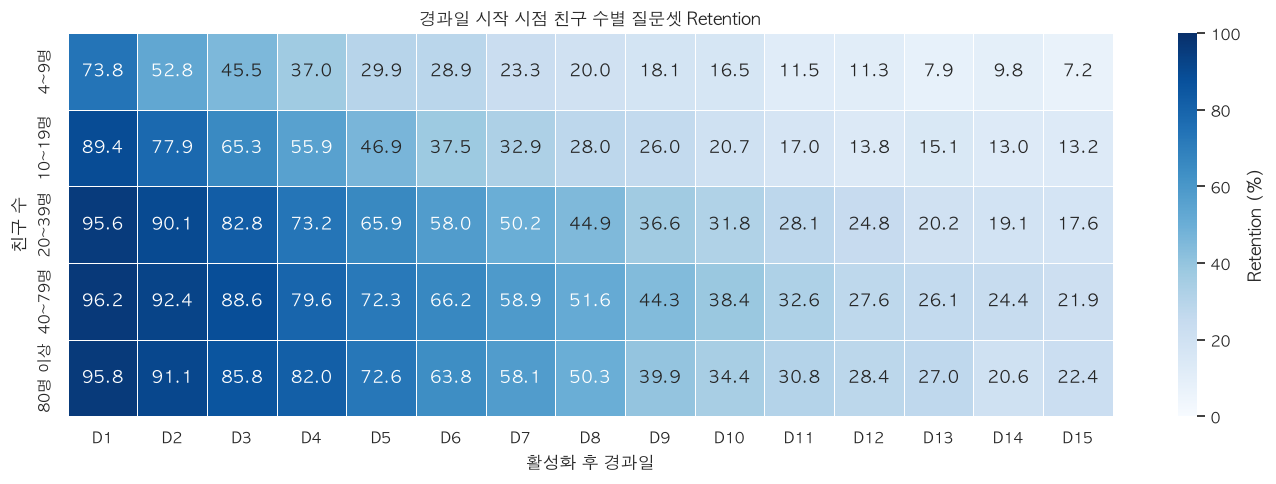

In [118]:
plt.figure(figsize=(14, 5))

sns.heatmap(
    friend_retention_pivot,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={
        'label': 'Retention (%)',
    },
)

plt.title('경과일 시작 시점 친구 수별 질문셋 Retention')
plt.xlabel('활성화 후 경과일')
plt.ylabel('친구 수')
plt.tight_layout()
plt.show()

#### 💡 1-2-정리. 
* 친구 수가 많은 상태의 사용자는 친구 수가 적은 상태의 사용자보다 당일 질문셋을 완료할 가능성이 높았으며, 이러한 차이는 D1부터 D15까지 일관되게 관찰되었다. 특히 친구 수 4~9명과 20명 이상 집단의 차이가 크게 나타났고, 약 40명 이상에서는 Retention 증가 폭이 둔화되는 경향을 보였다.

### 1-3. 질문 완료 경험이 많을수록 리텐션이 높을 것이다.

In [119]:
# 사용자별 질문셋 완료 순서 생성
questionset_experience_history = (
    questionset_completion[
        [
            'questionset_id',
            'user_id',
            'estimated_completed_at',
        ]
    ]
    .dropna(
        subset=[
            'user_id',
            'estimated_completed_at',
        ]
    )
    .sort_values(
        [
            'user_id',
            'estimated_completed_at',
            'questionset_id',
        ]
    )
    .reset_index(drop=True)
)

In [120]:
questionset_experience_history[
    'cumulative_questionset_count'
] = (
    questionset_experience_history
    .groupby('user_id')
    .cumcount()
    + 1
)

In [121]:
display(
    questionset_experience_history[
        [
            'user_id',
            'questionset_id',
            'estimated_completed_at',
            'cumulative_questionset_count',
        ]
    ].head(30)
)

,user_id,questionset_id,estimated_completed_at,cumulative_questionset_count
0,838023,116704,2023-04-30 01:22:56+09:00,1
1,838023,132741,2023-04-30 13:18:56+09:00,2
2,838023,145316,2023-05-02 14:49:35+09:00,3
3,838023,257385,2023-05-03 17:36:09+09:00,4
4,838023,333471,2023-05-03 21:23:17+09:00,5
5,838023,347685,2023-05-04 16:26:25+09:00,6
6,838466,305901,2023-05-03 07:43:29+09:00,1
7,838466,305990,2023-05-03 09:45:06+09:00,2
8,838466,311952,2023-05-03 10:43:01+09:00,3
9,838466,326249,2023-05-03 22:22:11+09:00,4


In [122]:
questionset_count_check = (
    questionset_experience_history
    .groupby('user_id')
    .agg(
        질문셋행수=('questionset_id', 'size'),
        최종누적완료수=(
            'cumulative_questionset_count',
            'max',
        ),
    )
)

print(
    '누적 수 불일치 사용자:',
    (
        questionset_count_check['질문셋행수']
        != questionset_count_check['최종누적완료수']
    ).sum(),
)

누적 수 불일치 사용자: 0


In [123]:
# KST 기준 경과일 시작 시각 준비
retention_experience_base = (
    retention_user_day
    .copy()
)

retention_experience_base[
    'experience_snapshot_at'
] = retention_experience_base['target_day']


In [124]:
# 정렬
retention_experience_base = (
    retention_experience_base
    .sort_values(
        [
            'experience_snapshot_at',
            'user_id',
        ]
    )
    .reset_index(drop=True)
)

questionset_experience_history = (
    questionset_experience_history
    .sort_values(
        [
            'estimated_completed_at',
            'user_id',
            'questionset_id',
        ]
    )
    .reset_index(drop=True)
)

In [125]:
# 경과일 시작 직전의 누적 완료 수 연결
retention_experience_day = pd.merge_asof(
    retention_experience_base,
    questionset_experience_history[
        [
            'user_id',
            'estimated_completed_at',
            'cumulative_questionset_count',
        ]
    ],
    left_on='experience_snapshot_at',
    right_on='estimated_completed_at',
    by='user_id',
    direction='backward',
    allow_exact_matches=False,
)

In [126]:
# 이전 완료 기록이 없는 사용자는 0회로 처리
retention_experience_day[
    'prior_questionset_count'
] = (
    retention_experience_day[
        'cumulative_questionset_count'
    ]
    .fillna(0)
    .astype(int)
)

In [127]:
# 결과
display(
    retention_experience_day[
        [
            'user_id',
            'retention_day',
            'target_day',
            'experience_snapshot_at',
            'estimated_completed_at',
            'prior_questionset_count',
            'retained',
        ]
    ]
    .sort_values(
        [
            'user_id',
            'retention_day',
        ]
    )
    .head(30)
)

,user_id,retention_day,target_day,experience_snapshot_at,estimated_completed_at,prior_questionset_count,retained
1355,838466,1,2023-05-04 00:00:00+09:00,2023-05-04 00:00:00+09:00,2023-05-03 23:30:11+09:00,5,True
2123,838466,2,2023-05-05 00:00:00+09:00,2023-05-05 00:00:00+09:00,2023-05-04 21:52:13+09:00,11,True
3095,838466,3,2023-05-06 00:00:00+09:00,2023-05-06 00:00:00+09:00,2023-05-05 23:06:14+09:00,16,True
4458,838466,4,2023-05-07 00:00:00+09:00,2023-05-07 00:00:00+09:00,2023-05-06 12:06:29+09:00,17,True
6080,838466,5,2023-05-08 00:00:00+09:00,2023-05-08 00:00:00+09:00,2023-05-07 22:39:45+09:00,19,False
7860,838466,6,2023-05-09 00:00:00+09:00,2023-05-09 00:00:00+09:00,2023-05-07 22:39:45+09:00,19,False
9770,838466,7,2023-05-10 00:00:00+09:00,2023-05-10 00:00:00+09:00,2023-05-07 22:39:45+09:00,19,False
11831,838466,8,2023-05-11 00:00:00+09:00,2023-05-11 00:00:00+09:00,2023-05-07 22:39:45+09:00,19,False
14060,838466,9,2023-05-12 00:00:00+09:00,2023-05-12 00:00:00+09:00,2023-05-07 22:39:45+09:00,19,False
16562,838466,10,2023-05-13 00:00:00+09:00,2023-05-13 00:00:00+09:00,2023-05-07 22:39:45+09:00,19,False


In [128]:
experience_count_decrease = (
    retention_experience_day
    .sort_values(
        [
            'user_id',
            'retention_day',
        ]
    )
    .groupby('user_id')[
        'prior_questionset_count'
    ]
    .diff()
    .lt(0)
    .sum()
)

print(
    '경과일 증가 중 누적 완료 수 감소 기록:',
    experience_count_decrease,
)

경과일 증가 중 누적 완료 수 감소 기록: 0


In [129]:
questionset_experience_distribution = (
    retention_experience_day[
        retention_experience_day[
            'retention_day'
        ].isin([1, 7, 15])
    ]
    .groupby('retention_day')
    ['prior_questionset_count']
    .agg(
        사용자수='count',
        평균='mean',
        중앙값='median',
        최소값='min',
        최대값='max',
        P25=lambda x: x.quantile(0.25),
        P75=lambda x: x.quantile(0.75),
        P90=lambda x: x.quantile(0.90),
        P95=lambda x: x.quantile(0.95),
        P99=lambda x: x.quantile(0.99),
    )
    .round(2)
    .reset_index()
)

questionset_experience_distribution['경과일'] = (
    'D'
    + questionset_experience_distribution[
        'retention_day'
    ].astype(str)
)

display(
    questionset_experience_distribution[
        [
            '경과일',
            '사용자수',
            '평균',
            '중앙값',
            'P25',
            'P75',
            'P90',
            'P95',
            'P99',
            '최소값',
            '최대값',
        ]
    ]
)

,경과일,사용자수,평균,중앙값,P25,P75,P90,P95,P99,최소값,최대값
0,D1,4880,3.35,2.0,1.0,5.0,8.0,10.0,15.00,0,51
1,D7,4880,21.87,19.0,10.0,31.0,44.0,52.0,73.00,0,114
2,D15,4880,27.55,22.0,12.0,38.0,57.0,72.0,103.21,0,182


In [130]:
display(
    retention_experience_day[
        retention_experience_day[
            'retention_day'
        ].isin([1, 7, 15])
    ]
    .groupby(
        [
            'retention_day',
            'prior_questionset_count',
        ]
    )
    .size()
    .reset_index(name='사용자수')
    .sort_values(
        [
            'retention_day',
            'prior_questionset_count',
        ]
    )
    .head(50)
)

,retention_day,prior_questionset_count,사용자수
0,1,0,773
1,1,1,944
2,1,2,773
3,1,3,600
4,1,4,470
5,1,5,326
6,1,6,291
7,1,7,180
8,1,8,142
9,1,9,110


In [131]:
questionset_count_bins = [
    -1,
    0,
    2,
    5,
    10,
    20,
    40,
    float('inf'),
]

questionset_count_labels = [
    '0회',
    '1~2회',
    '3~5회',
    '6~10회',
    '11~20회',
    '21~40회',
    '41회 이상',
]

In [132]:
retention_experience_day[
    'prior_questionset_group'
] = pd.cut(
    retention_experience_day[
        'prior_questionset_count'
    ],
    bins=questionset_count_bins,
    labels=questionset_count_labels,
    right=True,
)

In [133]:
experience_group_distribution = (
    retention_experience_day
    .groupby(
        [
            'retention_day',
            'prior_questionset_group',
        ],
        observed=False,
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
    )
)

display(
    experience_group_distribution[
        experience_group_distribution[
            'retention_day'
        ].isin([1, 7, 15])
    ]
    .pivot(
        index='prior_questionset_group',
        columns='retention_day',
        values='사용자수',
    )
    .rename(
        columns={
            1: 'D1',
            7: 'D7',
            15: 'D15',
        }
    )
)

retention_day,D1,D7,D15
prior_questionset_group,,,
0회,773,157,143
1~2회,1717,225,185
3~5회,1396,311,252
6~10회,785,656,505
11~20회,200,1308,1158
21~40회,8,1590,1556
41회 이상,1,633,1081


In [134]:
experience_group_ratio = (
    experience_group_distribution
    .copy()
)

experience_group_ratio['사용자 비율(%)'] = (
    experience_group_ratio['사용자수']
    / experience_group_ratio
        .groupby('retention_day')['사용자수']
        .transform('sum')
    * 100
).round(2)

display(
    experience_group_ratio[
        experience_group_ratio[
            'retention_day'
        ].isin([1, 7, 15])
    ]
    .pivot(
        index='prior_questionset_group',
        columns='retention_day',
        values='사용자 비율(%)',
    )
    .rename(
        columns={
            1: 'D1',
            7: 'D7',
            15: 'D15',
        }
    )
)

retention_day,D1,D7,D15
prior_questionset_group,,,
0회,15.84,3.22,2.93
1~2회,35.18,4.61,3.79
3~5회,28.61,6.37,5.16
6~10회,16.09,13.44,10.35
11~20회,4.10,26.80,23.73
21~40회,0.16,32.58,31.89
41회 이상,0.02,12.97,22.15


In [135]:
experience_retention_summary = (
    retention_experience_day
    .groupby(
        [
            'prior_questionset_group',
            'retention_day',
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        관찰가능사용자수=('user_id', 'nunique'),
        유지사용자수=('retained', 'sum'),
        retention_rate=('retained', 'mean'),
    )
)

experience_retention_summary['Retention(%)'] = (
    experience_retention_summary[
        'retention_rate'
    ]
    * 100
).round(2)

In [136]:
experience_retention_pivot = (
    experience_retention_summary
    .pivot(
        index='prior_questionset_group',
        columns='retention_day',
        values='Retention(%)',
    )
    .rename(
        columns=lambda day: f'D{day}'
    )
)

display(experience_retention_pivot)

retention_day,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
prior_questionset_group,,,,,,,,,,,,,,,
0회,56.92,28.23,17.15,12.12,6.32,3.68,1.27,3.87,0.67,2.03,0.00,0.00,0.00,1.38,0.00
1~2회,84.74,54.15,33.52,18.88,15.62,7.79,5.33,5.94,8.96,3.47,2.00,3.52,5.64,1.62,3.78
3~5회,95.13,79.33,56.93,42.42,30.61,23.48,18.97,13.03,10.43,10.70,6.23,3.92,4.76,2.37,3.57
6~10회,98.22,89.69,78.02,60.55,47.20,37.74,30.34,23.78,19.42,14.61,11.99,10.97,6.96,8.45,7.72
11~20회,98.00,97.19,90.10,76.39,64.61,54.31,42.66,35.12,25.24,22.26,19.20,15.87,12.21,11.92,10.02
21~40회,87.50,99.07,98.08,92.65,83.61,73.99,65.35,55.18,46.35,37.68,31.70,26.08,24.10,20.54,19.41
41회 이상,100.00,100.00,100.00,98.61,98.69,92.06,85.62,80.37,70.84,62.95,54.35,48.52,46.15,42.47,39.69


In [137]:
experience_retention_count_pivot = (
    experience_retention_summary
    .pivot(
        index='prior_questionset_group',
        columns='retention_day',
        values='관찰가능사용자수',
    )
    .rename(
        columns=lambda day: f'D{day}'
    )
)

display(experience_retention_count_pivot)

retention_day,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
prior_questionset_group,,,,,,,,,,,,,,,
0회,773,333,239,198,174,163,157,155,149,148,145,145,145,145,143
1~2회,1717,554,361,286,256,231,225,219,212,202,200,199,195,185,185
3~5회,1396,982,599,462,392,345,311,284,278,271,257,255,252,253,252
6~10회,785,1475,1183,910,786,718,656,614,587,568,559,538,517,509,505
11~20회,200,1318,1637,1601,1472,1379,1308,1270,1232,1213,1198,1178,1179,1166,1158
21~40회,8,216,834,1279,1495,1553,1590,1584,1575,1571,1555,1553,1552,1553,1556
41회 이상,1,2,27,144,305,491,633,754,847,907,966,1012,1040,1069,1081


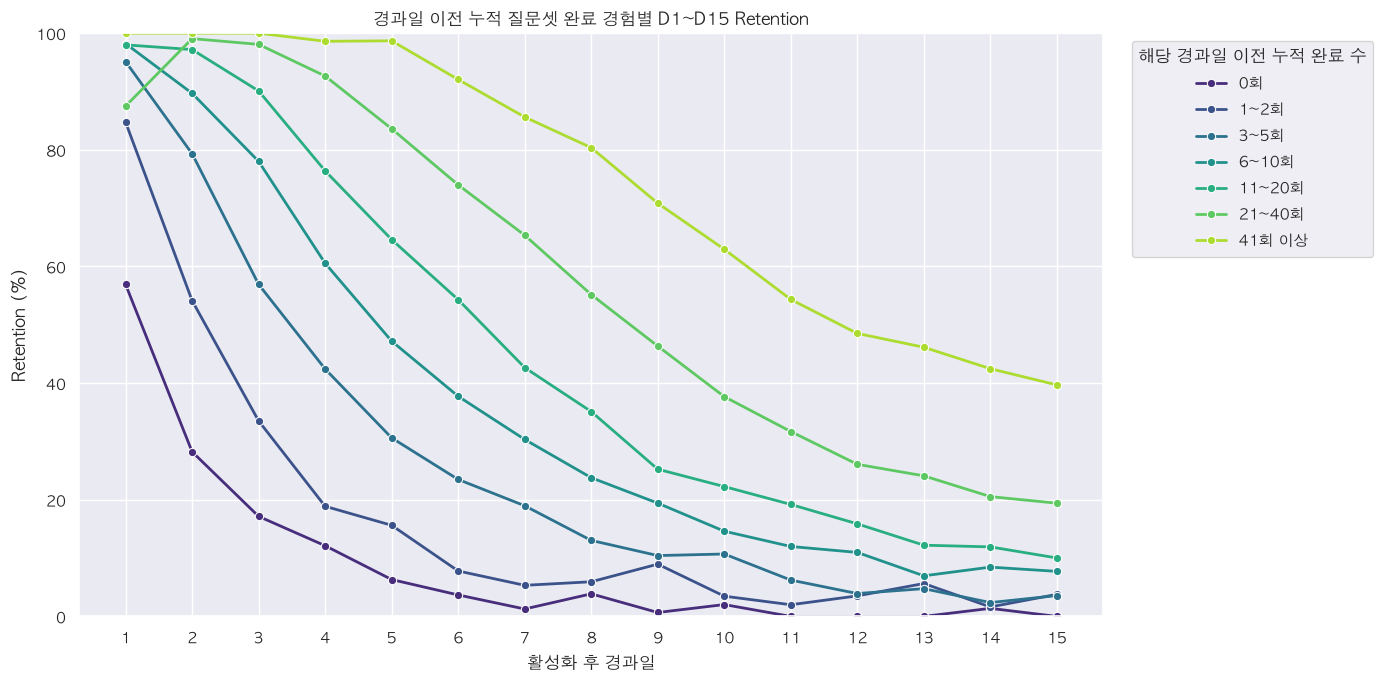

In [138]:
questionset_group_order = [
    '0회',
    '1~2회',
    '3~5회',
    '6~10회',
    '11~20회',
    '21~40회',
    '41회 이상',
]

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=experience_retention_summary,
    x='retention_day',
    y='Retention(%)',
    hue='prior_questionset_group',
    hue_order=questionset_group_order,
    marker='o',
    linewidth=2,
    palette='viridis',
)

plt.title(
    '경과일 이전 누적 질문셋 완료 경험별 D1~D15 Retention'
)
plt.xlabel('활성화 후 경과일')
plt.ylabel('Retention (%)')
plt.xticks(range(1, 16))
plt.ylim(0, 100)

plt.legend(
    title='해당 경과일 이전 누적 완료 수',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)

plt.tight_layout()
plt.show()

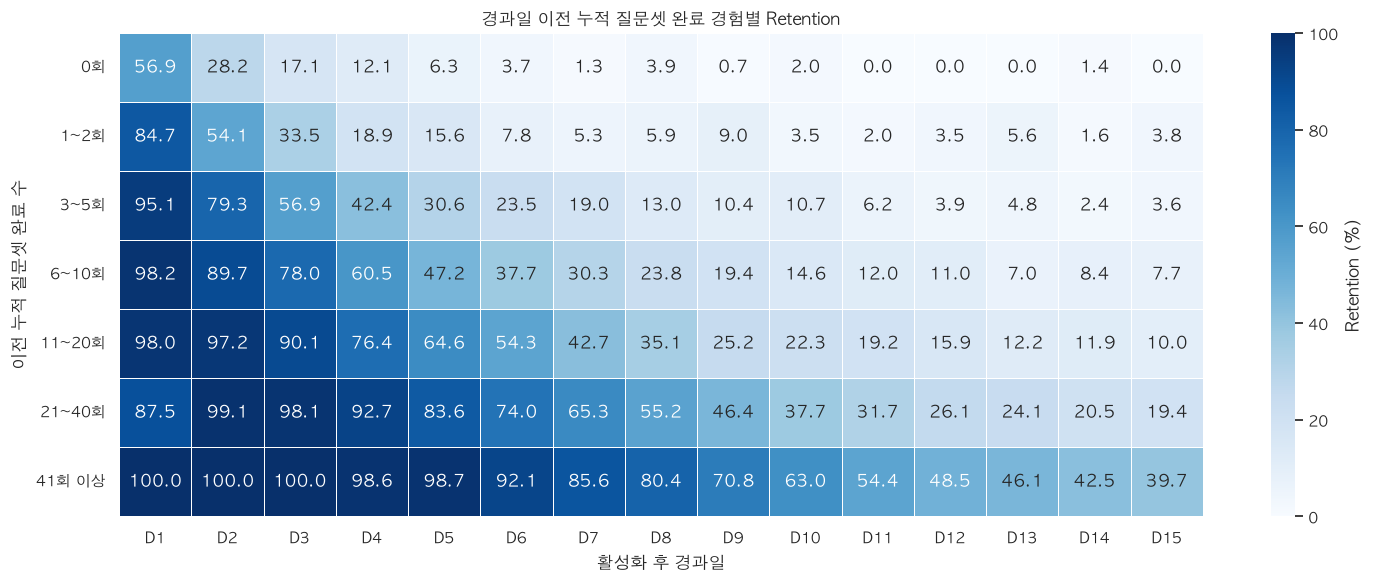

In [139]:
plt.figure(figsize=(15, 6))

sns.heatmap(
    experience_retention_pivot,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={
        'label': 'Retention (%)',
    },
)

plt.title(
    '경과일 이전 누적 질문셋 완료 경험별 Retention'
)
plt.xlabel('활성화 후 경과일')
plt.ylabel('이전 누적 질문셋 완료 수')

plt.tight_layout()
plt.show()

#### 💡 1-3-정리.
* 활성화 이후 질문셋 완료 경험을 많이 축적한 사용자는 이후에도 질문 기능을 지속적으로 이용하는 경향이 있다.

### 1-4. 24시간 내 질문 완료 수가 많을수록 리텐션이 높을 것이다.

In [140]:
# 활성화 후 초기 24시간 질문셋 완료 수 계산

# 활성화된 사용자
early_activity_users = (
    user_activation[
        user_activation['activation_at'].notna()
    ][
        ['user_id', 'activation_at']
    ]
    .drop_duplicates('user_id')
    .copy()
)

# 질문셋 완료 기록 연결
early_activity_records = (
    early_activity_users
    .merge(
        questionset_completion[
            ['user_id', 'questionset_id', 'estimated_completed_at']
        ],
        on='user_id',
        how='left',
        validate='one_to_many',
    )
)

# 활성화 후 24시간 이내 완료 여부
early_activity_records['completed_within_24h'] = (
    early_activity_records['estimated_completed_at'].ge(
        early_activity_records['activation_at']
    )
    & early_activity_records['estimated_completed_at'].lt(
        early_activity_records['activation_at']
        + pd.Timedelta(hours=24)
    )
)

# 사용자별 초기 24시간 질문셋 완료 수
early_24h_activity = (
    early_activity_records
    .groupby(
        ['user_id', 'activation_at'],
        as_index=False,
    )
    .agg(
        completed_questionsets_24h=(
            'completed_within_24h',
            'sum',
        )
    )
)

early_24h_activity['completed_questionsets_24h'] = (
    early_24h_activity['completed_questionsets_24h'].astype(int)
)

display(early_24h_activity.head())
display(
    early_24h_activity['completed_questionsets_24h']
    .describe(percentiles=[.25, .5, .75, .9, .95, .99])
)

,user_id,activation_at,completed_questionsets_24h
0,838466,2023-05-03 07:44:27.267798+09:00,5
1,838642,2023-05-05 16:21:24+09:00,0
2,839357,2023-04-30 01:55:27+09:00,6
3,840293,2023-05-04 20:29:51+09:00,3
4,840473,2023-05-04 22:50:41+09:00,1


count    4880.000000
mean        5.417623
std         4.312094
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
90%        11.000000
95%        14.000000
99%        17.000000
max        25.000000
Name: completed_questionsets_24h, dtype: float64

In [141]:
early_24h_distribution = (
    early_24h_activity
    .groupby(
        'completed_questionsets_24h',
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique')
    )
    .sort_values('completed_questionsets_24h')
)

early_24h_distribution['사용자비율(%)'] = (
    early_24h_distribution['사용자수']
    / early_24h_distribution['사용자수'].sum()
    * 100
).round(2)

display(early_24h_distribution)

,completed_questionsets_24h,사용자수,사용자비율(%)
0,0,627,12.85
1,1,390,7.99
2,2,448,9.18
3,3,454,9.30
4,4,428,8.77
5,5,432,8.85
6,6,402,8.24
7,7,299,6.13
8,8,278,5.70
9,9,252,5.16


In [142]:
early_24h_distribution['누적사용자비율(%)'] = (
    early_24h_distribution['사용자비율(%)']
    .cumsum()
    .round(2)
)

display(early_24h_distribution)

,completed_questionsets_24h,사용자수,사용자비율(%),누적사용자비율(%)
0,0,627,12.85,12.85
1,1,390,7.99,20.84
2,2,448,9.18,30.02
3,3,454,9.30,39.32
4,4,428,8.77,48.09
5,5,432,8.85,56.94
6,6,402,8.24,65.18
7,7,299,6.13,71.31
8,8,278,5.70,77.01
9,9,252,5.16,82.17


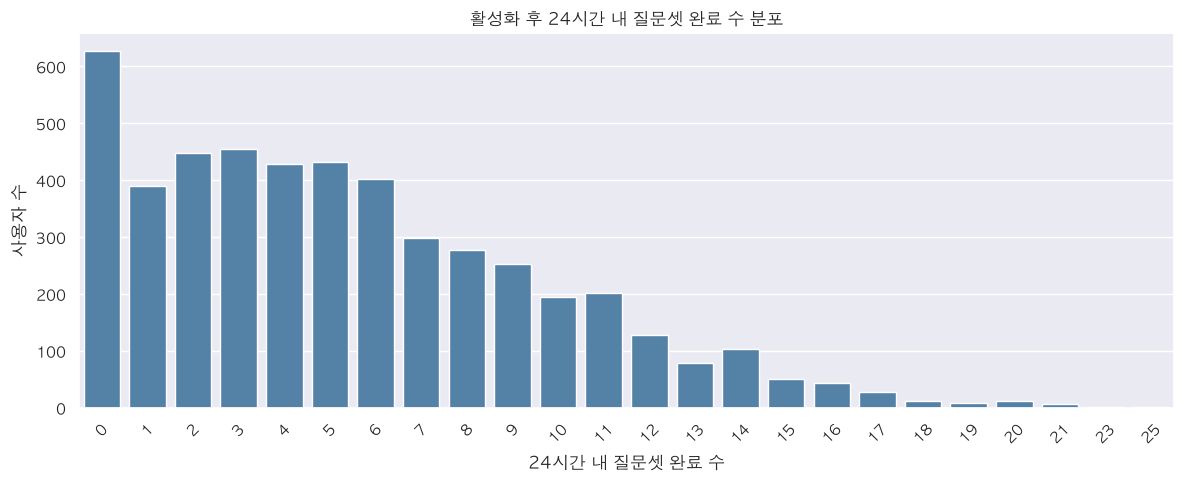

In [143]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=early_24h_distribution,
    x='completed_questionsets_24h',
    y='사용자수',
    color='steelblue',
)

plt.title('활성화 후 24시간 내 질문셋 완료 수 분포')
plt.xlabel('24시간 내 질문셋 완료 수')
plt.ylabel('사용자 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [144]:
early_24h_activity['early_activity_group'] = pd.cut(
    early_24h_activity['completed_questionsets_24h'],
    bins=[-1, 0, 1, 2, 3, 5, 10, float('inf')],
    labels=[
        '0회',
        '1회',
        '2회',
        '3회',
        '4~5회',
        '6~10회',
        '11회 이상',
    ],
)

early_activity_group_summary = (
    early_24h_activity
    .groupby(
        'early_activity_group',
        observed=False,
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
        평균완료수=('completed_questionsets_24h', 'mean'),
    )
)

early_activity_group_summary['사용자비율(%)'] = (
    early_activity_group_summary['사용자수']
    / early_activity_group_summary['사용자수'].sum()
    * 100
).round(2)

early_activity_group_summary['평균완료수'] = (
    early_activity_group_summary['평균완료수'].round(2)
)

display(early_activity_group_summary)

,early_activity_group,사용자수,평균완료수,사용자비율(%)
0,0회,627,0.00,12.85
1,1회,390,1.00,7.99
2,2회,448,2.00,9.18
3,3회,454,3.00,9.30
4,4~5회,860,4.50,17.62
5,6~10회,1425,7.68,29.20
6,11회 이상,676,13.29,13.85


In [145]:
retention_days = pd.DataFrame({
    'retention_day': range(1, 16)
})

early_retention_base = (
    early_24h_activity
    .merge(
        retention_days,
        how='cross',
    )
)

# 각 리텐션 일자의 관찰 시작·종료 시각
early_retention_base['window_start_at'] = (
    early_retention_base['activation_at']
    + pd.to_timedelta(
        early_retention_base['retention_day'],
        unit='D',
    )
)

early_retention_base['window_end_at'] = (
    early_retention_base['window_start_at']
    + pd.Timedelta(days=1)
)

display(
    early_retention_base[
        [
            'user_id',
            'activation_at',
            'completed_questionsets_24h',
            'early_activity_group',
            'retention_day',
            'window_start_at',
            'window_end_at',
        ]
    ].head(20)
)

,user_id,activation_at,completed_questionsets_24h,early_activity_group,retention_day,window_start_at,window_end_at
0,838466,2023-05-03 07:44:27.267798+09:00,5,4~5회,1,2023-05-04 07:44:27.267798+09:00,2023-05-05 07:44:27.267798+09:00
1,838466,2023-05-03 07:44:27.267798+09:00,5,4~5회,2,2023-05-05 07:44:27.267798+09:00,2023-05-06 07:44:27.267798+09:00
2,838466,2023-05-03 07:44:27.267798+09:00,5,4~5회,3,2023-05-06 07:44:27.267798+09:00,2023-05-07 07:44:27.267798+09:00
3,838466,2023-05-03 07:44:27.267798+09:00,5,4~5회,4,2023-05-07 07:44:27.267798+09:00,2023-05-08 07:44:27.267798+09:00
4,838466,2023-05-03 07:44:27.267798+09:00,5,4~5회,5,2023-05-08 07:44:27.267798+09:00,2023-05-09 07:44:27.267798+09:00
5,838466,2023-05-03 07:44:27.267798+09:00,5,4~5회,6,2023-05-09 07:44:27.267798+09:00,2023-05-10 07:44:27.267798+09:00
6,838466,2023-05-03 07:44:27.267798+09:00,5,4~5회,7,2023-05-10 07:44:27.267798+09:00,2023-05-11 07:44:27.267798+09:00
7,838466,2023-05-03 07:44:27.267798+09:00,5,4~5회,8,2023-05-11 07:44:27.267798+09:00,2023-05-12 07:44:27.267798+09:00
8,838466,2023-05-03 07:44:27.267798+09:00,5,4~5회,9,2023-05-12 07:44:27.267798+09:00,2023-05-13 07:44:27.267798+09:00
9,838466,2023-05-03 07:44:27.267798+09:00,5,4~5회,10,2023-05-13 07:44:27.267798+09:00,2023-05-14 07:44:27.267798+09:00


In [146]:
completion_elapsed = (
    questionset_completion[
        ['user_id', 'estimated_completed_at']
    ]
    .merge(
        early_24h_activity[
            ['user_id', 'activation_at']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one',
    )
)

# 활성화 이전 완료 기록 제외
completion_elapsed = completion_elapsed[
    completion_elapsed['estimated_completed_at']
    >= completion_elapsed['activation_at']
].copy()

# 활성화 이후 몇 번째 24시간 구간인지 계산
completion_elapsed['retention_day'] = (
    (
        completion_elapsed['estimated_completed_at']
        - completion_elapsed['activation_at']
    )
    // pd.Timedelta(days=1)
).astype(int)

# 초기 24시간(D0)을 제외하고 D1~D15만 사용
completion_elapsed = completion_elapsed[
    completion_elapsed['retention_day'].between(1, 15)
].copy()

In [147]:
retained_user_day = (
    completion_elapsed[
        ['user_id', 'retention_day']
    ]
    .drop_duplicates()
    .assign(retained=True)
)

early_retention_user_day = (
    early_retention_base
    .merge(
        retained_user_day,
        on=['user_id', 'retention_day'],
        how='left',
        validate='one_to_one',
    )
)

early_retention_user_day['retained'] = (
    early_retention_user_day['retained']
    .fillna(False)
    .astype(bool)
)

display(
    early_retention_user_day[
        [
            'user_id',
            'early_activity_group',
            'retention_day',
            'window_start_at',
            'window_end_at',
            'retained',
        ]
    ].head(20)
)

,user_id,early_activity_group,retention_day,window_start_at,window_end_at,retained
0,838466,4~5회,1,2023-05-04 07:44:27.267798+09:00,2023-05-05 07:44:27.267798+09:00,True
1,838466,4~5회,2,2023-05-05 07:44:27.267798+09:00,2023-05-06 07:44:27.267798+09:00,True
2,838466,4~5회,3,2023-05-06 07:44:27.267798+09:00,2023-05-07 07:44:27.267798+09:00,True
3,838466,4~5회,4,2023-05-07 07:44:27.267798+09:00,2023-05-08 07:44:27.267798+09:00,True
4,838466,4~5회,5,2023-05-08 07:44:27.267798+09:00,2023-05-09 07:44:27.267798+09:00,False
5,838466,4~5회,6,2023-05-09 07:44:27.267798+09:00,2023-05-10 07:44:27.267798+09:00,False
6,838466,4~5회,7,2023-05-10 07:44:27.267798+09:00,2023-05-11 07:44:27.267798+09:00,False
7,838466,4~5회,8,2023-05-11 07:44:27.267798+09:00,2023-05-12 07:44:27.267798+09:00,False
8,838466,4~5회,9,2023-05-12 07:44:27.267798+09:00,2023-05-13 07:44:27.267798+09:00,False
9,838466,4~5회,10,2023-05-13 07:44:27.267798+09:00,2023-05-14 07:44:27.267798+09:00,False


In [148]:
# 실제 데이터 추출 종료 시각(KST)
analysis_end_at = pd.Timestamp(
    '2024-05-07 20:29:07',
    tz=ANALYSIS_TIMEZONE,
)


In [149]:
early_retention_observed = (
    early_retention_user_day[
        early_retention_user_day['window_end_at']
        <= analysis_end_at
    ]
    .copy()
)

print(
    '필터링 전 행 수:',
    len(early_retention_user_day),
)

print(
    '관찰 가능한 행 수:',
    len(early_retention_observed),
)

필터링 전 행 수: 73200
관찰 가능한 행 수: 73200


In [150]:
observed_user_count = (
    early_retention_observed
    .groupby(
        'retention_day',
        as_index=False,
    )
    .agg(
        관찰가능사용자수=('user_id', 'nunique')
    )
)

display(observed_user_count)

,retention_day,관찰가능사용자수
0,1,4880
1,2,4880
2,3,4880
3,4,4880
4,5,4880
5,6,4880
6,7,4880
7,8,4880
8,9,4880
9,10,4880


In [151]:
early_activity_retention_summary = (
    early_retention_observed
    .groupby(
        [
            'early_activity_group',
            'retention_day',
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
        리텐션사용자수=('retained', 'sum'),
        리텐션율=('retained', 'mean'),
    )
)

early_activity_retention_summary['리텐션율(%)'] = (
    early_activity_retention_summary['리텐션율']
    * 100
).round(2)

early_activity_retention_summary = (
    early_activity_retention_summary
    .drop(columns='리텐션율')
)

display(early_activity_retention_summary.head(20))

,early_activity_group,retention_day,사용자수,리텐션사용자수,리텐션율(%)
0,0회,1,627,228,36.36
1,0회,2,627,251,40.03
2,0회,3,627,247,39.39
3,0회,4,627,256,40.83
4,0회,5,627,232,37.00
5,0회,6,627,217,34.61
6,0회,7,627,197,31.42
7,0회,8,627,175,27.91
8,0회,9,627,167,26.63
9,0회,10,627,139,22.17


In [152]:
early_activity_retention_pivot = (
    early_activity_retention_summary
    .pivot(
        index='early_activity_group',
        columns='retention_day',
        values='리텐션율(%)',
    )
)

early_activity_retention_pivot.columns = [
    f'D{day}'
    for day in early_activity_retention_pivot.columns
]

display(early_activity_retention_pivot)

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
early_activity_group,,,,,,,,,,,,,,,
0회,36.36,40.03,39.39,40.83,37.00,34.61,31.42,27.91,26.63,22.17,18.02,15.95,16.43,16.75,11.64
1회,68.46,64.10,57.95,51.79,42.82,39.23,31.28,31.28,27.69,23.08,18.21,18.21,15.90,13.33,13.59
2회,80.13,70.09,64.06,54.91,52.01,45.09,39.29,33.93,31.70,26.12,22.99,18.30,17.86,14.29,12.05
3회,87.67,76.87,71.15,61.01,53.30,48.02,41.63,36.34,31.28,22.69,25.99,19.16,16.52,16.08,14.76
4~5회,93.37,85.81,78.14,71.86,61.74,54.53,45.12,37.79,34.88,29.42,25.35,22.33,21.63,17.67,18.49
6~10회,97.61,91.65,83.16,74.67,65.68,57.75,50.95,44.63,35.86,31.37,29.05,25.89,22.18,20.07,18.95
11회 이상,99.85,97.04,93.49,85.36,79.73,68.49,65.83,56.07,45.27,36.24,33.88,29.44,25.74,29.59,23.82


In [153]:
early_activity_user_count_pivot = (
    early_activity_retention_summary
    .pivot(
        index='early_activity_group',
        columns='retention_day',
        values='사용자수',
    )
)

early_activity_user_count_pivot.columns = [
    f'D{day}'
    for day in early_activity_user_count_pivot.columns
]

display(early_activity_user_count_pivot)

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
early_activity_group,,,,,,,,,,,,,,,
0회,627,627,627,627,627,627,627,627,627,627,627,627,627,627,627
1회,390,390,390,390,390,390,390,390,390,390,390,390,390,390,390
2회,448,448,448,448,448,448,448,448,448,448,448,448,448,448,448
3회,454,454,454,454,454,454,454,454,454,454,454,454,454,454,454
4~5회,860,860,860,860,860,860,860,860,860,860,860,860,860,860,860
6~10회,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425
11회 이상,676,676,676,676,676,676,676,676,676,676,676,676,676,676,676


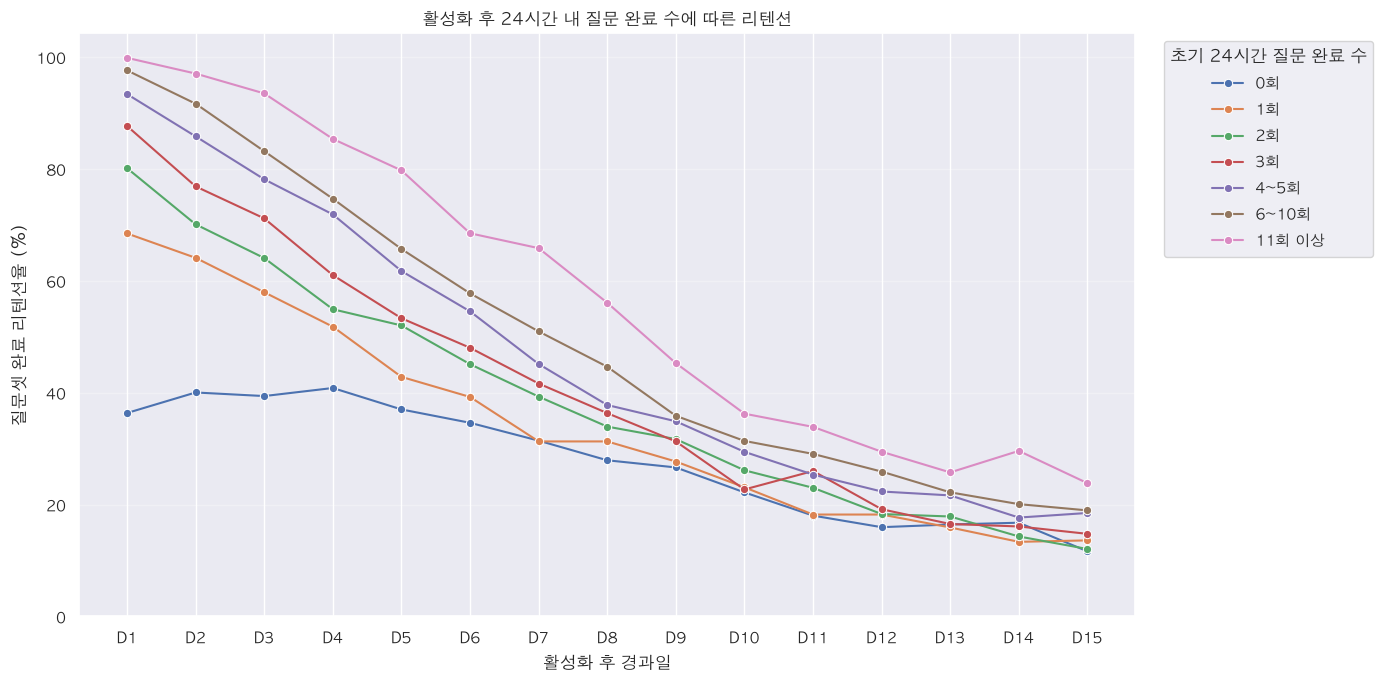

In [154]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=early_activity_retention_summary,
    x='retention_day',
    y='리텐션율(%)',
    hue='early_activity_group',
    marker='o',
)

plt.title('활성화 후 24시간 내 질문 완료 수에 따른 리텐션')
plt.xlabel('활성화 후 경과일')
plt.ylabel('질문셋 완료 리텐션율 (%)')
plt.xticks(
    range(1, 16),
    [f'D{day}' for day in range(1, 16)],
)
plt.ylim(bottom=0)
plt.grid(
    axis='y',
    alpha=0.3,
)
plt.legend(
    title='초기 24시간 질문 완료 수',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)
plt.tight_layout()
plt.show()

#### 💡 1-4-정리.
* 활성화 직후 24시간 동안 질문셋을 많이 완료한 사용자는 이후 D1~D15에서도 질문셋 완료 리텐션이 높은 경향을 보였다. 이는 활성화 직후의 질문 이용 경험이 이후 지속 이용을 구분하는 초기 행동 지표로 활용될 가능성을 보여준다.

### 1-5. 질문 신고 수가 많을수록 리텐션이 높을 것이다.

In [155]:
query = f"""
SELECT
    id AS report_id,
    reason,
    created_at AS reported_at,
    question_id,
    user_id
FROM `{PROJECT_ID}.{DATA_SET}.polls_questionreport`
WHERE
    reason IS NULL
    OR TRIM(reason) != '어떻게 이런 생각을? 이 질문 최고!'
"""

question_report = client.query(query).to_dataframe()

question_report['reported_at'] = to_analysis_timezone(
    question_report['reported_at']
)

print(question_report.shape)
display(question_report.head())

(49603, 5)


,report_id,reason,reported_at,question_id,user_id
0,4852,그냥 싫어,2023-05-07 21:14:13+09:00,99,894226
1,4971,그냥 싫어,2023-05-07 22:43:20+09:00,99,906185
2,5389,그냥 싫어,2023-05-08 11:16:54+09:00,99,944035
3,7884,그냥 싫어,2023-05-09 23:19:10+09:00,99,981801
4,11094,그냥 싫어,2023-05-11 22:26:01+09:00,99,887923


In [156]:
print(
    'report_id 중복:',
    question_report['report_id'].duplicated().sum()
)

print(
    '동일 사용자-질문 중복 신고:',
    question_report.duplicated(
        ['user_id', 'question_id']
    ).sum()
)

report_id 중복: 0
동일 사용자-질문 중복 신고: 6466


In [157]:
duplicate_user_question_report = (
    question_report[
        question_report.duplicated(
            ['user_id', 'question_id'],
            keep=False,
        )
    ]
    .sort_values(
        ['user_id', 'question_id', 'reported_at']
    )
)

display(duplicate_user_question_report.head(30))

,report_id,reason,reported_at,question_id,user_id
28568,2783,기타,2023-05-04 17:49:15+09:00,148,833714
28569,2784,기타,2023-05-04 17:49:25+09:00,148,833714
1296,14463,그냥 싫어,2023-05-13 14:04:57+09:00,127,835057
1311,51413,그냥 싫어,2023-06-04 07:01:19+09:00,127,835057
1312,51414,그냥 싫어,2023-06-04 07:02:21+09:00,127,835057
11977,14467,그냥 싫어,2023-05-13 14:05:50+09:00,476,835057
12049,51415,그냥 싫어,2023-06-04 07:04:46+09:00,476,835057
12050,51416,그냥 싫어,2023-06-04 07:05:21+09:00,476,835057
44302,2,이 질문은 재미없어요,2023-04-19 15:58:09+09:00,113,837672
38567,3,불쾌한 내용이 포함되어 있음,2023-04-19 15:58:17+09:00,113,837672


In [158]:
question_report_first = (
    question_report
    .sort_values(
        ['user_id', 'question_id', 'reported_at', 'report_id']
    )
    .drop_duplicates(
        ['user_id', 'question_id'],
        keep='first',
    )
    .copy()
)

print('중복 제거 전:', len(question_report))
print('중복 제거 후:', len(question_report_first))

print(
    '남은 사용자-질문 중복:',
    question_report_first.duplicated(
        ['user_id', 'question_id']
    ).sum()
)

중복 제거 전: 49603
중복 제거 후: 43137
남은 사용자-질문 중복: 0


In [159]:
early_24h_report_records = (
    question_report_first
    .merge(
        early_24h_activity[
            ['user_id', 'activation_at']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one',
    )
)

early_24h_report_records = (
    early_24h_report_records[
        early_24h_report_records['reported_at'].ge(
            early_24h_report_records['activation_at']
        )
        & early_24h_report_records['reported_at'].lt(
            early_24h_report_records['activation_at']
            + pd.Timedelta(hours=24)
        )
    ]
    .copy()
)

In [160]:
early_24h_report_count = (
    early_24h_report_records
    .groupby(
        'user_id',
        as_index=False,
    )
    .agg(
        reported_question_count_24h=(
            'question_id',
            'nunique',
        )
    )
)

In [161]:
early_24h_report_activity = (
    early_24h_activity
    .merge(
        early_24h_report_count,
        on='user_id',
        how='left',
        validate='one_to_one',
    )
)

early_24h_report_activity['reported_question_count_24h'] = (
    early_24h_report_activity['reported_question_count_24h']
    .fillna(0)
    .astype(int)
)

display(
    early_24h_report_activity[
        [
            'user_id',
            'activation_at',
            'reported_question_count_24h',
        ]
    ].head()
)

display(
    early_24h_report_activity[
        'reported_question_count_24h'
    ].describe(
        percentiles=[.25, .5, .75, .9, .95, .99]
    )
)

,user_id,activation_at,reported_question_count_24h
0,838466,2023-05-03 07:44:27.267798+09:00,0
1,838642,2023-05-05 16:21:24+09:00,0
2,839357,2023-04-30 01:55:27+09:00,0
3,840293,2023-05-04 20:29:51+09:00,0
4,840473,2023-05-04 22:50:41+09:00,0


count    4880.000000
mean        0.017828
std         0.159066
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
90%         0.000000
95%         0.000000
99%         1.000000
max         4.000000
Name: reported_question_count_24h, dtype: float64

In [162]:
early_report_distribution = (
    early_24h_report_activity
    .groupby(
        'reported_question_count_24h',
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique')
    )
    .sort_values('reported_question_count_24h')
)

early_report_distribution['사용자비율(%)'] = (
    early_report_distribution['사용자수']
    / early_report_distribution['사용자수'].sum()
    * 100
).round(2)

early_report_distribution['누적사용자비율(%)'] = (
    early_report_distribution['사용자비율(%)']
    .cumsum()
    .round(2)
)

display(early_report_distribution)

,reported_question_count_24h,사용자수,사용자비율(%),누적사용자비율(%)
0,0,4806,98.48,98.48
1,1,65,1.33,99.81
2,2,7,0.14,99.95
3,4,2,0.04,99.99


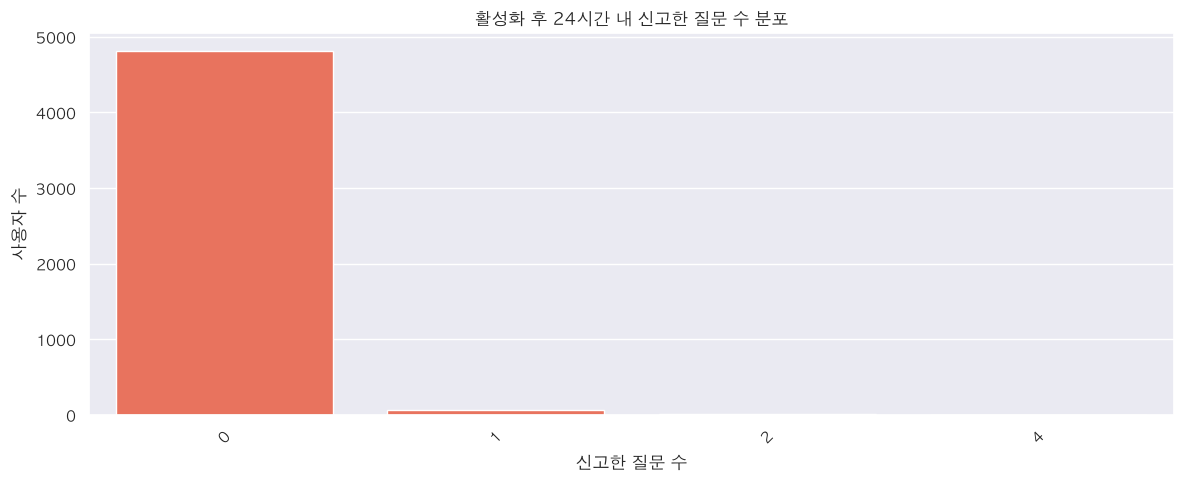

In [163]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=early_report_distribution,
    x='reported_question_count_24h',
    y='사용자수',
    color='tomato',
)

plt.title('활성화 후 24시간 내 신고한 질문 수 분포')
plt.xlabel('신고한 질문 수')
plt.ylabel('사용자 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [164]:
early_24h_report_activity['early_report_group'] = np.where(
    early_24h_report_activity[
        'reported_question_count_24h'
    ].eq(0),
    '신고 없음',
    '신고 있음',
)

In [165]:
early_report_group_summary = (
    early_24h_report_activity
    .groupby(
        'early_report_group',
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
        평균신고수=('reported_question_count_24h', 'mean'),
        최대신고수=('reported_question_count_24h', 'max'),
    )
)

early_report_group_summary['사용자비율(%)'] = (
    early_report_group_summary['사용자수']
    / early_report_group_summary['사용자수'].sum()
    * 100
).round(2)

early_report_group_summary['평균신고수'] = (
    early_report_group_summary['평균신고수'].round(2)
)

display(early_report_group_summary)

,early_report_group,사용자수,평균신고수,최대신고수,사용자비율(%)
0,신고 없음,4806,0.00,0,98.48
1,신고 있음,74,1.18,4,1.52


In [166]:
report_retention_user_day = (
    early_retention_observed
    .merge(
        early_24h_report_activity[
            [
                'user_id',
                'reported_question_count_24h',
                'early_report_group',
            ]
        ],
        on='user_id',
        how='inner',
        validate='many_to_one',
    )
)

display(
    report_retention_user_day[
        [
            'user_id',
            'reported_question_count_24h',
            'early_report_group',
            'retention_day',
            'retained',
        ]
    ].head(20)
)

,user_id,reported_question_count_24h,early_report_group,retention_day,retained
0,838466,0,신고 없음,1,True
1,838466,0,신고 없음,2,True
2,838466,0,신고 없음,3,True
3,838466,0,신고 없음,4,True
4,838466,0,신고 없음,5,False
5,838466,0,신고 없음,6,False
6,838466,0,신고 없음,7,False
7,838466,0,신고 없음,8,False
8,838466,0,신고 없음,9,False
9,838466,0,신고 없음,10,False


In [167]:
print(
    '연결 전 고유 사용자:',
    early_retention_observed['user_id'].nunique()
)

print(
    '연결 후 고유 사용자:',
    report_retention_user_day['user_id'].nunique()
)

연결 전 고유 사용자: 4880
연결 후 고유 사용자: 4880


In [168]:
report_retention_summary = (
    report_retention_user_day
    .groupby(
        [
            'early_report_group',
            'retention_day',
        ],
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
        리텐션사용자수=('retained', 'sum'),
        리텐션율=('retained', 'mean'),
    )
)

report_retention_summary['리텐션율(%)'] = (
    report_retention_summary['리텐션율']
    * 100
).round(2)

report_retention_summary = (
    report_retention_summary
    .drop(columns='리텐션율')
)

display(report_retention_summary)

,early_report_group,retention_day,사용자수,리텐션사용자수,리텐션율(%)
0,신고 없음,1,4806,4049,84.25
1,신고 없음,2,4806,3797,79.01
2,신고 없음,3,4806,3516,73.16
3,신고 없음,4,4806,3189,66.35
4,신고 없음,5,4806,2837,59.03
5,신고 없음,6,4806,2503,52.08
6,신고 없음,7,4806,2204,45.86
7,신고 없음,8,4806,1920,39.95
8,신고 없음,9,4806,1655,34.44
9,신고 없음,10,4806,1367,28.44


In [169]:
report_retention_pivot = (
    report_retention_summary
    .pivot(
        index='early_report_group',
        columns='retention_day',
        values='리텐션율(%)',
    )
)

report_retention_pivot.columns = [
    f'D{day}'
    for day in report_retention_pivot.columns
]

display(report_retention_pivot)

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
early_report_group,,,,,,,,,,,,,,,
신고 없음,84.25,79.01,73.16,66.35,59.03,52.08,45.86,39.95,34.44,28.44,25.86,22.45,20.33,19.08,17.06
신고 있음,97.30,90.54,75.68,68.92,58.11,56.76,52.70,45.95,28.38,36.49,31.08,28.38,25.68,20.27,22.97


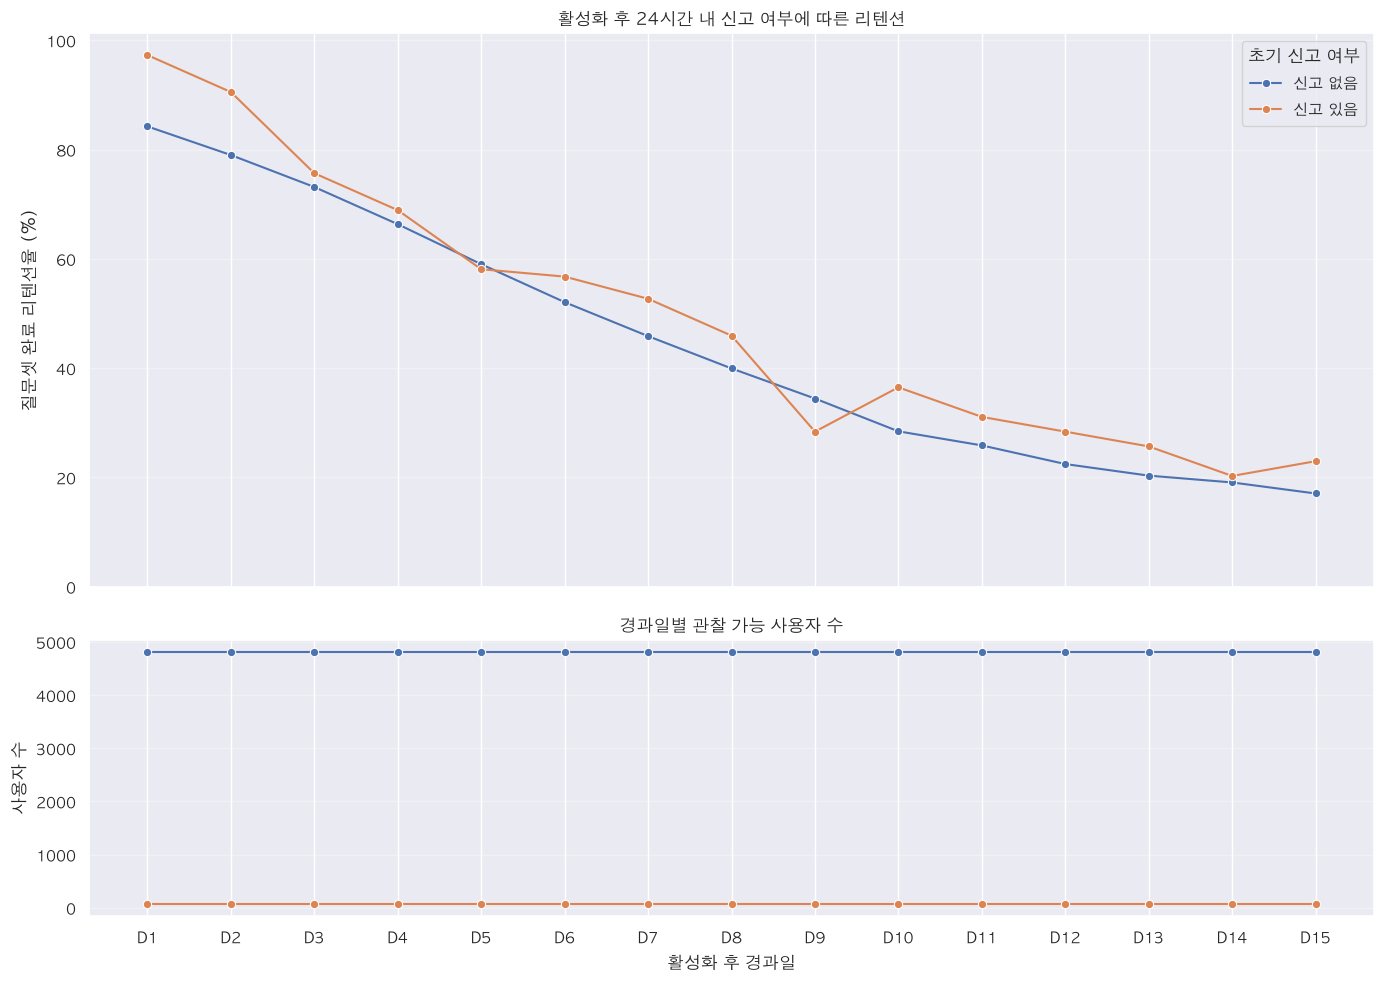

In [170]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]},
)

# 리텐션율
sns.lineplot(
    data=report_retention_summary,
    x='retention_day',
    y='리텐션율(%)',
    hue='early_report_group',
    marker='o',
    ax=axes[0],
)

axes[0].set_title(
    '활성화 후 24시간 내 신고 여부에 따른 리텐션'
)
axes[0].set_xlabel('')
axes[0].set_ylabel('질문셋 완료 리텐션율 (%)')
axes[0].set_ylim(bottom=0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(title='초기 신고 여부')

# 경과일별 관찰 사용자 수
sns.lineplot(
    data=report_retention_summary,
    x='retention_day',
    y='사용자수',
    hue='early_report_group',
    marker='o',
    ax=axes[1],
    legend=False,
)

axes[1].set_title('경과일별 관찰 가능 사용자 수')
axes[1].set_xlabel('활성화 후 경과일')
axes[1].set_ylabel('사용자 수')
axes[1].set_xticks(range(1, 16))
axes[1].set_xticklabels(
    [f'D{day}' for day in range(1, 16)]
)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 💡 1-5-정리.
* 활성화 후 24시간 이내 신고 경험이 있는 사용자와 없는 사용자의 이후 리텐션 차이를 탐색했다. 다만 신고 경험 사용자의 수가 적어 관찰된 차이를 일반적인 경향으로 확정하기 어렵다.

#### 1-5-2. 누적 신고 수에 따른 리텐션

In [171]:
report_history = (
    question_report_first
    .merge(
        user_activation[
            ['user_id', 'activation_at']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one',
    )
)

# 활성화 이후 신고만 사용
report_history = (
    report_history[
        report_history['reported_at']
        >= report_history['activation_at']
    ]
    .sort_values(
        ['user_id', 'reported_at', 'question_id']
    )
    .copy()
)

# 각 신고 시점까지의 누적 신고 질문 수
report_history['cumulative_report_count'] = (
    report_history
    .groupby('user_id')
    .cumcount()
    .add(1)
)

display(
    report_history[
        [
            'user_id',
            'question_id',
            'reported_at',
            'cumulative_report_count',
        ]
    ].head(20)
)

,user_id,question_id,reported_at,cumulative_report_count
0,840512,511,2023-05-07 01:59:13+09:00,1
1,849436,171,2023-04-28 13:28:21+09:00,1
2,849452,266,2023-04-29 00:54:55+09:00,1
3,849452,324,2023-04-29 22:35:18+09:00,2
5,849454,185,2023-04-29 21:16:11+09:00,1
4,849454,114,2023-05-01 13:18:31+09:00,2
6,849548,309,2023-04-29 19:34:36+09:00,1
7,849692,257,2023-04-29 22:25:27+09:00,1
8,849922,272,2023-04-30 11:52:15+09:00,1
9,850007,305,2023-04-28 23:29:22+09:00,1


In [172]:
report_count_decreased = (
    report_history
    .groupby('user_id')['cumulative_report_count']
    .diff()
    .lt(0)
    .sum()
)

print('누적 신고 수 감소 건수:', report_count_decreased)

누적 신고 수 감소 건수: 0


In [173]:
# 각 D1 ~ D15가 시작되기 직전 누적 신고 수
report_retention_base = (
    early_retention_observed[
        [
            'user_id',
            'retention_day',
            'window_start_at',
            'window_end_at',
            'retained',
        ]
    ]
    .copy()
)

report_retention_base['report_snapshot_at'] = (
    report_retention_base['window_start_at']
)

In [174]:
# 시각순으로 정렬
report_retention_base = (
    report_retention_base
    .sort_values(
        ['report_snapshot_at', 'user_id']
    )
)

report_history_sorted = (
    report_history[
        [
            'user_id',
            'reported_at',
            'cumulative_report_count',
        ]
    ]
    .sort_values(
        ['reported_at', 'user_id']
    )
)

In [175]:
# 경과일 시작 직전 확인된 마지막 누적 신고 수 연결
report_retention_snapshot = pd.merge_asof(
    report_retention_base,
    report_history_sorted,
    left_on='report_snapshot_at',
    right_on='reported_at',
    by='user_id',
    direction='backward',

    # 경과일 시작 시각과 정확히 같은 신고는 제외
    allow_exact_matches=False,
)

In [176]:
# 신고 기록 없으면 누적 신고 수 0
report_retention_snapshot['cumulative_report_count'] = (
    report_retention_snapshot['cumulative_report_count']
    .fillna(0)
    .astype(int)
)

In [177]:
display(
    report_retention_snapshot[
        [
            'user_id',
            'retention_day',
            'report_snapshot_at',
            'reported_at',
            'cumulative_report_count',
            'retained',
        ]
    ]
    .sort_values(
        ['user_id', 'retention_day']
    )
    .head(30)
)

,user_id,retention_day,report_snapshot_at,reported_at,cumulative_report_count,retained
1459,838466,1,2023-05-04 07:44:27.267798+09:00,NaT,0,True
2275,838466,2,2023-05-05 07:44:27.267798+09:00,NaT,0,True
3264,838466,3,2023-05-06 07:44:27.267798+09:00,NaT,0,True
4685,838466,4,2023-05-07 07:44:27.267798+09:00,NaT,0,True
6338,838466,5,2023-05-08 07:44:27.267798+09:00,NaT,0,False
8137,838466,6,2023-05-09 07:44:27.267798+09:00,NaT,0,False
10065,838466,7,2023-05-10 07:44:27.267798+09:00,NaT,0,False
12153,838466,8,2023-05-11 07:44:27.267798+09:00,NaT,0,False
14403,838466,9,2023-05-12 07:44:27.267798+09:00,NaT,0,False
16969,838466,10,2023-05-13 07:44:27.267798+09:00,NaT,0,False


In [178]:
report_snapshot_check = (
    report_retention_snapshot
    .sort_values(
        ['user_id', 'retention_day']
    )
)

decreased_count = (
    report_snapshot_check
    .groupby('user_id')['cumulative_report_count']
    .diff()
    .lt(0)
    .sum()
)

print('경과일별 누적 신고 수 감소 건수:', decreased_count)

경과일별 누적 신고 수 감소 건수: 0


In [179]:
report_retention_snapshot['cumulative_report_group'] = np.where(
    report_retention_snapshot[
        'cumulative_report_count'
    ].eq(0),
    '누적 신고 없음',
    '누적 신고 있음',
)

In [180]:
cumulative_report_group_count = (
    report_retention_snapshot
    .groupby(
        [
            'retention_day',
            'cumulative_report_group',
        ],
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
        평균누적신고수=('cumulative_report_count', 'mean'),
        최대누적신고수=('cumulative_report_count', 'max'),
    )
)

cumulative_report_group_count['평균누적신고수'] = (
    cumulative_report_group_count['평균누적신고수']
    .round(2)
)

display(cumulative_report_group_count)

,retention_day,cumulative_report_group,사용자수,평균누적신고수,최대누적신고수
0,1,누적 신고 없음,4806,0.00,0
1,1,누적 신고 있음,74,1.18,4
2,2,누적 신고 없음,4778,0.00,0
3,2,누적 신고 있음,102,1.15,4
4,3,누적 신고 없음,4758,0.00,0
5,3,누적 신고 있음,122,1.26,7
6,4,누적 신고 없음,4742,0.00,0
7,4,누적 신고 있음,138,1.32,7
8,5,누적 신고 없음,4732,0.00,0
9,5,누적 신고 있음,148,1.34,7


In [181]:
cumulative_report_retention_summary = (
    report_retention_snapshot
    .groupby(
        [
            'cumulative_report_group',
            'retention_day',
        ],
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
        리텐션사용자수=('retained', 'sum'),
        리텐션율=('retained', 'mean'),
    )
)

cumulative_report_retention_summary['리텐션율(%)'] = (
    cumulative_report_retention_summary['리텐션율']
    * 100
).round(2)

cumulative_report_retention_summary = (
    cumulative_report_retention_summary
    .drop(columns='리텐션율')
)

display(cumulative_report_retention_summary)

,cumulative_report_group,retention_day,사용자수,리텐션사용자수,리텐션율(%)
0,누적 신고 없음,1,4806,4049,84.25
1,누적 신고 없음,2,4778,3769,78.88
2,누적 신고 없음,3,4758,3474,73.01
3,누적 신고 없음,4,4742,3138,66.17
4,누적 신고 없음,5,4732,2776,58.66
5,누적 신고 없음,6,4726,2451,51.86
6,누적 신고 없음,7,4722,2144,45.40
7,누적 신고 없음,8,4717,1866,39.56
8,누적 신고 없음,9,4713,1612,34.20
9,누적 신고 없음,10,4711,1329,28.21


In [182]:
cumulative_report_retention_pivot = (
    cumulative_report_retention_summary
    .pivot(
        index='cumulative_report_group',
        columns='retention_day',
        values='리텐션율(%)',
    )
)

cumulative_report_retention_pivot.columns = [
    f'D{day}'
    for day in cumulative_report_retention_pivot.columns
]

display(cumulative_report_retention_pivot)

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
cumulative_report_group,,,,,,,,,,,,,,,
누적 신고 없음,84.25,78.88,73.01,66.17,58.66,51.86,45.40,39.56,34.20,28.21,25.88,22.30,20.07,18.86,16.89
누적 신고 있음,97.30,93.14,80.33,73.91,70.27,61.04,62.66,53.99,38.32,38.46,27.65,29.24,29.82,25.73,24.42


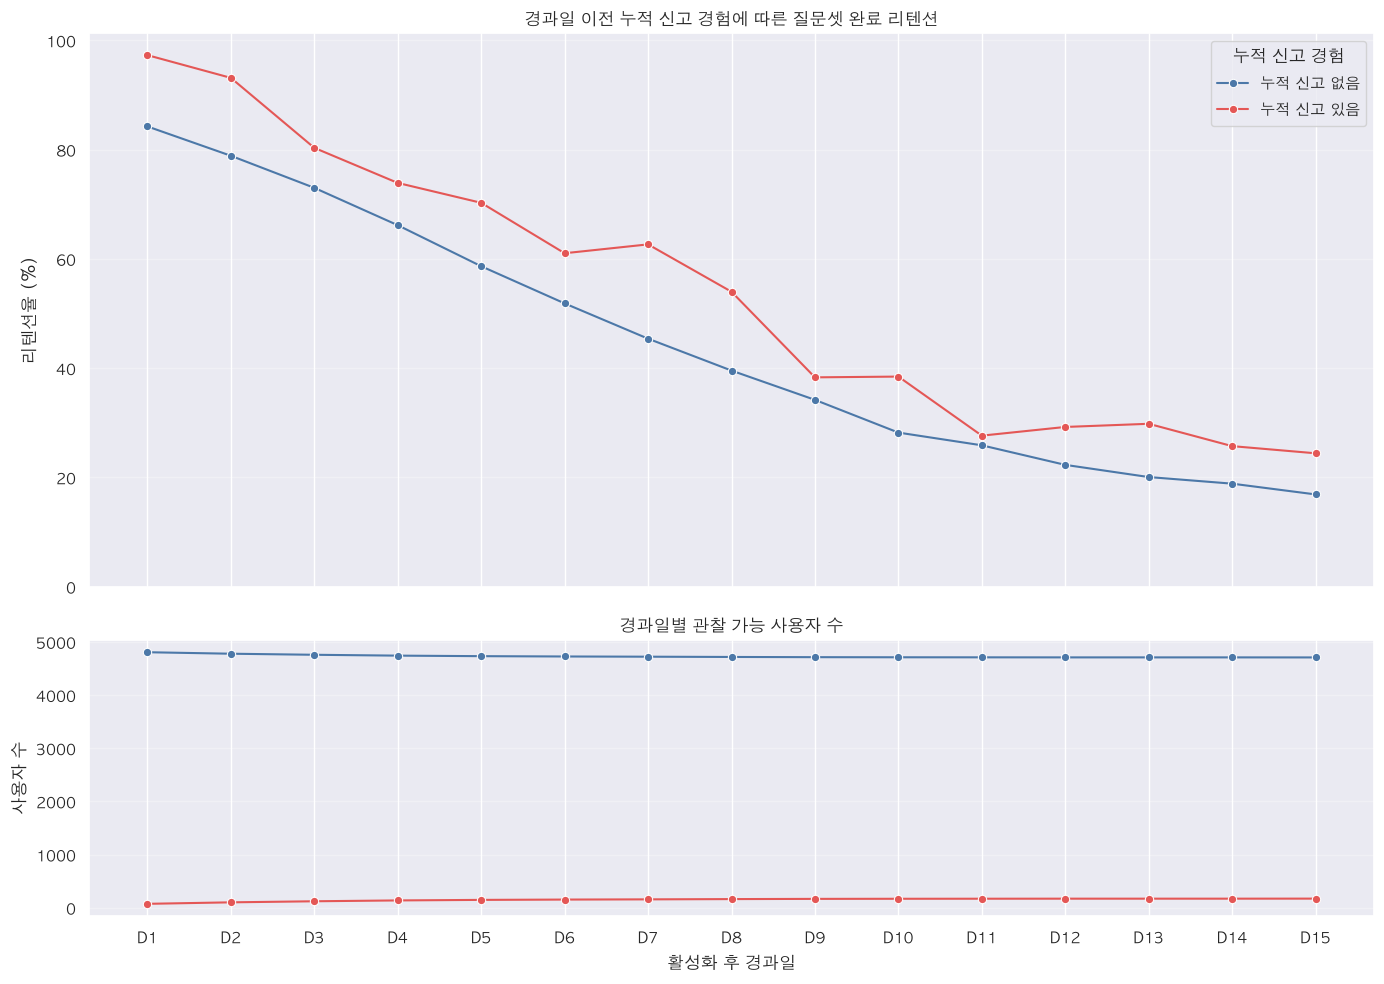

In [183]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]},
)

group_order = [
    '누적 신고 없음',
    '누적 신고 있음',
]

colors = {
    '누적 신고 없음': '#4C78A8',
    '누적 신고 있음': '#E45756',
}

# 1. 리텐션율
sns.lineplot(
    data=cumulative_report_retention_summary,
    x='retention_day',
    y='리텐션율(%)',
    hue='cumulative_report_group',
    hue_order=group_order,
    palette=colors,
    marker='o',
    ax=axes[0],
)

axes[0].set_title(
    '경과일 이전 누적 신고 경험에 따른 질문셋 완료 리텐션'
)
axes[0].set_xlabel('')
axes[0].set_ylabel('리텐션율 (%)')
axes[0].set_ylim(bottom=0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(title='누적 신고 경험')

# 2. 경과일별 사용자 수
sns.lineplot(
    data=cumulative_report_retention_summary,
    x='retention_day',
    y='사용자수',
    hue='cumulative_report_group',
    hue_order=group_order,
    palette=colors,
    marker='o',
    legend=False,
    ax=axes[1],
)

axes[1].set_title('경과일별 관찰 가능 사용자 수')
axes[1].set_xlabel('활성화 후 경과일')
axes[1].set_ylabel('사용자 수')
axes[1].set_xticks(range(1, 16))
axes[1].set_xticklabels(
    [f'D{day}' for day in range(1, 16)]
)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 💡 1-5-2-정리. 
* 각 경과일 시작 전까지 신고 경험이 있는 사용자와 없는 사용자의 해당 경과일 질문셋 완료율을 비교한 결과이다. 이 차이에는 신고 경험뿐만 아니라 기존 질문 이용량의 차이도 포함될 수 있다.

### 1-6. 유저 신고 수가 많을수록 리텐션이 높을 것이다.

In [184]:
query = f"""
SELECT
    id AS timeline_report_id,
    reason,
    created_at AS reported_at,
    user_id AS reporter_user_id,
    reported_user_id,
    user_question_record_id
FROM `{PROJECT_ID}.{DATA_SET}.accounts_timelinereport`
"""

timeline_report = client.query(query).to_dataframe()

timeline_report['reported_at'] = to_analysis_timezone(
    timeline_report['reported_at']
)

print(timeline_report.shape)
display(timeline_report.head())

(208, 6)


,timeline_report_id,reason,reported_at,reporter_user_id,reported_user_id,user_question_record_id
0,4794,광고,2023-05-10 23:27:44+09:00,1084275,917587,18272641
1,7168,광고,2023-05-12 23:54:46+09:00,1184397,967873,28992803
2,7169,광고,2023-05-12 23:54:52+09:00,1184397,967873,28992803
3,9998,광고,2023-05-15 01:49:58+09:00,1214760,1207784,46645583
4,10257,광고,2023-05-15 15:08:04+09:00,1228033,1250642,48820574


In [185]:
display(
    timeline_report[
        [
            'timeline_report_id',
            'reason',
            'reported_at',
            'reporter_user_id',
            'reported_user_id',
            'user_question_record_id',
        ]
    ].isna().sum()
)

display(
    timeline_report['reason']
    .value_counts(dropna=False)
    .rename_axis('reason')
    .reset_index(name='신고수')
)

timeline_report_id         0
reason                     0
reported_at                0
reporter_user_id           0
reported_user_id           0
user_question_record_id    0
dtype: int64

,reason,신고수
0,허위 사실 언급,80
1,친구를 비하하거나 조롱하는 어투,64
2,선정적이거나 폭력적인 내용,39
3,타인을 사칭함,15
4,광고,10


In [186]:
print(
    '신고 ID 중복:',
    timeline_report['timeline_report_id']
    .duplicated()
    .sum()
)

print(
    '동일 사용자-응답 기록 중복 신고:',
    timeline_report.duplicated(
        [
            'reporter_user_id',
            'user_question_record_id',
        ]
    ).sum()
)

신고 ID 중복: 0
동일 사용자-응답 기록 중복 신고: 44


In [187]:
duplicate_timeline_report = (
    timeline_report[
        timeline_report.duplicated(
            [
                'reporter_user_id',
                'user_question_record_id',
            ],
            keep=False,
        )
    ]
    .sort_values(
        [
            'reporter_user_id',
            'user_question_record_id',
            'reported_at',
        ]
    )
)

display(duplicate_timeline_report.head(30))

,timeline_report_id,reason,reported_at,reporter_user_id,reported_user_id,user_question_record_id
175,10106,허위 사실 언급,2023-05-15 10:52:56+09:00,866940,1140485,48015056
176,10107,허위 사실 언급,2023-05-15 10:53:00+09:00,866940,1140485,48015056
136,612,허위 사실 언급,2023-05-07 12:03:58+09:00,867048,885473,5421572
137,613,허위 사실 언급,2023-05-07 12:04:01+09:00,867048,885473,5421572
138,614,허위 사실 언급,2023-05-07 12:04:03+09:00,867048,885473,5421572
139,615,허위 사실 언급,2023-05-07 12:04:04+09:00,867048,885473,5421572
140,616,허위 사실 언급,2023-05-07 12:04:06+09:00,867048,885473,5421572
156,6917,허위 사실 언급,2023-05-12 21:05:59+09:00,887729,962262,24679508
157,6918,허위 사실 언급,2023-05-12 21:06:04+09:00,887729,962262,24679508
12,1644,선정적이거나 폭력적인 내용,2023-05-08 11:02:11+09:00,888390,883505,8041636


In [188]:
# 신고 대상 응답 ID가 있는 기록
timeline_report_with_record = (
    timeline_report[
        timeline_report['user_question_record_id'].notna()
    ]
    .sort_values(
        [
            'reporter_user_id',
            'user_question_record_id',
            'reported_at',
            'timeline_report_id',
        ]
    )
    .drop_duplicates(
        [
            'reporter_user_id',
            'user_question_record_id',
        ],
        keep='first',
    )
)

# 신고 대상 응답 ID가 없는 기록은 report_id 기준으로 유지
timeline_report_without_record = (
    timeline_report[
        timeline_report['user_question_record_id'].isna()
    ]
    .drop_duplicates(
        'timeline_report_id',
        keep='first',
    )
)

timeline_report_first = (
    pd.concat(
        [
            timeline_report_with_record,
            timeline_report_without_record,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            'reporter_user_id',
            'reported_at',
            'timeline_report_id',
        ]
    )
    .reset_index(drop=True)
)

In [189]:
print('중복 제거 전:', len(timeline_report))
print('중복 제거 후:', len(timeline_report_first))

print(
    '응답 ID가 있는 기록의 남은 중복:',
    timeline_report_first[
        timeline_report_first[
            'user_question_record_id'
        ].notna()
    ]
    .duplicated(
        [
            'reporter_user_id',
            'user_question_record_id',
        ]
    )
    .sum()
)

중복 제거 전: 208
중복 제거 후: 164
응답 ID가 있는 기록의 남은 중복: 0


In [190]:
self_report = timeline_report_first[
    timeline_report_first['reporter_user_id']
    == timeline_report_first['reported_user_id']
]

print('자기 자신 신고 건수:', len(self_report))
display(self_report.head(20))

자기 자신 신고 건수: 3


,timeline_report_id,reason,reported_at,reporter_user_id,reported_user_id,user_question_record_id
51,8671,타인을 사칭함,2023-05-14 01:28:52+09:00,1139317,1139317,38840013
77,8619,선정적이거나 폭력적인 내용,2023-05-14 01:15:07+09:00,1173995,1173995,38874638
79,8902,선정적이거나 폭력적인 내용,2023-05-14 08:09:01+09:00,1180707,1180707,38577730


In [191]:
user_timeline_report = (
    timeline_report_first
    .rename(
        columns={
            'reporter_user_id': 'user_id',
        }
    )
    .copy()
)

display(
    user_timeline_report[
        [
            'timeline_report_id',
            'user_id',
            'reported_user_id',
            'user_question_record_id',
            'reason',
            'reported_at',
        ]
    ].head()
)

,timeline_report_id,user_id,reported_user_id,user_question_record_id,reason,reported_at
0,748,834089,837235,4657546,타인을 사칭함,2023-05-07 15:18:23+09:00
1,6733,863948,891201,23366393,허위 사실 언급,2023-05-12 19:00:17+09:00
2,10106,866940,1140485,48015056,허위 사실 언급,2023-05-15 10:52:56+09:00
3,612,867048,885473,5421572,허위 사실 언급,2023-05-07 12:03:58+09:00
4,530,875311,887103,5096786,선정적이거나 폭력적인 내용,2023-05-07 04:49:18+09:00


In [192]:
user_timeline_report = (
    user_timeline_report[
        user_timeline_report['user_id']
        != user_timeline_report['reported_user_id']
    ]
    .copy()
)

print(
    '자기 자신 신고 제거 후 남은 건수:',
    len(user_timeline_report)
)

print(
    '남은 자기 자신 신고:',
    (
        user_timeline_report['user_id']
        == user_timeline_report['reported_user_id']
    ).sum()
)

자기 자신 신고 제거 후 남은 건수: 161
남은 자기 자신 신고: 0


In [193]:
timeline_report_history = (
    user_timeline_report
    .merge(
        user_activation[
            ['user_id', 'activation_at']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one',
    )
)

# 활성화 이후 발생한 신고만 사용
timeline_report_history = (
    timeline_report_history[
        timeline_report_history['reported_at']
        >= timeline_report_history['activation_at']
    ]
    .sort_values(
        [
            'user_id',
            'reported_at',
            'timeline_report_id',
        ]
    )
    .copy()
)

In [194]:
timeline_report_history['cumulative_user_report_count'] = (
    timeline_report_history
    .groupby('user_id')
    .cumcount()
    .add(1)
)

In [195]:
display(
    timeline_report_history[
        [
            'user_id',
            'reported_user_id',
            'user_question_record_id',
            'reported_at',
            'cumulative_user_report_count',
        ]
    ].head(30)
)

,user_id,reported_user_id,user_question_record_id,reported_at,cumulative_user_report_count
0,866940,1140485,48015056,2023-05-15 10:52:56+09:00,1
1,875311,887103,5096786,2023-05-07 04:49:18+09:00,1
2,876580,877824,11659218,2023-05-09 16:27:18+09:00,1
3,877326,880089,7088485,2023-05-08 00:38:06+09:00,1
4,878909,885328,4378751,2023-05-06 19:01:39+09:00,1
5,881298,881048,4018679,2023-05-06 14:41:19+09:00,1
6,881335,1196718,65520396,2023-05-17 21:25:16+09:00,1
7,881335,1196718,65062418,2023-05-17 21:25:21+09:00,2
8,881945,887882,4120914,2023-05-06 15:26:59+09:00,1
9,883570,885047,7951149,2023-05-08 09:25:47+09:00,1


In [196]:
timeline_report_decreased = (
    timeline_report_history
    .groupby('user_id')[
        'cumulative_user_report_count'
    ]
    .diff()
    .lt(0)
    .sum()
)

print(
    '누적 유저 신고 수 감소 건수:',
    timeline_report_decreased,
)

누적 유저 신고 수 감소 건수: 0


In [197]:
user_report_retention_base = (
    early_retention_observed[
        [
            'user_id',
            'retention_day',
            'window_start_at',
            'window_end_at',
            'retained',
        ]
    ]
    .copy()
)

user_report_retention_base['report_snapshot_at'] = (
    user_report_retention_base['window_start_at']
)

In [198]:
user_report_retention_base = (
    user_report_retention_base
    .sort_values(
        ['report_snapshot_at', 'user_id']
    )
)

timeline_report_history_sorted = (
    timeline_report_history[
        [
            'user_id',
            'reported_at',
            'cumulative_user_report_count',
        ]
    ]
    .sort_values(
        ['reported_at', 'user_id']
    )
)

In [199]:
user_report_retention_snapshot = pd.merge_asof(
    user_report_retention_base,
    timeline_report_history_sorted,
    left_on='report_snapshot_at',
    right_on='reported_at',
    by='user_id',
    direction='backward',

    # 경과일 시작 시각과 정확히 같은 신고는 제외
    allow_exact_matches=False,
)

In [200]:
user_report_retention_snapshot[
    'cumulative_user_report_count'
] = (
    user_report_retention_snapshot[
        'cumulative_user_report_count'
    ]
    .fillna(0)
    .astype(int)
)

In [201]:
display(
    user_report_retention_snapshot[
        [
            'user_id',
            'retention_day',
            'report_snapshot_at',
            'reported_at',
            'cumulative_user_report_count',
            'retained',
        ]
    ]
    .sort_values(
        ['user_id', 'retention_day']
    )
    .head(30)
)

,user_id,retention_day,report_snapshot_at,reported_at,cumulative_user_report_count,retained
1459,838466,1,2023-05-04 07:44:27.267798+09:00,NaT,0,True
2275,838466,2,2023-05-05 07:44:27.267798+09:00,NaT,0,True
3264,838466,3,2023-05-06 07:44:27.267798+09:00,NaT,0,True
4685,838466,4,2023-05-07 07:44:27.267798+09:00,NaT,0,True
6338,838466,5,2023-05-08 07:44:27.267798+09:00,NaT,0,False
8137,838466,6,2023-05-09 07:44:27.267798+09:00,NaT,0,False
10065,838466,7,2023-05-10 07:44:27.267798+09:00,NaT,0,False
12153,838466,8,2023-05-11 07:44:27.267798+09:00,NaT,0,False
14403,838466,9,2023-05-12 07:44:27.267798+09:00,NaT,0,False
16969,838466,10,2023-05-13 07:44:27.267798+09:00,NaT,0,False


In [202]:
user_report_snapshot_check = (
    user_report_retention_snapshot
    .sort_values(
        ['user_id', 'retention_day']
    )
)

decreased_count = (
    user_report_snapshot_check
    .groupby('user_id')[
        'cumulative_user_report_count'
    ]
    .diff()
    .lt(0)
    .sum()
)

print(
    '경과일별 누적 유저 신고 수 감소 건수:',
    decreased_count,
)

경과일별 누적 유저 신고 수 감소 건수: 0


In [203]:
user_report_retention_snapshot[
    'cumulative_user_report_group'
] = np.where(
    user_report_retention_snapshot[
        'cumulative_user_report_count'
    ].eq(0),
    '누적 유저 신고 없음',
    '누적 유저 신고 있음',
)

In [204]:
cumulative_user_report_group_count = (
    user_report_retention_snapshot
    .groupby(
        [
            'retention_day',
            'cumulative_user_report_group',
        ],
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
        평균누적신고수=(
            'cumulative_user_report_count',
            'mean',
        ),
        최대누적신고수=(
            'cumulative_user_report_count',
            'max',
        ),
    )
)

cumulative_user_report_group_count[
    '평균누적신고수'
] = (
    cumulative_user_report_group_count[
        '평균누적신고수'
    ].round(2)
)

display(cumulative_user_report_group_count)

,retention_day,cumulative_user_report_group,사용자수,평균누적신고수,최대누적신고수
0,1,누적 유저 신고 없음,4847,0.00,0
1,1,누적 유저 신고 있음,33,1.88,9
2,2,누적 유저 신고 없음,4823,0.00,0
3,2,누적 유저 신고 있음,57,1.67,9
4,3,누적 유저 신고 없음,4815,0.00,0
5,3,누적 유저 신고 있음,65,1.65,9
6,4,누적 유저 신고 없음,4809,0.00,0
7,4,누적 유저 신고 있음,71,1.59,9
8,5,누적 유저 신고 없음,4803,0.00,0
9,5,누적 유저 신고 있음,77,1.56,9


In [205]:
cumulative_user_report_retention_summary = (
    user_report_retention_snapshot
    .groupby(
        [
            'cumulative_user_report_group',
            'retention_day',
        ],
        as_index=False,
    )
    .agg(
        사용자수=('user_id', 'nunique'),
        리텐션사용자수=('retained', 'sum'),
        리텐션율=('retained', 'mean'),
    )
)

cumulative_user_report_retention_summary[
    '리텐션율(%)'
] = (
    cumulative_user_report_retention_summary[
        '리텐션율'
    ]
    * 100
).round(2)

cumulative_user_report_retention_summary = (
    cumulative_user_report_retention_summary
    .drop(columns='리텐션율')
)

display(cumulative_user_report_retention_summary)

,cumulative_user_report_group,retention_day,사용자수,리텐션사용자수,리텐션율(%)
0,누적 유저 신고 없음,1,4847,4090,84.38
1,누적 유저 신고 없음,2,4823,3811,79.02
2,누적 유저 신고 없음,3,4815,3514,72.98
3,누적 유저 신고 없음,4,4809,3180,66.13
4,누적 유저 신고 없음,5,4803,2825,58.82
5,누적 유저 신고 없음,6,4800,2495,51.98
6,누적 유저 신고 없음,7,4797,2201,45.88
7,누적 유저 신고 없음,8,4794,1922,40.09
8,누적 유저 신고 없음,9,4793,1650,34.43
9,누적 유저 신고 없음,10,4792,1373,28.65


In [206]:
cumulative_user_report_retention_pivot = (
    cumulative_user_report_retention_summary
    .pivot(
        index='cumulative_user_report_group',
        columns='retention_day',
        values='리텐션율(%)',
    )
)

cumulative_user_report_retention_pivot.columns = [
    f'D{day}'
    for day in cumulative_user_report_retention_pivot.columns
]

display(cumulative_user_report_retention_pivot)

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
cumulative_user_report_group,,,,,,,,,,,,,,,
누적 유저 신고 없음,84.38,79.02,72.98,66.13,58.82,51.98,45.88,40.09,34.43,28.65,25.90,22.47,20.29,19.00,17.16
누적 유저 신고 있음,93.94,92.98,89.23,84.51,71.43,62.50,50.60,37.21,29.89,23.86,28.41,26.14,26.67,24.44,16.67


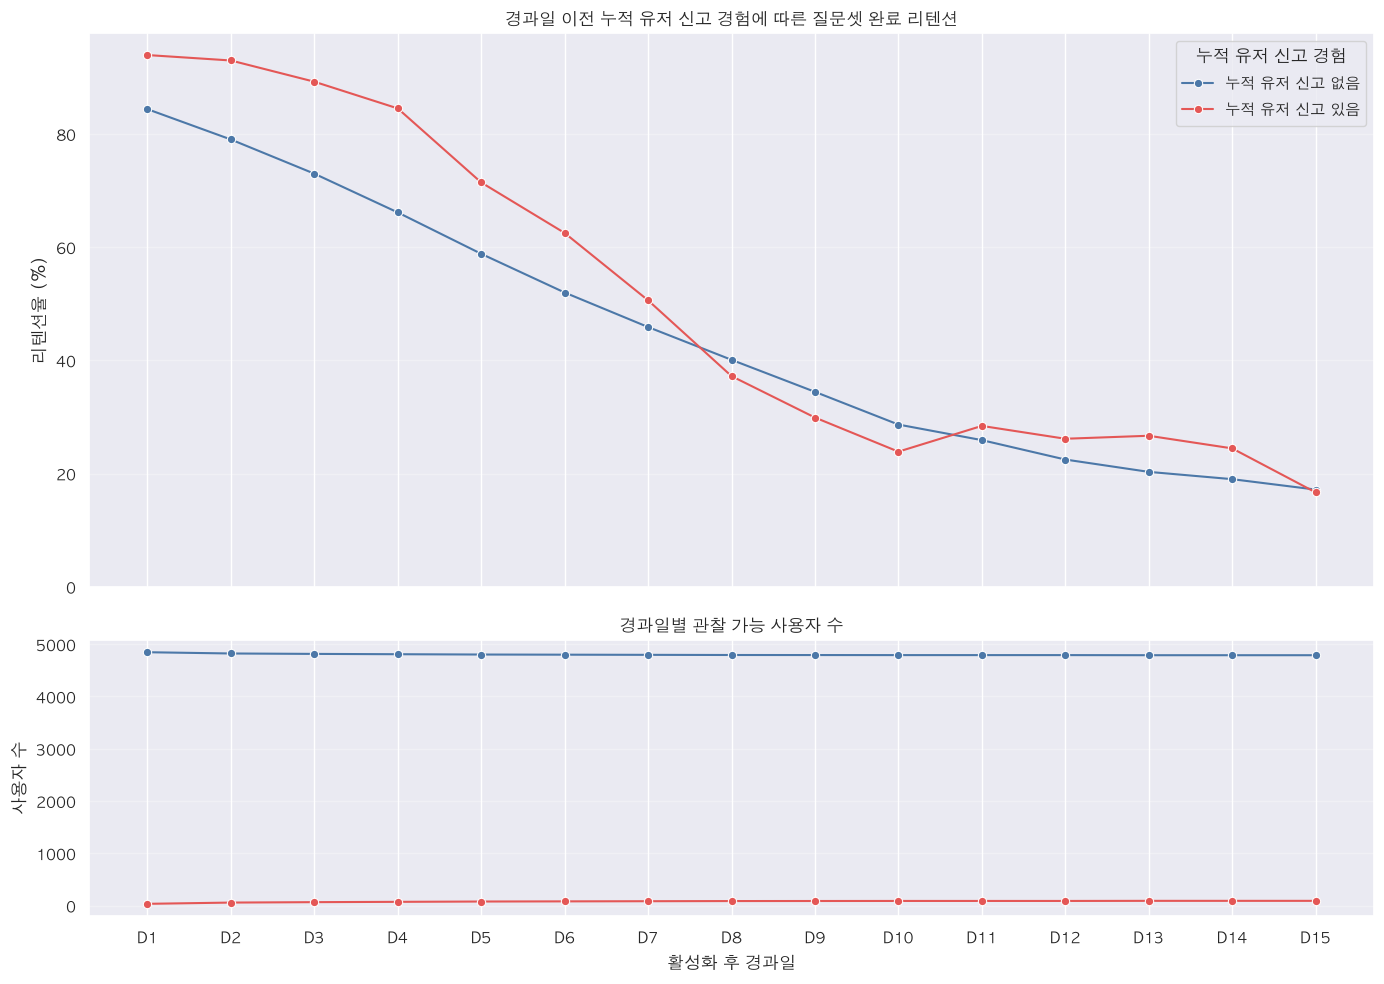

In [207]:
group_order = [
    '누적 유저 신고 없음',
    '누적 유저 신고 있음',
]

colors = {
    '누적 유저 신고 없음': '#4C78A8',
    '누적 유저 신고 있음': '#E45756',
}

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]},
)

# 1. 리텐션율
sns.lineplot(
    data=cumulative_user_report_retention_summary,
    x='retention_day',
    y='리텐션율(%)',
    hue='cumulative_user_report_group',
    hue_order=group_order,
    palette=colors,
    marker='o',
    ax=axes[0],
)

axes[0].set_title(
    '경과일 이전 누적 유저 신고 경험에 따른 질문셋 완료 리텐션'
)
axes[0].set_xlabel('')
axes[0].set_ylabel('리텐션율 (%)')
axes[0].set_ylim(bottom=0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(title='누적 유저 신고 경험')

# 2. 경과일별 관찰 가능 사용자 수
sns.lineplot(
    data=cumulative_user_report_retention_summary,
    x='retention_day',
    y='사용자수',
    hue='cumulative_user_report_group',
    hue_order=group_order,
    palette=colors,
    marker='o',
    legend=False,
    ax=axes[1],
)

axes[1].set_title('경과일별 관찰 가능 사용자 수')
axes[1].set_xlabel('활성화 후 경과일')
axes[1].set_ylabel('사용자 수')
axes[1].set_xticks(range(1, 16))
axes[1].set_xticklabels(
    [f'D{day}' for day in range(1, 16)]
)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 💡 1-6-정리.
* 경과일 이전까지 다른 사용자의 타임라인 기록을 신고한 경험이 있는 사용자와 신고 경험이 없는 사용자의 당일 질문셋 완료율을 비교하였다. 관찰된 차이에는 신고 경험뿐만 아니라 기존 서비스 활동량의 차이도 포함될 수 있다.

### 💡 1-정리.

## Retention 가설별 탐색 결과

### 분석 기준

- 사용자가 서비스를 이용할 수 있게 된 `activation_at`을 분석 시작점으로 설정하였다.
- 리텐션 행동은 해당 경과일의 **질문셋 완료 여부**로 정의하였다.
- 동일한 날 질문셋을 여러 번 완료하더라도 리텐션은 1건으로 계산하였다.
- 각 경과일을 끝까지 관찰할 수 있는 사용자만 해당 경과일의 분모에 포함하였다.

현재 결과는 사용자 행동 간의 관계를 확인한 탐색적 분석이다.  
통계적 유의성이나 인과관계까지 검증한 결과는 아니다.

---

### 1. 활성화 소요 시간이 짧을수록 리텐션이 높을 것이다

활성화까지 걸린 시간이 짧은 사용자는 D1~D2의 초기 리텐션이 상대적으로 높게 나타났다.

그러나 이후 경과일에서는 활성화 속도에 따른 리텐션 순서가 일관되게 유지되지 않았다.

따라서 빠른 활성화는 장기 리텐션 전반보다는 **활성화 직후의 초기 재이용과 관련된 지표**로 해석하는 것이 적절하다.

---

### 2. 친구 수가 많을수록 리텐션이 높을 것이다

각 경과일 시작 시점의 누적 친구 수가 많은 사용자일수록 해당 경과일의 질문셋 완료율이 높게 나타났다.

이러한 관계는 D1~D15에서 비교적 일관되게 확인되었으며, 친구 수가 40명 이상인 구간부터는 리텐션 상승 폭이 점차 줄어드는 모습도 나타났다.

따라서 친구 수는 지속 이용과 밀접한 관계를 보이는 사용자 상태 지표라고 볼 수 있다.

다만 친구가 많아서 리텐션이 높아졌다고 단정할 수는 없다. 원래 활동성이 높은 사용자가 친구도 많이 형성하고 질문 기능도 계속 이용했을 가능성이 함께 존재한다.

---

### 3. 이전 질문셋 완료 경험이 많을수록 리텐션이 높을 것이다

각 경과일 시작 전까지 누적한 질문셋 완료 수가 많은 사용자일수록 해당 경과일에도 질문셋을 완료할 가능성이 높게 나타났다.

이는 과거 질문 이용량이 이후 질문 이용 여부를 구분하는 강한 행동 지표임을 보여준다.

다만 누적 완료 수는 사용자의 기존 활동성을 직접 반영하는 지표이므로, 질문 완료 경험 자체가 이후 리텐션을 높였다고 해석하기는 어렵다.

---

### 4. 활성화 후 초기 24시간의 질문 완료 수가 많을수록 리텐션이 높을 것이다

활성화 후 첫 24시간 동안 질문셋을 많이 완료한 사용자일수록 이후 D1~D15 리텐션이 높은 경향이 확인되었다.

이 분석은 초기 24시간의 행동으로 사용자를 한 번 분류한 뒤 이후 행동을 추적했기 때문에, 누적 질문 완료 수를 사용한 분석보다 선후관계가 명확하다.

따라서 활성화 후 첫 24시간의 질문 완료 수는 이후 지속 이용 가능성을 구분하는 **초기 행동 지표**로 활용할 수 있다.

다만 원래 이용 의향이 높은 사용자가 초기 질문도 많이 완료하고 이후에도 계속 이용했을 가능성이 있으므로 인과관계로 단정할 수는 없다.

---

### 5. 질문 신고 경험에 따라 리텐션에 차이가 있을 것이다

각 경과일 시작 전까지 질문을 신고한 경험이 있는 사용자와 신고 경험이 없는 사용자의 당일 질문셋 완료율을 비교하였다.

긍정적 평가에 해당하는 `'어떻게 이런 생각을? 이 질문 최고!'`는 불쾌한 경험에 의한 신고로 보기 어려워 제외하였다.

동일 사용자가 같은 질문을 여러 번 신고한 경우에는 최초 신고만 반영하였다.

신고 사용자의 수가 전체 사용자에 비해 매우 적으므로, 관찰된 리텐션 차이는 일부 사용자의 행동에 따라 크게 달라질 수 있다. 따라서 현재 결과만으로 일반적인 경향을 확정하기는 어렵다.

또한 질문을 많이 이용한 사용자는 신고할 기회도 많기 때문에, 신고 경험과 기존 질문 이용량의 효과가 함께 포함되어 있다.

---

### 6. 다른 사용자에 대한 신고 경험에 따라 리텐션에 차이가 있을 것이다

각 경과일 시작 전까지 다른 사용자의 타임라인 기록을 신고한 경험이 있는 사용자와 신고 경험이 없는 사용자의 당일 질문셋 완료율을 비교하였다.

분석에서는 신고 행동을 수행한 `user_id`를 불쾌한 경험을 한 사용자로 정의하였다.

동일 사용자가 같은 `user_question_record_id`를 반복 신고한 경우에는 최초 신고만 반영하였으며, 신고자와 신고 대상자가 동일한 자기 신고 기록 3건은 제외하였다.

이 분석 역시 신고 사용자의 수가 적고, 서비스 활동량이 높은 사용자일수록 타임라인 콘텐츠를 접하고 신고할 기회도 많다는 한계가 있다.

따라서 관찰된 차이는 불쾌한 경험의 영향과 기존 서비스 활동성의 차이가 함께 반영된 결과일 수 있다.

---

## 종합 해석

현재까지 가장 일관된 관계를 보인 지표는 다음과 같다.

1. 경과일 이전의 누적 친구 수
2. 경과일 이전의 누적 질문셋 완료 수
3. 활성화 후 첫 24시간의 질문셋 완료 수

특히 초기 24시간의 질문 완료 수는 이후 행동보다 먼저 측정된 고정 지표이므로, 이후 리텐션을 구분하는 초기 신호로 활용할 가능성이 있다.

반면 질문 신고와 유저 신고는 해당 행동을 수행한 사용자가 적고 기존 활동량의 영향을 크게 받을 수 있어, 현재 단계에서는 보조적인 탐색 지표로 보는 것이 적절하다.

현재 결과를 통해 활동성이 높은 사용자의 공통적인 행동 특성은 확인할 수 있지만, 특정 행동이 리텐션을 높이거나 낮춘다는 인과관계는 확인되지 않았다.

# 통계 검정
## 활성화 후 첫 24시간의 질문셋 완료 수가 많을수록 D1·D7·D15 리텐션이 높다.


In [208]:
initial_activity_test_results = []

for day in [1, 7, 15]:
    day_data = (
        early_retention_observed[
            early_retention_observed[
                'retention_day'
            ].eq(day)
        ][
            [
                'user_id',
                'completed_questionsets_24h',
                'retained',
            ]
        ]
        .dropna()
        .drop_duplicates('user_id')
        .copy()
    )

    variable = 'completed_questionsets_24h'

    X = sm.add_constant(
        day_data[[variable]]
    )
    y = day_data['retained'].astype(int)

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
    ).fit(
        cov_type='HC3',
    )

    confidence_interval = (
        model.conf_int().loc[variable]
    )

    initial_activity_test_results.append({
        '경과일': f'D{day}',
        '사용자수': len(day_data),
        '계수': model.params[variable],
        '오즈비': np.exp(
            model.params[variable]
        ),
        '95% CI 하한': np.exp(
            confidence_interval.iloc[0]
        ),
        '95% CI 상한': np.exp(
            confidence_interval.iloc[1]
        ),
        'p-value': model.pvalues[variable],
    })

initial_activity_test_results = pd.DataFrame(
    initial_activity_test_results
)

display(
    initial_activity_test_results.style.format({
        '계수': '{:.4f}',
        '오즈비': '{:.4f}',
        '95% CI 하한': '{:.4f}',
        '95% CI 상한': '{:.4f}',
        'p-value': '{:.3e}',
    })
)


,경과일,사용자수,계수,오즈비,95% CI 하한,95% CI 상한,p-value
0,D1,4880,0.6385,1.8936,1.7843,2.0097,2.816e-98
1,D7,4880,0.1032,1.1087,1.0935,1.1242,3.409e-48
2,D15,4880,0.0577,1.0594,1.0423,1.0767,3.168e-12


### 💡 정리
- 활성화 후 첫 24시간의 질문셋 완료 수와 D1·D7·D15 리텐션의 관계를 각각 단일변수 로지스틱 회귀로 검정하였다.
- 오즈비는 초기 24시간 질문셋 완료 수가 1회 증가할 때 각 경과일의 질문셋 완료 오즈가 얼마나 달라지는지를 의미한다.
- 각 경과일의 관계는 오즈비, 95% 신뢰구간 및 p-value를 함께 확인하여 판단한다.


## 활성화에 걸린 소요 시간

In [209]:
activation_retention_test = (
    early_retention_observed
    .merge(
        activation_timing[
            [
                'user_id',
                'days_to_activation',
            ]
        ],
        on='user_id',
        how='inner',
        validate='many_to_one',
    )
)

activation_retention_test = (
    activation_retention_test[
        activation_retention_test[
            'days_to_activation'
        ].ge(0)
    ]
    .copy()
)

In [210]:
activation_test_results = []

for day in [1, 7, 15]:
    day_data = (
        activation_retention_test[
            activation_retention_test[
                'retention_day'
            ].eq(day)
        ][
            [
                'user_id',
                'days_to_activation',
                'retained',
            ]
        ]
        .dropna()
        .drop_duplicates('user_id')
        .copy()
    )

    X = sm.add_constant(
        day_data[['days_to_activation']]
    )

    y = day_data['retained'].astype(int)

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
    ).fit(
        cov_type='HC3',
    )

    variable = 'days_to_activation'
    confidence_interval = (
        model.conf_int().loc[variable]
    )

    activation_test_results.append({
        '경과일': f'D{day}',
        '사용자수': len(day_data),
        '계수': model.params[variable],
        '오즈비': np.exp(
            model.params[variable]
        ),
        '95% CI 하한': np.exp(
            confidence_interval.iloc[0]
        ),
        '95% CI 상한': np.exp(
            confidence_interval.iloc[1]
        ),
        'p-value': model.pvalues[variable],
    })

activation_test_results = pd.DataFrame(
    activation_test_results
)

display(
    activation_test_results.style.format({
        '계수': '{:.4f}',
        '오즈비': '{:.4f}',
        '95% CI 하한': '{:.4f}',
        '95% CI 상한': '{:.4f}',
        'p-value': '{:.3e}',
    })
)

,경과일,사용자수,계수,오즈비,95% CI 하한,95% CI 상한,p-value
0,D1,4880,-0.1248,0.8826,0.8502,0.9163,6.452e-11
1,D7,4880,-0.0169,0.9833,0.9624,1.0046,1.237e-01
2,D15,4880,-0.0167,0.9835,0.9527,1.0152,3.030e-01


### 💡 정리
* 활성화 조건을 빠르게 충족한 사용자일수록 D1 리텐션이 높았으며, 활성화 소요 시간이 하루 증가할 때 D1 리텐션 오즈는 약 11.74% 감소했다.

## 친구 수에 따른 리텐션

In [211]:
friend_test_base = (
    early_retention_observed[
        [
            'user_id',
            'retention_day',
            'window_start_at',
            'retained',
        ]
    ]
    .sort_values(
        ['window_start_at', 'user_id']
    )
    .copy()
)

friend_test_history = (
    target_friend_history[
        [
            'user_id',
            'friendship_at',
            'friend_cnt_after',
        ]
    ]
    .dropna(
        subset=[
            'user_id',
            'friendship_at',
        ]
    )
    .sort_values(
        ['friendship_at', 'user_id']
    )
    .copy()
)

friend_retention_test = pd.merge_asof(
    friend_test_base,
    friend_test_history,
    left_on='window_start_at',
    right_on='friendship_at',
    by='user_id',
    direction='backward',
    allow_exact_matches=True,
)

friend_retention_test['friend_count'] = (
    friend_retention_test['friend_cnt_after']
    .fillna(0)
    .astype(int)
)

In [212]:
display(
    friend_retention_test['friend_count']
    .describe()
)

print(
    '친구 4명 미만 행:',
    friend_retention_test[
        'friend_count'
    ].lt(4).sum()
)

count    73200.000000
mean        39.659249
std         26.811747
min          4.000000
25%         19.000000
50%         34.000000
75%         54.000000
max        248.000000
Name: friend_count, dtype: float64

친구 4명 미만 행: 0


In [213]:
friend_test_results = []

for day in [1, 7, 15]:
    day_data = (
        friend_retention_test[
            friend_retention_test[
                'retention_day'
            ].eq(day)
        ][
            [
                'user_id',
                'friend_count',
                'retained',
            ]
        ]
        .dropna()
        .drop_duplicates('user_id')
        .copy()
    )

    X = sm.add_constant(
        day_data[['friend_count']]
    )

    y = day_data['retained'].astype(int)

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
    ).fit(
        cov_type='HC3',
    )

    variable = 'friend_count'
    confidence_interval = (
        model.conf_int().loc[variable]
    )

    friend_test_results.append({
        '경과일': f'D{day}',
        '사용자수': len(day_data),
        '계수': model.params[variable],
        '오즈비': np.exp(
            model.params[variable]
        ),
        '95% CI 하한': np.exp(
            confidence_interval.iloc[0]
        ),
        '95% CI 상한': np.exp(
            confidence_interval.iloc[1]
        ),
        'p-value': model.pvalues[variable],
    })

friend_test_results = pd.DataFrame(
    friend_test_results
)

display(
    friend_test_results.style.format({
        '계수': '{:.4f}',
        '오즈비': '{:.4f}',
        '95% CI 하한': '{:.4f}',
        '95% CI 상한': '{:.4f}',
        'p-value': '{:.3e}',
    })
)

,경과일,사용자수,계수,오즈비,95% CI 하한,95% CI 상한,p-value
0,D1,4880,0.0806,1.0840,1.0703,1.0979,2.503e-35
1,D7,4880,0.0146,1.0147,1.0123,1.0171,2.840e-34
2,D15,4880,0.0075,1.0075,1.0052,1.0098,2.528e-10


### 💡 정리
* 경과일 시작 시점의 친구 수는 D1, D7, D15 리텐션 모두와 통계적으로 유의한 양의 관계를 보였다. 관계의 크기는 D1에서 가장 컸으며 시간이 지날수록 감소했지만 D15까지 유지되었다.
* 단, 기존 그래프에서 40명 이후 리텐션 상승폭이 둔화되기 떄문에, 실제 관계는 직선보다 초기 친구 수 증가의 효과가 크고 이후 포화되는 형태일 가능성이 높다.
* 따라서, 친구가 1명 늘어날 때마다 항상 같은 효과가 발생한다고 볼 수 없다.

## 질문 완료 경험에 따른 리텐션


In [214]:
questionset_test_history = (
    questionset_completion[
        [
            'questionset_id',
            'user_id',
            'estimated_completed_at',
        ]
    ]
    .merge(
        user_activation[
            ['user_id', 'activation_at']
        ],
        on='user_id',
        how='inner',
        validate='many_to_one',
    )
)

# 활성화 이후 완료 기록만 사용
questionset_test_history = (
    questionset_test_history[
        questionset_test_history[
            'estimated_completed_at'
        ].ge(
            questionset_test_history[
                'activation_at'
            ]
        )
    ]
    .sort_values(
        [
            'user_id',
            'estimated_completed_at',
            'questionset_id',
        ]
    )
    .copy()
)

questionset_test_history[
    'cumulative_questionset_count'
] = (
    questionset_test_history
    .groupby('user_id')
    .cumcount()
    .add(1)
)

In [215]:
questionset_test_base = (
    early_retention_observed[
        [
            'user_id',
            'retention_day',
            'window_start_at',
            'retained',
        ]
    ]
    .sort_values(
        ['window_start_at', 'user_id']
    )
    .copy()
)

questionset_test_history = (
    questionset_test_history
    .sort_values(
        [
            'estimated_completed_at',
            'user_id',
            'questionset_id',
        ]
    )
)

questionset_retention_test = pd.merge_asof(
    questionset_test_base,
    questionset_test_history[
        [
            'user_id',
            'estimated_completed_at',
            'cumulative_questionset_count',
        ]
    ],
    left_on='window_start_at',
    right_on='estimated_completed_at',
    by='user_id',
    direction='backward',

    # 경과일 시작 시각과 정확히 같은 완료는 이전 경험에서 제외
    allow_exact_matches=False,
)

questionset_retention_test[
    'cumulative_questionset_count'
] = (
    questionset_retention_test[
        'cumulative_questionset_count'
    ]
    .fillna(0)
    .astype(int)
)

In [216]:
display(
    questionset_retention_test[
        questionset_retention_test[
            'retention_day'
        ].isin([1, 7, 15])
    ]
    .groupby('retention_day')[
        'cumulative_questionset_count'
    ]
    .describe(
        percentiles=[
            .25,
            .5,
            .75,
            .9,
            .95,
            .99,
        ]
    )
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
retention_day,,,,,,,,,,,
1,4880.0,5.417623,4.312094,0.0,2.0,5.0,8.0,11.0,14.0,17.00,25.0
7,4880.0,21.834221,17.050694,0.0,9.0,18.0,31.0,45.0,54.0,77.00,115.0
15,4880.0,26.920082,22.430777,0.0,11.0,22.0,37.0,56.0,71.0,102.21,177.0


In [217]:
questionset_test_results = []

for day in [1, 7, 15]:
    day_data = (
        questionset_retention_test[
            questionset_retention_test[
                'retention_day'
            ].eq(day)
        ][
            [
                'user_id',
                'cumulative_questionset_count',
                'retained',
            ]
        ]
        .dropna()
        .drop_duplicates('user_id')
        .copy()
    )

    X = sm.add_constant(
        day_data[['cumulative_questionset_count']]
    )

    y = day_data['retained'].astype(int)

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
    ).fit(
        cov_type='HC3',
    )

    variable = 'cumulative_questionset_count'
    confidence_interval = (
        model.conf_int().loc[variable]
    )

    questionset_test_results.append({
        '경과일': f'D{day}',
        '사용자수': len(day_data),
        '계수': model.params[variable],
        '오즈비': np.exp(
            model.params[variable]
        ),
        '95% CI 하한': np.exp(
            confidence_interval.iloc[0]
        ),
        '95% CI 상한': np.exp(
            confidence_interval.iloc[1]
        ),
        'p-value': model.pvalues[variable],
    })

questionset_test_results = pd.DataFrame(
    questionset_test_results
)

display(
    questionset_test_results.style.format({
        '계수': '{:.4f}',
        '오즈비': '{:.4f}',
        '95% CI 하한': '{:.4f}',
        '95% CI 상한': '{:.4f}',
        'p-value': '{:.3e}',
    })
)

,경과일,사용자수,계수,오즈비,95% CI 하한,95% CI 상한,p-value
0,D1,4880,0.6385,1.8936,1.7843,2.0097,2.816e-98
1,D7,4880,0.0726,1.0753,1.0697,1.0809,2.263e-162
2,D15,4880,0.0371,1.0378,1.0342,1.0414,2.761e-97


## Retention 가설별 통계 검정 결과

### 검정 기준

- 분석 대상: 활성화 시점을 확인할 수 있고 각 경과일까지 관찰 가능한 사용자 4,880명
- 종속변수: 해당 경과일의 질문셋 완료 여부
- 시간 기준: 활성화 시각부터 24시간 단위
  - D1: 활성화 후 24~48시간
  - D7: 활성화 후 168~192시간
  - D15: 활성화 후 360~384시간
- 검정 방법: 이항 로지스틱 회귀
- 각 지표를 다른 변수와 함께 넣지 않은 단일변수 모델로 검정
- 통계적 유의성 기준: p-value < 0.05

오즈비는 리텐션 확률의 직접적인 증가율이 아니라 리텐션 오즈의 변화율을 의미한다.

---

### 1. 활성화 소요 시간이 짧을수록 리텐션이 높을 것이다

| 경과일 | 1일 증가당 OR | 95% CI | p-value | 결과 |
|---|---:|---:|---:|---|
| D1 | 0.8826 | 0.8502~0.9163 | 6.452e-11 | 유의함 |
| D7 | 0.9833 | 0.9624~1.0046 | 0.1237 | 유의하지 않음 |
| D15 | 0.9835 | 0.9527~1.0152 | 0.3030 | 유의하지 않음 |

활성화 소요 시간이 하루 증가할 때 D1 리텐션 오즈는 약 11.74% 낮게 나타났다.

따라서 활성화 조건을 빠르게 충족한 사용자일수록 D1 리텐션이 높다는 관계가 확인되었다.

그러나 D7과 D15에서는 신뢰구간이 1을 포함하고 p-value도 0.05보다 높아 통계적으로 유의한 관계를 확인하지 못했다.

#### 해석

빠른 활성화는 활성화 직후의 초기 리텐션과 관련이 있었지만, 해당 관계가 D7과 D15까지 유지된다는 통계적 근거는 확인되지 않았다.

---

### 2. 초기 24시간 질문 완료 수가 많을수록 이후 리텐션이 높을 것이다

활성화 후 첫 24시간 동안 완료한 질문셋 수를 고정된 초기 행동 지표로 사용하여 D1·D7·D15를 각각 검정하였다.

| 경과일 | 질문 완료 1회 증가당 OR | 95% CI | p-value | 결과 |
|---|---:|---:|---:|---|
| D1 | 1.8936 | 1.7843~2.0097 | 2.816e-98 | 유의함 |
| D7 | 1.1087 | 1.0935~1.1242 | 3.409e-48 | 유의함 |
| D15 | 1.0594 | 1.0423~1.0767 | 3.168e-12 | 유의함 |

초기 24시간 질문셋 완료 수가 1회 많을 때 리텐션 오즈는 다음과 같이 높게 나타났다.

- D1: 약 89.36%
- D7: 약 10.87%
- D15: 약 5.94%

모든 경과일에서 신뢰구간 전체가 1보다 크고 p-value도 0.05보다 작았다.

#### 해석

활성화 직후의 질문 이용량은 D1·D7·D15 리텐션 모두와 통계적으로 유의한 양의 관계를 보였다.

효과 크기는 D1에서 가장 컸으며 시간이 지나면서 감소했지만 D15까지 관계가 유지되었다. 따라서 초기 24시간 질문 완료 수는 단기 및 중기 리텐션을 구분하는 유의한 초기 행동 지표로 볼 수 있다.

---

### 3. 친구 수가 많을수록 리텐션이 높을 것이다

각 경과일이 시작되는 시점의 누적 친구 수를 사용하였다.

| 경과일 | 친구 1명 증가당 OR | 95% CI | p-value | 결과 |
|---|---:|---:|---:|---|
| D1 | 1.0840 | 1.0703~1.0979 | 2.503e-35 | 유의함 |
| D7 | 1.0147 | 1.0123~1.0171 | 2.840e-34 | 유의함 |
| D15 | 1.0075 | 1.0052~1.0098 | 2.528e-10 | 유의함 |

친구가 1명 많을 때 리텐션 오즈는 다음과 같이 높게 나타났다.

- D1: 약 8.40%
- D7: 약 1.47%
- D15: 약 0.75%

모든 경과일에서 신뢰구간 전체가 1보다 크고 p-value도 0.05보다 작았다.

#### 해석

친구 수는 D1·D7·D15 리텐션 모두와 통계적으로 유의한 양의 관계를 보였다.

효과 크기는 D1에서 가장 컸으며 시간이 지나면서 감소했지만 D15까지 관계가 유지되었다.

다만 기존 탐색 결과에서 친구 40명 이상부터 리텐션 상승 폭이 둔화되었으므로, 친구가 한 명 증가할 때마다 항상 같은 효과가 발생한다고 해석할 수는 없다.

---

### 4. 이전 질문 완료 경험이 많을수록 리텐션이 높을 것이다

각 경과일이 시작되기 전까지 누적한 질문셋 완료 수를 사용하였다. 해당 경과일에 발생한 완료 기록은 독립변수에서 제외하였다.

| 경과일 | 질문 완료 1회 증가당 OR | 95% CI | p-value | 결과 |
|---|---:|---:|---:|---|
| D1 | 1.8936 | 1.7843~2.0097 | 2.816e-98 | 유의함 |
| D7 | 1.0753 | 1.0697~1.0809 | 2.263e-162 | 유의함 |
| D15 | 1.0378 | 1.0342~1.0414 | 2.761e-97 | 유의함 |

이전 질문셋 완료 수가 1회 많을 때 리텐션 오즈는 다음과 같이 높게 나타났다.

- D1: 약 89.36%
- D7: 약 7.53%
- D15: 약 3.78%

모든 경과일에서 신뢰구간 전체가 1보다 크고 p-value도 매우 작았다.

#### 해석

이전 질문 완료 경험은 D1·D7·D15 리텐션 모두와 통계적으로 유의한 양의 관계를 보였다.

관계는 D1에서 매우 강했으며 시간이 지나면서 효과 크기가 감소했지만 D15까지 유지되었다.

D1 이전의 누적 질문 완료 수는 활성화 후 첫 24시간의 질문 이용량에 해당한다. 따라서 직전 24시간의 높은 활동성이 다음 24시간의 이용으로 이어지는 행동 지속성이 강하게 나타난 것으로 볼 수 있다.

---

## 종합 결과

현재 단일변수 검정 결과는 다음과 같이 요약할 수 있다.

1. **활성화 속도**
   - D1 리텐션과는 유의한 관계가 확인되었다.
   - D7과 D15에서는 유의한 관계가 확인되지 않았다.

2. **초기 24시간 질문 완료 수**
   - D1·D7·D15 모두에서 유의한 양의 관계를 보였다.
   - 효과는 시간이 지날수록 감소했지만 D15까지 유지되었다.
   - 초기 질문 이용량이 이후 이용을 구분하는 지표로 활용될 가능성이 있다.

3. **친구 수**
   - D1·D7·D15 모두에서 유의한 양의 관계를 보였다.
   - 효과는 시간이 지날수록 감소했지만 D15까지 유지되었다.

4. **이전 질문 완료 경험**
   - D1·D7·D15 모두에서 유의한 양의 관계를 보였다.
   - 현재 검정한 지표 중 리텐션과 가장 직접적이고 강한 관계를 보였다.

초기 24시간 질문 완료 수, 친구 수 및 이전 질문 완료 경험은 단기 리텐션뿐 아니라 D15까지 일관된 관계를 보였다. 반면 활성화 속도는 주로 초기 리텐션과 관련된 지표로 나타났다.

---

## 해석상의 한계

현재 검정은 각 변수를 하나씩 사용한 단일변수 분석이다.

따라서 다음과 같은 해석은 아직 할 수 없다.

- 친구 수가 증가해서 리텐션이 높아졌다.
- 초기 질문 이용을 늘리면 리텐션이 반드시 상승한다.
- 다른 사용자 특성을 고려해도 각 지표가 독립적인 영향을 가진다.

활동성이 높은 사용자는 친구도 많고, 질문도 많이 완료하며, 이후에도 계속 이용할 가능성이 있다. 따라서 현재 결과는 인과효과가 아니라 각 행동 지표와 리텐션 사이의 관찰된 연관성을 의미한다.

또한 현재 모델은 친구 수와 질문 완료 수가 한 단위 증가할 때마다 효과가 일정하다고 가정한다. 기존 탐색 결과에서는 일정 수준 이후 효과가 둔화되는 모습이 나타났으므로, 최종 결론 전에는 구간형 또는 비선형 관계를 추가로 확인할 필요가 있다.